# Search: Solving a Maze Using a Goal-based Agent

Student Name: Zahra Hoobakht

I have used the following AI tools: [list tools]

I understand that my submission needs to be my own work: ZH

## Instructions

Total Points: Undergrads 100 + 5 bonus / Graduate students 110

Complete this notebook. Use the provided notebook cells and insert additional code and markdown cells as needed. Submit the notebook file and the completely rendered notebook with all outputs as a HTML file.


## Introduction

The agent must use a map it is given to plan a path through the maze from the starting location $S$ to the goal location $G$. This is a planing exercise for a goal-based agent, so you do not need to implement an environment, just use the map to search for a path. Once the plan is made, the agent in a deterministic environment (i.e., the transition function is deterministic with the outcome of each state/action pair fixed and no randomness) can just follow the path and does not need to care about the percepts.
This is also called an **[open-loop system](https://en.wikipedia.org/wiki/Open-loop_controller).**
The execution phase is trivial and can be executed using a model-based reflex agent
that ignores all percepts and just follows the plan. We do not implement it in this exercise.

Given that the agent has a complete and correct map, the environment is **fully observable, discrete, deterministic, and known.**
Remember:

* **Fully observable** means that the agent can see its state and what the available actions are. That means the **percepts contain the complete current state.**
Here, during planning, the agent always sees its x and y coordinates on the map and
also seeks when it has reached the goal state.
* **Discrete** means that we have a **finite set of states.** The maze has a finite set
of squares the agent can be in.
* **Deterministic** means that the **transition function contains no randomness.** An action in a state will always produce the same result. Going south from the start state always will lead to the same square.
* **Know** means that the agent **knows the complete transition function.** The
agent has the map and therefore knows how its position changes when it walks in a direction.

Tree search algorithm implementations that you find online typically come from data structures courses and have a different aim than AI tree search. These algorithms assume that you already have a tree in memory. We are interested in dynamically creating a search tree with the aim of finding a good/the best path from the root note to the goal state. Follow the pseudo code presented in the text book (and replicated in the slides) closely. Ideally, we would like to search only a small part of the maze, i.e., create a search tree with as few nodes as possible.

Several mazes for this exercise are stored as text files. Here is the small example maze:

In [1]:
with open("small_maze.txt", "r") as f:
    maze_str = f.read()
print(maze_str)

XXXXXXXXXXXXXXXXXXXXXX
X XX        X X      X
X    XXXXXX X XXXXXX X
XXXXXX     S  X      X
X    X XXXXXX XX XXXXX
X XXXX X         X   X
X        XXX XXX   X X
XXXXXXXXXX    XXXXXX X
XG         XX        X
XXXXXXXXXXXXXXXXXXXXXX


## Parsing and pretty printing the maze

The maze can also be displayed in color using code in the module [maze_helper.py](maze_helper.py). The code parses the string representing the maze and converts it into a `numpy` 2d array which you can use in your implementation. Position are represented as a 2-tuple of the form `(row, col)`.

In [2]:
import maze_helper as mh

maze = mh.parse_maze(maze_str)

# look at a position in the maze by subsetting the 2d array
print("Position(0,0):", maze[0, 0])

# there is also a helper function called `look(maze, pos)` available
# which uses a 2-tuple for the position.
print("Position(8,1):", mh.look(maze, (8, 1)))

Position(0,0): X
Position(8,1): G


A helper function to visualize the maze is also available.

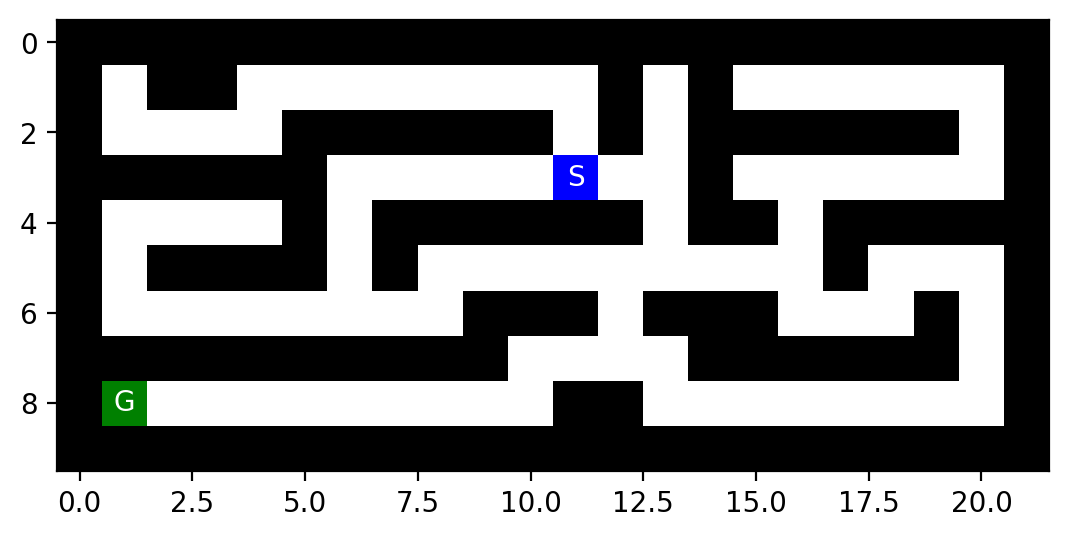

In [3]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
# use higher resolution images in notebooks

mh.show_maze(maze)

Find the `(x,y)` position of the start and the goal using the helper function `find_pos()`

In [4]:
print("Start location:", mh.find_pos(maze, what = "S"))
print("Goal location:", mh.find_pos(maze, what = "G"))

Start location: (3, 11)
Goal location: (8, 1)


Helper function documentation.

In [5]:
help(mh)

Help on module maze_helper:

NAME
    maze_helper

DESCRIPTION
    Code for the Maze Assignment by Michael Hahsler
    Usage: 
        import maze_helper as mh
        mh.show_some_mazes()

FUNCTIONS
    animate_maze(result, repeat=False)
        Build an animation from a list of mazes. Assumes that results has the elements:
        path, reached, actions and maze_anim with a list of maze arrays.
    
    find_pos(maze, what='S')
        Find start/goal in a maze and returns the first one. 
        Caution: there is no error checking!
        
        Parameters:
        maze: a array with characters prodced by parse_maze()
        what: the letter to be found ('S' for start and 'G' for goal)
        
        Returns:
        a tupple (x, y) for the found position.
    
    look(maze, pos)
        Look at the label of a square with the position as an array of the form (x, y).
    
    maze_to_matrix(maze)
        convert a maze a numeric numpy array for visualization via imshow.
    
 

You will need to make a local copy of the module file [maze_helper.py](maze_helper.py) in the same folder where your notebook is.

## Tree structure

Here is an implementation of the basic node structure for the search algorithms (see Fig 3.7 on page 73). I have added a method that extracts the path from the root node to the current node. It can be used to get the path when the search is completed.

In [6]:
class Node:
    def __init__(self, pos, parent, action, cost):
        self.pos = tuple(pos)    # the state; positions are (row,col)
        self.parent = parent     # reference to parent node. None means root node.
        self.action = action     # action used in the transition function (root node has None)
        self.cost = cost         # for uniform cost this is the depth. It is also g(n) for A* search

    def __str__(self):
        return f"Node - pos = {self.pos}; action = {self.action}; cost = {self.cost}"

    def get_path_from_root(self):
        """returns nodes on the path from the root to the current node."""
        node = self
        path = [node]

        while not node.parent is None:
            node = node.parent
            path.append(node)

        path.reverse()

        return(path)

If needed, then you can add more fields to the class like the heuristic value $h(n)$ or $f(n)$.

Examples for how to create and use a tree and information on memory management can be found [here](../HOWTOs/trees.ipynb).

# Tasks

The goal is to:

1. Implement the following search algorithms for solving different mazes:

    - Breadth-first search (BFS)
    - Depth-first search (DFS)
    - Greedy best-first search (GBFS)
    - A* search

2. Run each of the above algorithms on the
    - [small maze](small_maze.txt),
    - [medium maze](medium_maze.txt),
    - [large maze](large_maze.txt),
    - [open maze](open_maze.txt),
    - [wall maze](wall_maze.txt),
    - [loops maze](loops_maze.txt),
    - [empty maze](empty_maze.txt), and
    - [empty 2_maze](empty_2_maze.txt).
    
3. For each problem instance and each search algorithm, report the following in a table:

    - The solution and its path cost
    - Total number of nodes expanded
    - Maximum tree depth
    - Maximum size of the frontier

4. Display each solution by marking every maze square (or state) visited and the squares on the final path.

## General [10 Points]

1. Make sure that you use the latest version of this notebook.
2. Your implementation can use libraries like math, numpy, scipy, but not libraries that implement intelligent agents or complete search algorithms. Try to keep the code simple! In this course, we want to learn about the algorithms and we often do not need to use object-oriented design.
3. You notebook needs to be formatted professionally.
    - Add additional markdown blocks for your description, comments in the code, add tables and use mathplotlib to produce charts where appropriate
    - Do not show debugging output or include an excessive amount of output.
    - Check that your PDF file is readable. For example, long lines are cut off in the PDF file. You don't have control over page breaks, so do not worry about these.
4. Document your code. Add a short discussion of how your implementation works and your design choices.

## Task 1: Defining the search problem and determining the problem size [10 Points]

Define the components of the search problem:

* Initial state
* Actions
* Transition model
* Goal state
* Path cost

Use verbal descriptions, variables and equations as appropriate.

*Note:* You can swich the next block from code to Markdown and use formating.

* **Initial state ($s_0$):** This is the state from which the agent starts its search in this problem it is the starting location of the agent (Location $s$=(3, 11))
* **Actions ($a$):** These are the set of actions available to the agent from a given state $s$ that leads to a new state $s'$. In this problem the actions are 'North','South','West','East'.
* **Transition Model ( $f(s,a)$):** It shows the result of performing action $a$ in state $s$ that leads to a new state $s'$. <br>
  denoted as $f(s$ x $a)$-->$s'$ for example moving right from the location (0,0) leads to new location (0,1) of the agent
* **Goal state ($G$):** it shows the goal or sucessful solution to the problem in this problem the goal state is ($G$)=(8, 1) location
* **path cost ($w$):** cost of all actions starting from the initial state to the last state of that path.  It helps evaluate the efficiency of different paths. For example every actions can cost 1.

Give some estimates for the problem size:

* $n$: state space size
* $d$: depth of the optimal solution
* $m$: maximum depth of tree
* $b$: maximum branching factor

Describe how you would determin these values for a given maze.

* $n$: state space size is the set of all possible states of the environment. In all of the given mazes it can be calculated as (number of rows x number of columns)-(number of walls (marked as 'X')) if the shape is rectangular/square else it is calculated by (number of empty cells + starting point 'S' + goal state 'G'). For example for small_maze it can be calculated as:

In [7]:
import numpy as np
rows, cols = maze.shape
area=rows*cols
No_walls=np.count_nonzero((maze == 'X'))
print('state space size is :', area-No_walls)
print('state space size is :',np.count_nonzero((maze == ' ') | (maze == 'S') | (maze == 'G')))

state space size is : 94
state space size is : 94


* $d$: depth of the optimal solution is the number of actions required to reach the goal from the initial state using the optimal (shortest) path. We need to use search algorithms like BFS to find a short path and then calculate the number of steps it takes to reach the goal from initial state. In small_maze problem the depth of optimal solution is 19.
* $m$: maximum depth of tree is the longest possible path search algorithm reaches during its exploration. It depends on the structure of the
maze and the search strategy used. The maximum depth occurs when the agent explores every possible path, even if it leads to dead ends. maximum depth of tree can be calculated using search algorithms.
* $b$: maximum branching factor is the number of possible directions the agent can move from any state (is the maximum number of child nodes generated by a single node in the search tree). In our problem is equal to 4 which represents 'North','South','West','East'.

## Task 2: Uninformed search: Breadth-first and depth-first [40 Points]

Implement these search strategies. Follow the pseudocode in the textbook/slides. You can use the tree structure shown above to extract the final path from your solution.

Read the following **important notes** carefully:
* You can find maze solving implementations online that use the map to store information. While this is an effective idea for this two-dimensional navigation problem, it typically cannot be used for other search problems. Therefore, follow the textbook and **do not store information in the map.** Only store information in the tree created during search, and use the `reached` and `frontier` data structures where appropriate.
* DSF behavior can be implemented using the BFS tree search algorithm and simply changing the order in which the frontier is expanded (this is equivalent to best-first search with path length as the criterion to expand the next node). However, this would be a big mistake since it combines the bad space complexity of BFS with the bad time complexity of DFS! **To take advantage of the significantly smaller memory footprint of DFS, you need to implement DFS in a different way without a `reached` data structure (often also called `visited` or `explored`) and by releasing the memory for nodes that are not needed anymore.**
* Since the proper implementation of DFS does not use a `reached` data structure, redundant path checking abilities are limited to cycle checking.
You need to implement **cycle checking since DSF is incomplete (produces an infinite loop) if cycles cannot be prevented.** You will see in your experiments that cycle checking in open spaces is challenging.

### Breadth-first-search for Small-maze

In [8]:
from IPython.display import clear_output
import pandas as pd

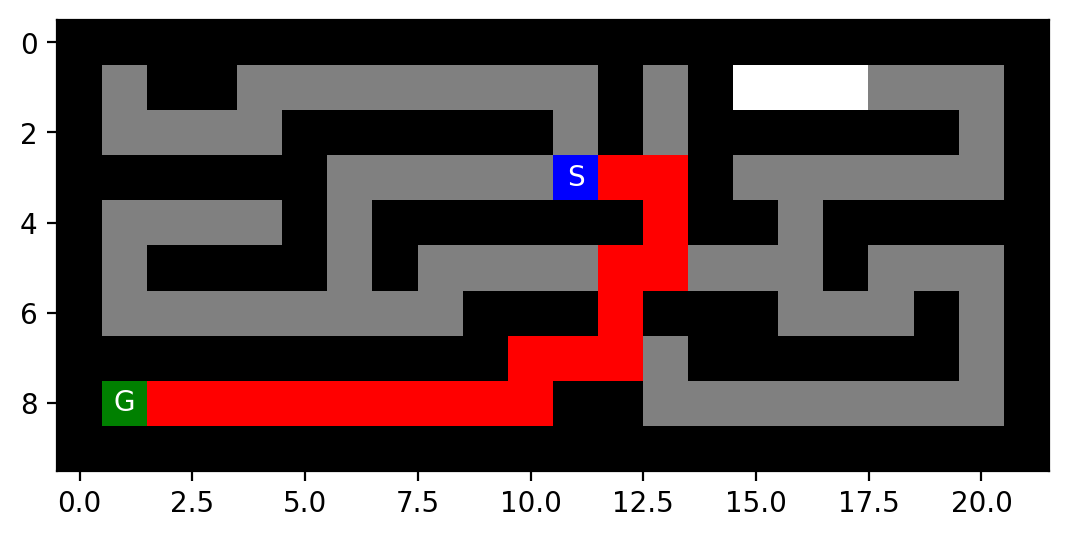

,Algorithm,Path Cost,Nodes Expanded,Max Tree Depth,Max Frontier Size,max memory usage
0,BFS,19,90,19,8,94


In [9]:

class Node:
    def __init__(self, pos, parent=None, action=None, cost=0):
        self.pos = tuple(pos)    # the state; positions are (row,col)
        self.parent = parent     # reference to parent node. None means root node.
        self.action = action     # action used in the transition function (root node has None)
        self.cost = cost         # for uniform cost this is the depth. It is also g(n) for A* search

    def __str__(self):
        return f"Node - pos = {self.pos}; action = {self.action}; cost = {self.cost}"

    def get_path_from_root(self):
        """returns nodes on the path from the root to the current node."""
        node = self
        path = [node]

        while not node.parent is None:
            node = node.parent
            path.append(node)
            

        path.reverse()

        return(path)
ACTIONS = [(-1, 0, 'North'), (1, 0, 'South'), (0, -1, 'West'), (0, 1, 'East')]    
def mark_maze(maze, pos, symbol):
    """Marks the maze at a given position with a symbol."""
    maze[pos[0]][pos[1]] = symbol
    
def BFS(maze, start, goal):
    # Initialize the initial node and check if it's the goal
    initial_node = Node(pos=start)
    if start == goal:  # Check if the initial state is the goal
        return initial_node.get_path_from_root(), 0, 0, 0, 0
    
    # Initialize the frontier (FIFO queue) and reached set
    frontier = [initial_node]  # Frontier initialized with the initial node
    reached = set()  # Reached set to track visited nodes
    reached.add(start)
    
    # Metrics tracking
    nodes_expanded = 0  # Total nodes expanded
    max_tree_depth = 0  # Maximum depth of the tree
    max_frontier_size = 1  # Maximum size of the frontier (starts with 1, the initial node)
    max_memory_usage = 1  # Maximum number of nodes in memory (frontier + reached)
    # Loop until we either find the goal or exhaust the frontier
    while frontier:
        node = frontier.pop(0)  # Expand the node (FIFO behavior)
        nodes_expanded += 1  # Increment the expanded nodes counter

        # Mark the node as visited (for visualization purposes)
        if mh.look(maze, node.pos) != 'S':
            mark_maze(maze, node.pos, '.')
        
        # Loop through possible actions (North, South, West, East)
        for dx, dy, action in ACTIONS:
            next_pos = (node.pos[0] + dx, node.pos[1] + dy)  # Next position 
            
            # Check if next position is valid (not a wall or already reached)
            if mh.look(maze, next_pos) != 'X' and next_pos not in reached:
                reached.add(next_pos)  # Add the next position to the reached set

                # Create child node
                child = Node(next_pos, node, action, node.cost + 1)  # Child node with updated cost (depth)

                # Add child to the frontier
                frontier.append(child)

                # Track maximum tree depth
                max_tree_depth = max(max_tree_depth, child.cost)
                
                # Track maximum frontier size
                max_frontier_size = max(max_frontier_size, len(frontier))
                
                # If the goal is reached, return the solution path and metrics
                if mh.look(maze, next_pos) == 'G':
                    solution_path = child.get_path_from_root()
                    path_cost = len(solution_path) - 1
                    for path_node in solution_path:
                        if mh.look(maze, path_node.pos) != 'G' and mh.look(maze, path_node.pos) != 'S':
                            mark_maze(maze, path_node.pos, 'P')
                            clear_output(wait=True)
                            mh.show_maze(maze)
                    
                    return (solution_path, path_cost, nodes_expanded, max_tree_depth, max_frontier_size,max_memory_usage)

        max_memory_usage = max(max_memory_usage, len(frontier) + len(reached))
        clear_output(wait=True)
        mh.show_maze(maze)
    
    # If no solution is found, return None with 0s for all metrics
    return None, 0, nodes_expanded, max_tree_depth, max_frontier_size

with open("small_maze.txt", "r") as f:
    maze_str = f.read()
maze = mh.parse_maze(maze_str)
start= mh.find_pos(maze, what = "S")
goal= mh.find_pos(maze, what = "G")
print('start point is',start,'goal point is',goal)
[solution_path,BFS_small_path_cost,BFS_small_nodes_expanded,BFS_small_max_tree_depth, BFS_small_max_frontier_size,BFS_small_memory_usage] = BFS(maze, start, goal)
data = {
    'Algorithm': ['BFS'],
    'Path Cost': [BFS_small_path_cost],
    'Nodes Expanded': [BFS_small_nodes_expanded],
    'Max Tree Depth': [BFS_small_max_tree_depth],
    'Max Frontier Size': [BFS_small_max_frontier_size],
    'max memory usage':[BFS_small_memory_usage]
}

# Create a DataFrame
df = pd.DataFrame(data)
df

### Breadth-first-search for Medium-maze

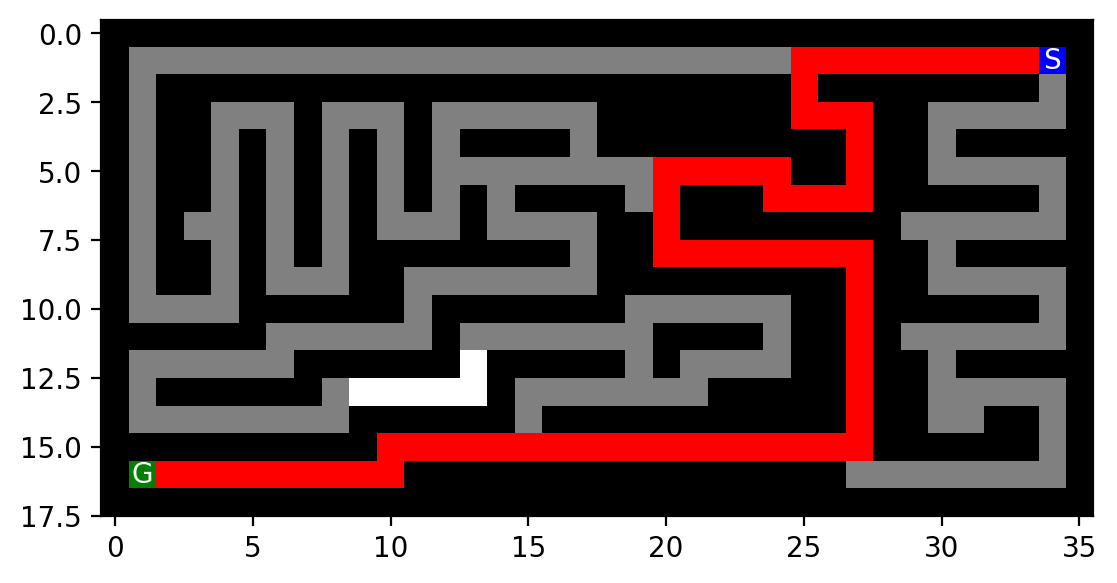

,Algorithm,Path Cost,Nodes Expanded,Max Tree Depth,Max Frontier Size,max memory usage
0,BFS,68,267,68,8,272


In [10]:

class Node:
    def __init__(self, pos, parent=None, action=None, cost=0):
        self.pos = tuple(pos)    # the state; positions are (row,col)
        self.parent = parent     # reference to parent node. None means root node.
        self.action = action     # action used in the transition function (root node has None)
        self.cost = cost         # for uniform cost this is the depth. It is also g(n) for A* search

    def __str__(self):
        return f"Node - pos = {self.pos}; action = {self.action}; cost = {self.cost}"

    def get_path_from_root(self):
        """returns nodes on the path from the root to the current node."""
        node = self
        path = [node]

        while not node.parent is None:
            node = node.parent
            path.append(node)
            

        path.reverse()

        return(path)
ACTIONS = [(-1, 0, 'North'), (1, 0, 'South'), (0, -1, 'West'), (0, 1, 'East')]    
def mark_maze(maze, pos, symbol):
    """Marks the maze at a given position with a symbol."""
    maze[pos[0]][pos[1]] = symbol
    
def BFS(maze, start, goal):
    # Initialize the initial node and check if it's the goal
    initial_node = Node(pos=start)
    if start == goal:  # Check if the initial state is the goal
        return initial_node.get_path_from_root(), 0, 0, 0, 0
    
    # Initialize the frontier (FIFO queue) and reached set
    frontier = [initial_node]  # Frontier initialized with the initial node
    reached = set()  # Reached set to track visited nodes
    reached.add(start)
    
    # Metrics tracking
    nodes_expanded = 0  # Total nodes expanded
    max_tree_depth = 0  # Maximum depth of the tree
    max_frontier_size = 1  # Maximum size of the frontier (starts with 1, the initial node)
    max_memory_usage = 1  # Maximum number of nodes in memory (frontier + reached)
    # Loop until we either find the goal or exhaust the frontier
    while frontier:
        node = frontier.pop(0)  # Expand the node (FIFO behavior)
        nodes_expanded += 1  # Increment the expanded nodes counter

        # Mark the node as visited (for visualization purposes)
        if mh.look(maze, node.pos) != 'S':
            mark_maze(maze, node.pos, '.')
        
        # Loop through possible actions (North, South, West, East)
        for dx, dy, action in ACTIONS:
            next_pos = (node.pos[0] + dx, node.pos[1] + dy)  # Next position 
            
            # Check if next position is valid (not a wall or already reached)
            if mh.look(maze, next_pos) != 'X' and next_pos not in reached:
                reached.add(next_pos)  # Add the next position to the reached set

                # Create child node
                child = Node(next_pos, node, action, node.cost + 1)  # Child node with updated cost (depth)

                # Add child to the frontier
                frontier.append(child)

                # Track maximum tree depth
                max_tree_depth = max(max_tree_depth, child.cost)
                
                # Track maximum frontier size
                max_frontier_size = max(max_frontier_size, len(frontier))
                
                # If the goal is reached, return the solution path and metrics
                if mh.look(maze, next_pos) == 'G':
                    solution_path = child.get_path_from_root()
                    path_cost = len(solution_path) - 1
                    for path_node in solution_path:
                        if mh.look(maze, path_node.pos) != 'G' and mh.look(maze, path_node.pos) != 'S':
                            mark_maze(maze, path_node.pos, 'P')
                            clear_output(wait=True)
                            mh.show_maze(maze)
                    
                    return (solution_path, path_cost, nodes_expanded, max_tree_depth, max_frontier_size,max_memory_usage)

        max_memory_usage = max(max_memory_usage, len(frontier) + len(reached))
        clear_output(wait=True)
        mh.show_maze(maze)
    
    # If no solution is found, return None with 0s for all metrics
    return None, 0, nodes_expanded, max_tree_depth, max_frontier_size

with open("medium_maze.txt", "r") as f:
    maze_str = f.read()
maze = mh.parse_maze(maze_str)
start= mh.find_pos(maze, what = "S")
goal= mh.find_pos(maze, what = "G")
print('start point is',start,'goal point is',goal)
[solution_path,BFS_medium_path_cost,BFS_medium_nodes_expanded,BFS_medium_max_tree_depth, BFS_medium_max_frontier_size,BFS_medium_memory_usage] = BFS(maze, start, goal)
data = {
    'Algorithm': ['BFS'],
    'Path Cost': [BFS_medium_path_cost],
    'Nodes Expanded': [BFS_medium_nodes_expanded],
    'Max Tree Depth': [BFS_medium_max_tree_depth],
    'Max Frontier Size': [BFS_medium_max_frontier_size],
    'max memory usage':[BFS_medium_memory_usage]
}

# Create a DataFrame
df = pd.DataFrame(data)
df

### Breadth-first-search for Large-maze

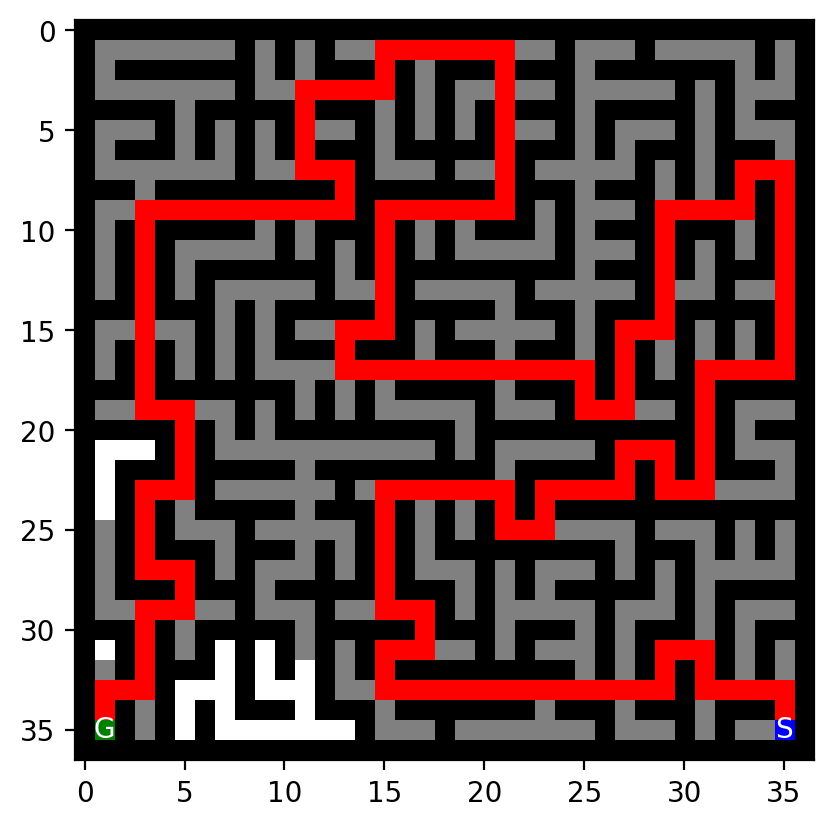

,Algorithm,Path Cost,Nodes Expanded,Max Tree Depth,Max Frontier Size,max memory usage
0,BFS,210,617,210,8,624


In [11]:

class Node:
    def __init__(self, pos, parent=None, action=None, cost=0):
        self.pos = tuple(pos)    # the state; positions are (row,col)
        self.parent = parent     # reference to parent node. None means root node.
        self.action = action     # action used in the transition function (root node has None)
        self.cost = cost         # for uniform cost this is the depth. It is also g(n) for A* search

    def __str__(self):
        return f"Node - pos = {self.pos}; action = {self.action}; cost = {self.cost}"

    def get_path_from_root(self):
        """returns nodes on the path from the root to the current node."""
        node = self
        path = [node]

        while not node.parent is None:
            node = node.parent
            path.append(node)
            

        path.reverse()

        return(path)
ACTIONS = [(-1, 0, 'North'), (1, 0, 'South'), (0, -1, 'West'), (0, 1, 'East')]    
def mark_maze(maze, pos, symbol):
    """Marks the maze at a given position with a symbol."""
    maze[pos[0]][pos[1]] = symbol
    
def BFS(maze, start, goal):
    # Initialize the initial node and check if it's the goal
    initial_node = Node(pos=start)
    if start == goal:  # Check if the initial state is the goal
        return initial_node.get_path_from_root(), 0, 0, 0, 0
    
    # Initialize the frontier (FIFO queue) and reached set
    frontier = [initial_node]  # Frontier initialized with the initial node
    reached = set()  # Reached set to track visited nodes
    reached.add(start)
    
    # Metrics tracking
    nodes_expanded = 0  # Total nodes expanded
    max_tree_depth = 0  # Maximum depth of the tree
    max_frontier_size = 1  # Maximum size of the frontier (starts with 1, the initial node)
    max_memory_usage = 1  # Maximum number of nodes in memory (frontier + reached)
    # Loop until we either find the goal or exhaust the frontier
    while frontier:
        node = frontier.pop(0)  # Expand the node (FIFO behavior)
        nodes_expanded += 1  # Increment the expanded nodes counter

        # Mark the node as visited (for visualization purposes)
        if mh.look(maze, node.pos) != 'S':
            mark_maze(maze, node.pos, '.')
        
        # Loop through possible actions (North, South, West, East)
        for dx, dy, action in ACTIONS:
            next_pos = (node.pos[0] + dx, node.pos[1] + dy)  # Next position 
            
            # Check if next position is valid (not a wall or already reached)
            if mh.look(maze, next_pos) != 'X' and next_pos not in reached:
                reached.add(next_pos)  # Add the next position to the reached set

                # Create child node
                child = Node(next_pos, node, action, node.cost + 1)  # Child node with updated cost (depth)

                # Add child to the frontier
                frontier.append(child)

                # Track maximum tree depth
                max_tree_depth = max(max_tree_depth, child.cost)
                
                # Track maximum frontier size
                max_frontier_size = max(max_frontier_size, len(frontier))
                
                # If the goal is reached, return the solution path and metrics
                if mh.look(maze, next_pos) == 'G':
                    solution_path = child.get_path_from_root()
                    path_cost = len(solution_path) - 1
                    for path_node in solution_path:
                        if mh.look(maze, path_node.pos) != 'G' and mh.look(maze, path_node.pos) != 'S':
                            mark_maze(maze, path_node.pos, 'P')
                            clear_output(wait=True)
                            mh.show_maze(maze)
                    
                    return (solution_path, path_cost, nodes_expanded, max_tree_depth, max_frontier_size,max_memory_usage)

        max_memory_usage = max(max_memory_usage, len(frontier) + len(reached))
        clear_output(wait=True)
        mh.show_maze(maze)
    
    # If no solution is found, return None with 0s for all metrics
    return None, 0, nodes_expanded, max_tree_depth, max_frontier_size

with open("large_maze.txt", "r") as f:
    maze_str = f.read()
maze = mh.parse_maze(maze_str)
start= mh.find_pos(maze, what = "S")
goal= mh.find_pos(maze, what = "G")
print('start point is',start,'goal point is',goal)
[solution_path,BFS_large_path_cost,BFS_large_nodes_expanded,BFS_large_max_tree_depth, BFS_large_max_frontier_size,BFS_large_memory_usage] = BFS(maze, start, goal)
data = {
    'Algorithm': ['BFS'],
    'Path Cost': [BFS_large_path_cost],
    'Nodes Expanded': [BFS_large_nodes_expanded],
    'Max Tree Depth': [BFS_large_max_tree_depth],
    'Max Frontier Size': [BFS_large_max_frontier_size],
    'max memory usage':[BFS_large_memory_usage]
}

# Create a DataFrame
df = pd.DataFrame(data)
df

### Breadth-first-search for Wall-maze

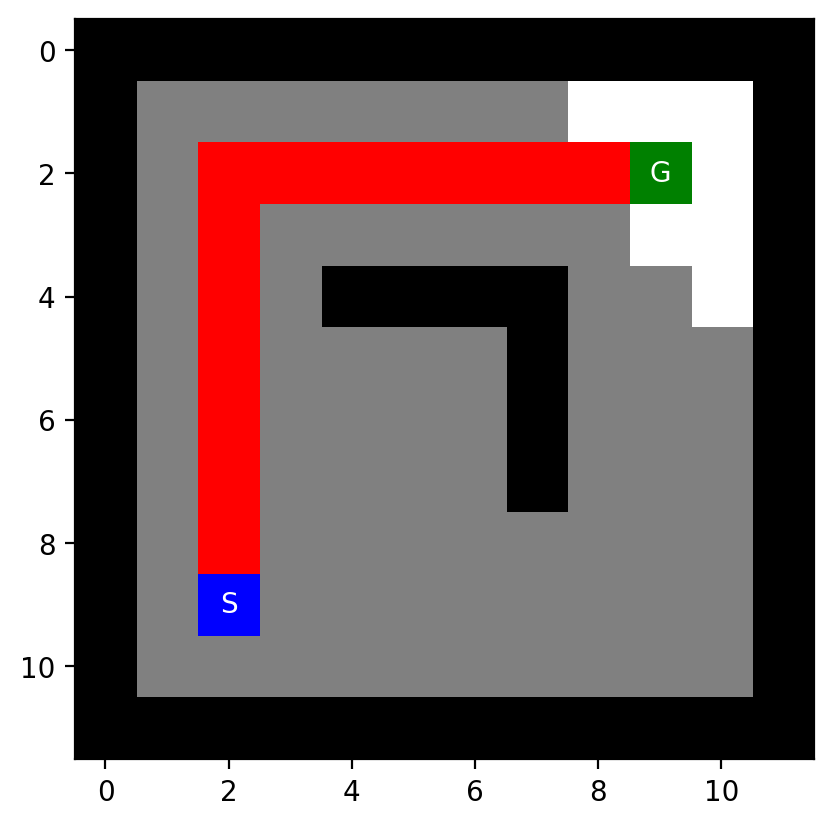

,Algorithm,Path Cost,Nodes Expanded,Max Tree Depth,Max Frontier Size,max memory usage
0,BFS,14,85,14,11,92


In [12]:

class Node:
    def __init__(self, pos, parent=None, action=None, cost=0):
        self.pos = tuple(pos)    # the state; positions are (row,col)
        self.parent = parent     # reference to parent node. None means root node.
        self.action = action     # action used in the transition function (root node has None)
        self.cost = cost         # for uniform cost this is the depth. It is also g(n) for A* search

    def __str__(self):
        return f"Node - pos = {self.pos}; action = {self.action}; cost = {self.cost}"

    def get_path_from_root(self):
        """returns nodes on the path from the root to the current node."""
        node = self
        path = [node]

        while not node.parent is None:
            node = node.parent
            path.append(node)
            

        path.reverse()

        return(path)
ACTIONS = [(-1, 0, 'North'), (1, 0, 'South'), (0, -1, 'West'), (0, 1, 'East')]    
def mark_maze(maze, pos, symbol):
    """Marks the maze at a given position with a symbol."""
    maze[pos[0]][pos[1]] = symbol
    
def BFS(maze, start, goal):
    # Initialize the initial node and check if it's the goal
    initial_node = Node(pos=start)
    if start == goal:  # Check if the initial state is the goal
        return initial_node.get_path_from_root(), 0, 0, 0, 0
    
    # Initialize the frontier (FIFO queue) and reached set
    frontier = [initial_node]  # Frontier initialized with the initial node
    reached = set()  # Reached set to track visited nodes
    reached.add(start)
    
    # Metrics tracking
    nodes_expanded = 0  # Total nodes expanded
    max_tree_depth = 0  # Maximum depth of the tree
    max_frontier_size = 1  # Maximum size of the frontier (starts with 1, the initial node)
    max_memory_usage = 1  # Maximum number of nodes in memory (frontier + reached)
    # Loop until we either find the goal or exhaust the frontier
    while frontier:
        node = frontier.pop(0)  # Expand the node (FIFO behavior)
        nodes_expanded += 1  # Increment the expanded nodes counter

        # Mark the node as visited (for visualization purposes)
        if mh.look(maze, node.pos) != 'S':
            mark_maze(maze, node.pos, '.')
        
        # Loop through possible actions (North, South, West, East)
        for dx, dy, action in ACTIONS:
            next_pos = (node.pos[0] + dx, node.pos[1] + dy)  # Next position 
            
            # Check if next position is valid (not a wall or already reached)
            if mh.look(maze, next_pos) != 'X' and next_pos not in reached:
                reached.add(next_pos)  # Add the next position to the reached set

                # Create child node
                child = Node(next_pos, node, action, node.cost + 1)  # Child node with updated cost (depth)

                # Add child to the frontier
                frontier.append(child)

                # Track maximum tree depth
                max_tree_depth = max(max_tree_depth, child.cost)
                
                # Track maximum frontier size
                max_frontier_size = max(max_frontier_size, len(frontier))
                
                # If the goal is reached, return the solution path and metrics
                if mh.look(maze, next_pos) == 'G':
                    solution_path = child.get_path_from_root()
                    path_cost = len(solution_path) - 1
                    for path_node in solution_path:
                        if mh.look(maze, path_node.pos) != 'G' and mh.look(maze, path_node.pos) != 'S':
                            mark_maze(maze, path_node.pos, 'P')
                            clear_output(wait=True)
                            mh.show_maze(maze)
                    
                    return (solution_path, path_cost, nodes_expanded, max_tree_depth, max_frontier_size,max_memory_usage)
        max_memory_usage = max(max_memory_usage, len(frontier) + len(reached))
        clear_output(wait=True)
        mh.show_maze(maze)
    
    # If no solution is found, return None with 0s for all metrics
    return None, 0, nodes_expanded, max_tree_depth, max_frontier_size

with open("wall_maze.txt", "r") as f:
    maze_str = f.read()
maze = mh.parse_maze(maze_str)
start= mh.find_pos(maze, what = "S")
goal= mh.find_pos(maze, what = "G")
print('start point is',start,'goal point is',goal)
[solution_path,BFS_wall_path_cost,BFS_wall_nodes_expanded,BFS_wall_max_tree_depth, BFS_wall_max_frontier_size,BFS_wall_memory_usage] = BFS(maze, start, goal)
data = {
    'Algorithm': ['BFS'],
    'Path Cost': [BFS_wall_path_cost],
    'Nodes Expanded': [BFS_wall_nodes_expanded],
    'Max Tree Depth': [BFS_wall_max_tree_depth],
    'Max Frontier Size': [BFS_wall_max_frontier_size],
    'max memory usage':[BFS_wall_memory_usage]
}

# Create a DataFrame
df = pd.DataFrame(data)
df

### Breadth-first-search for loops-maze

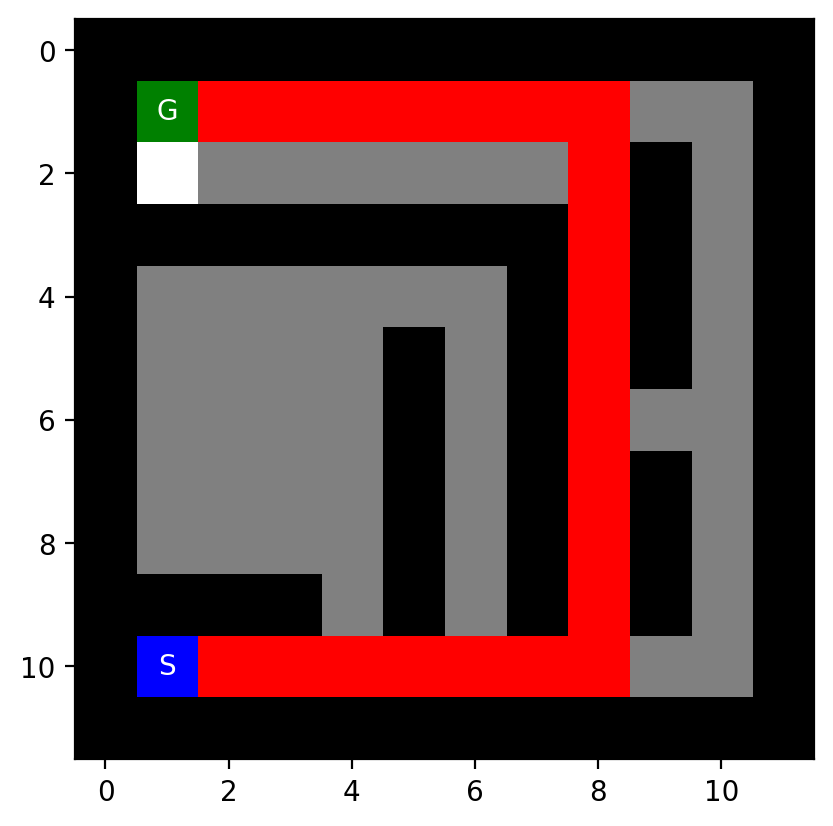

,Algorithm,Path Cost,Nodes Expanded,Max Tree Depth,Max Frontier Size,max memory usage
0,BFS,23,70,23,8,73


In [13]:

class Node:
    def __init__(self, pos, parent=None, action=None, cost=0):
        self.pos = tuple(pos)    # the state; positions are (row,col)
        self.parent = parent     # reference to parent node. None means root node.
        self.action = action     # action used in the transition function (root node has None)
        self.cost = cost         # for uniform cost this is the depth. It is also g(n) for A* search

    def __str__(self):
        return f"Node - pos = {self.pos}; action = {self.action}; cost = {self.cost}"

    def get_path_from_root(self):
        """returns nodes on the path from the root to the current node."""
        node = self
        path = [node]

        while not node.parent is None:
            node = node.parent
            path.append(node)
            

        path.reverse()

        return(path)
ACTIONS = [(-1, 0, 'North'), (1, 0, 'South'), (0, -1, 'West'), (0, 1, 'East')]    
def mark_maze(maze, pos, symbol):
    """Marks the maze at a given position with a symbol."""
    maze[pos[0]][pos[1]] = symbol
    
def BFS(maze, start, goal):
    # Initialize the initial node and check if it's the goal
    initial_node = Node(pos=start)
    if start == goal:  # Check if the initial state is the goal
        return initial_node.get_path_from_root(), 0, 0, 0, 0
    
    # Initialize the frontier (FIFO queue) and reached set
    frontier = [initial_node]  # Frontier initialized with the initial node
    reached = set()  # Reached set to track visited nodes
    reached.add(start)
    
    # Metrics tracking
    nodes_expanded = 0  # Total nodes expanded
    max_tree_depth = 0  # Maximum depth of the tree
    max_frontier_size = 1  # Maximum size of the frontier (starts with 1, the initial node)
    max_memory_usage = 1  # Maximum number of nodes in memory (frontier + reached)
    # Loop until we either find the goal or exhaust the frontier
    while frontier:
        node = frontier.pop(0)  # Expand the node (FIFO behavior)
        nodes_expanded += 1  # Increment the expanded nodes counter

        # Mark the node as visited (for visualization purposes)
        if mh.look(maze, node.pos) != 'S':
            mark_maze(maze, node.pos, '.')
        
        # Loop through possible actions (North, South, West, East)
        for dx, dy, action in ACTIONS:
            next_pos = (node.pos[0] + dx, node.pos[1] + dy)  # Next position 
            
            # Check if next position is valid (not a wall or already reached)
            if mh.look(maze, next_pos) != 'X' and next_pos not in reached:
                reached.add(next_pos)  # Add the next position to the reached set

                # Create child node
                child = Node(next_pos, node, action, node.cost + 1)  # Child node with updated cost (depth)

                # Add child to the frontier
                frontier.append(child)

                # Track maximum tree depth
                max_tree_depth = max(max_tree_depth, child.cost)
                
                # Track maximum frontier size
                max_frontier_size = max(max_frontier_size, len(frontier))
                
                # If the goal is reached, return the solution path and metrics
                if mh.look(maze, next_pos) == 'G':
                    solution_path = child.get_path_from_root()
                    path_cost = len(solution_path) - 1
                    for path_node in solution_path:
                        if mh.look(maze, path_node.pos) != 'G' and mh.look(maze, path_node.pos) != 'S':
                            mark_maze(maze, path_node.pos, 'P')
                            clear_output(wait=True)
                            mh.show_maze(maze)
                    
                    return (solution_path, path_cost, nodes_expanded, max_tree_depth, max_frontier_size,max_memory_usage)

        max_memory_usage = max(max_memory_usage, len(frontier) + len(reached))
        clear_output(wait=True)
        mh.show_maze(maze)
    
    # If no solution is found, return None with 0s for all metrics
    return None, 0, nodes_expanded, max_tree_depth, max_frontier_size

with open("loops_maze.txt", "r") as f:
    maze_str = f.read()
maze = mh.parse_maze(maze_str)
start= mh.find_pos(maze, what = "S")
goal= mh.find_pos(maze, what = "G")
print('start point is',start,'goal point is',goal)
[solution_path,BFS_loops_path_cost,BFS_loops_nodes_expanded,BFS_loops_max_tree_depth, BFS_loops_max_frontier_size,BFS_loops_memory_usage] = BFS(maze, start, goal)
data = {
    'Algorithm': ['BFS'],
    'Path Cost': [BFS_loops_path_cost],
    'Nodes Expanded': [BFS_loops_nodes_expanded],
    'Max Tree Depth': [BFS_loops_max_tree_depth],
    'Max Frontier Size': [BFS_loops_max_frontier_size],
    'max memory usage':[BFS_loops_memory_usage]
}

# Create a DataFrame
df = pd.DataFrame(data)
df

### Breadth-first-search for Empty-maze

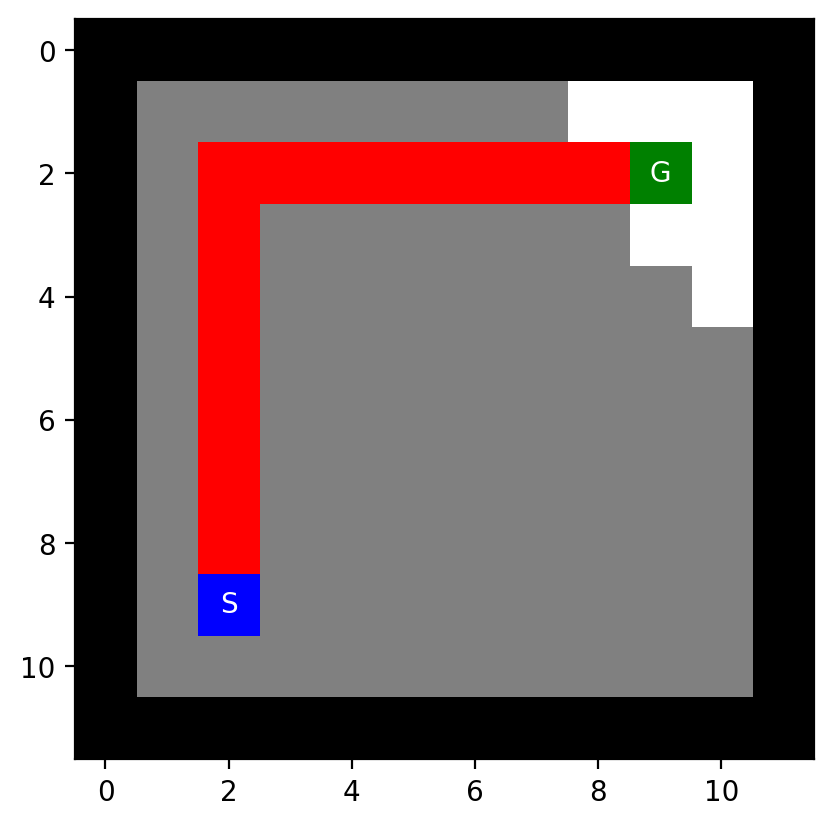

,Algorithm,Path Cost,Nodes Expanded,Max Tree Depth,Max Frontier Size,max memory usage
0,BFS,14,92,14,12,99


In [14]:

class Node:
    def __init__(self, pos, parent=None, action=None, cost=0):
        self.pos = tuple(pos)    # the state; positions are (row,col)
        self.parent = parent     # reference to parent node. None means root node.
        self.action = action     # action used in the transition function (root node has None)
        self.cost = cost         # for uniform cost this is the depth. It is also g(n) for A* search

    def __str__(self):
        return f"Node - pos = {self.pos}; action = {self.action}; cost = {self.cost}"

    def get_path_from_root(self):
        """returns nodes on the path from the root to the current node."""
        node = self
        path = [node]

        while not node.parent is None:
            node = node.parent
            path.append(node)
            

        path.reverse()

        return(path)
ACTIONS = [(-1, 0, 'North'), (1, 0, 'South'), (0, -1, 'West'), (0, 1, 'East')]    
def mark_maze(maze, pos, symbol):
    """Marks the maze at a given position with a symbol."""
    maze[pos[0]][pos[1]] = symbol
    
def BFS(maze, start, goal):
    # Initialize the initial node and check if it's the goal
    initial_node = Node(pos=start)
    if start == goal:  # Check if the initial state is the goal
        return initial_node.get_path_from_root(), 0, 0, 0, 0
    
    # Initialize the frontier (FIFO queue) and reached set
    frontier = [initial_node]  # Frontier initialized with the initial node
    reached = set()  # Reached set to track visited nodes
    reached.add(start)
    
    # Metrics tracking
    nodes_expanded = 0  # Total nodes expanded
    max_tree_depth = 0  # Maximum depth of the tree
    max_frontier_size = 1  # Maximum size of the frontier (starts with 1, the initial node)
    max_memory_usage = 1  # Maximum number of nodes in memory (frontier + reached)
    # Loop until we either find the goal or exhaust the frontier
    while frontier:
        node = frontier.pop(0)  # Expand the node (FIFO behavior)
        nodes_expanded += 1  # Increment the expanded nodes counter

        # Mark the node as visited (for visualization purposes)
        if mh.look(maze, node.pos) != 'S':
            mark_maze(maze, node.pos, '.')
        
        # Loop through possible actions (North, South, West, East)
        for dx, dy, action in ACTIONS:
            next_pos = (node.pos[0] + dx, node.pos[1] + dy)  # Next position 
            
            # Check if next position is valid (not a wall or already reached)
            if mh.look(maze, next_pos) != 'X' and next_pos not in reached:
                reached.add(next_pos)  # Add the next position to the reached set

                # Create child node
                child = Node(next_pos, node, action, node.cost + 1)  # Child node with updated cost (depth)

                # Add child to the frontier
                frontier.append(child)

                # Track maximum tree depth
                max_tree_depth = max(max_tree_depth, child.cost)
                
                # Track maximum frontier size
                max_frontier_size = max(max_frontier_size, len(frontier))
                
                # If the goal is reached, return the solution path and metrics
                if mh.look(maze, next_pos) == 'G':
                    solution_path = child.get_path_from_root()
                    path_cost = len(solution_path) - 1
                    for path_node in solution_path:
                        if mh.look(maze, path_node.pos) != 'G' and mh.look(maze, path_node.pos) != 'S':
                            mark_maze(maze, path_node.pos, 'P')
                            clear_output(wait=True)
                            mh.show_maze(maze)
                    
                    return (solution_path, path_cost, nodes_expanded, max_tree_depth, max_frontier_size,max_memory_usage)

        max_memory_usage = max(max_memory_usage, len(frontier) + len(reached))
        clear_output(wait=True)
        mh.show_maze(maze)
    
    # If no solution is found, return None with 0s for all metrics
    return None, 0, nodes_expanded, max_tree_depth, max_frontier_size

with open("empty_maze.txt", "r") as f:
    maze_str = f.read()
maze = mh.parse_maze(maze_str)
start= mh.find_pos(maze, what = "S")
goal= mh.find_pos(maze, what = "G")
print('start point is',start,'goal point is',goal)
[solution_path,BFS_empty_path_cost,BFS_empty_nodes_expanded,BFS_empty_max_tree_depth, BFS_empty_max_frontier_size,BFS_empty_memory_usage] = BFS(maze, start, goal)
data = {
    'Algorithm': ['BFS'],
    'Path Cost': [BFS_empty_path_cost],
    'Nodes Expanded': [BFS_empty_nodes_expanded],
    'Max Tree Depth': [BFS_empty_max_tree_depth],
    'Max Frontier Size': [BFS_empty_max_frontier_size],
    'max memory usage':[BFS_empty_memory_usage]
}

# Create a DataFrame
df = pd.DataFrame(data)
df

### Breadth-first-search for empty-2-maze

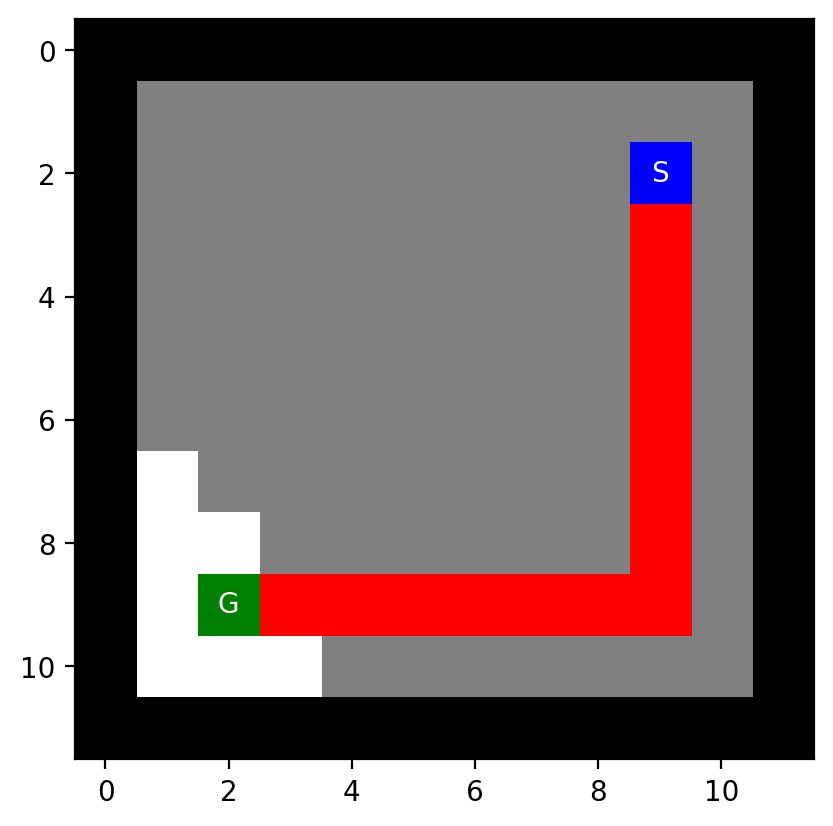

,Algorithm,Path Cost,Nodes Expanded,Max Tree Depth,Max Frontier Size,max memory usage
0,BFS,14,92,14,12,99


In [15]:

class Node:
    def __init__(self, pos, parent=None, action=None, cost=0):
        self.pos = tuple(pos)    # the state; positions are (row,col)
        self.parent = parent     # reference to parent node. None means root node.
        self.action = action     # action used in the transition function (root node has None)
        self.cost = cost         # for uniform cost this is the depth. It is also g(n) for A* search

    def __str__(self):
        return f"Node - pos = {self.pos}; action = {self.action}; cost = {self.cost}"

    def get_path_from_root(self):
        """returns nodes on the path from the root to the current node."""
        node = self
        path = [node]

        while not node.parent is None:
            node = node.parent
            path.append(node)
            

        path.reverse()

        return(path)
ACTIONS = [(-1, 0, 'North'), (1, 0, 'South'), (0, -1, 'West'), (0, 1, 'East')]    
def mark_maze(maze, pos, symbol):
    """Marks the maze at a given position with a symbol."""
    maze[pos[0]][pos[1]] = symbol
    
def BFS(maze, start, goal):
    # Initialize the initial node and check if it's the goal
    initial_node = Node(pos=start)
    if start == goal:  # Check if the initial state is the goal
        return initial_node.get_path_from_root(), 0, 0, 0, 0
    
    # Initialize the frontier (FIFO queue) and reached set
    frontier = [initial_node]  # Frontier initialized with the initial node
    reached = set()  # Reached set to track visited nodes
    reached.add(start)
    
    # Metrics tracking
    nodes_expanded = 0  # Total nodes expanded
    max_tree_depth = 0  # Maximum depth of the tree
    max_frontier_size = 1  # Maximum size of the frontier (starts with 1, the initial node)
    max_memory_usage = 1  # Maximum number of nodes in memory (frontier + reached)
    # Loop until we either find the goal or exhaust the frontier
    while frontier:
        node = frontier.pop(0)  # Expand the node (FIFO behavior)
        nodes_expanded += 1  # Increment the expanded nodes counter

        # Mark the node as visited (for visualization purposes)
        if mh.look(maze, node.pos) != 'S':
            mark_maze(maze, node.pos, '.')
        
        # Loop through possible actions (North, South, West, East)
        for dx, dy, action in ACTIONS:
            next_pos = (node.pos[0] + dx, node.pos[1] + dy)  # Next position 
            
            # Check if next position is valid (not a wall or already reached)
            if mh.look(maze, next_pos) != 'X' and next_pos not in reached:
                reached.add(next_pos)  # Add the next position to the reached set

                # Create child node
                child = Node(next_pos, node, action, node.cost + 1)  # Child node with updated cost (depth)

                # Add child to the frontier
                frontier.append(child)

                # Track maximum tree depth
                max_tree_depth = max(max_tree_depth, child.cost)
                
                # Track maximum frontier size
                max_frontier_size = max(max_frontier_size, len(frontier))
                
                # If the goal is reached, return the solution path and metrics
                if mh.look(maze, next_pos) == 'G':
                    solution_path = child.get_path_from_root()
                    path_cost = len(solution_path) - 1
                    for path_node in solution_path:
                        if mh.look(maze, path_node.pos) != 'G' and mh.look(maze, path_node.pos) != 'S':
                            mark_maze(maze, path_node.pos, 'P')
                            clear_output(wait=True)
                            mh.show_maze(maze)
                    
                    return (solution_path, path_cost, nodes_expanded, max_tree_depth, max_frontier_size,max_memory_usage)

        max_memory_usage = max(max_memory_usage, len(frontier) + len(reached))
        clear_output(wait=True)
        mh.show_maze(maze)
    
    # If no solution is found, return None with 0s for all metrics
    return None, 0, nodes_expanded, max_tree_depth, max_frontier_size

with open("empty_2_maze.txt", "r") as f:
    maze_str = f.read()
maze = mh.parse_maze(maze_str)
start= mh.find_pos(maze, what = "S")
goal= mh.find_pos(maze, what = "G")
print('start point is',start,'goal point is',goal)
[solution_path,BFS_empty_2_path_cost,BFS_empty_2_nodes_expanded,BFS_empty_2_max_tree_depth, BFS_empty_2_max_frontier_size,BFS_empty_2_memory_usage] = BFS(maze, start, goal)
data = {
    'Algorithm': ['BFS'],
    'Path Cost': [BFS_empty_2_path_cost],
    'Nodes Expanded': [BFS_empty_2_nodes_expanded],
    'Max Tree Depth': [BFS_empty_2_max_tree_depth],
    'Max Frontier Size': [BFS_empty_2_max_frontier_size],
    'max memory usage':[BFS_empty_2_memory_usage]
}

# Create a DataFrame
df = pd.DataFrame(data)
df

### Breadth-first-search for Open-maze

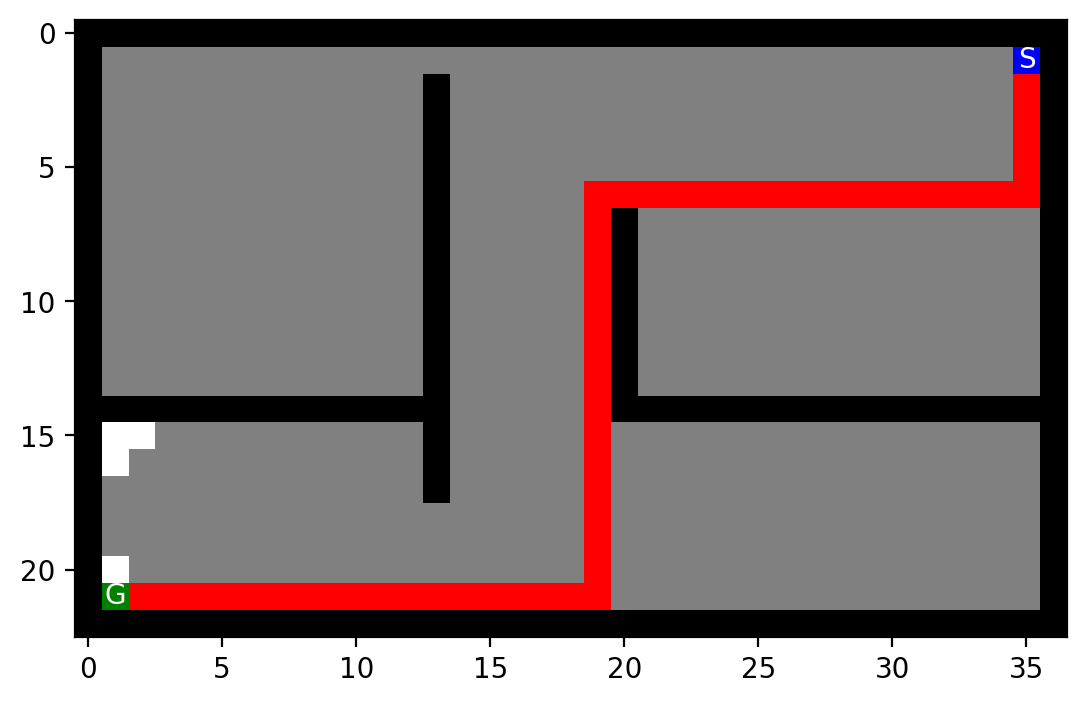

,Algorithm,Path Cost,Nodes Expanded,Max Tree Depth,Max Frontier Size,max memory usage
0,BFS,54,679,54,25,687


In [16]:

class Node:
    def __init__(self, pos, parent=None, action=None, cost=0):
        self.pos = tuple(pos)    # the state; positions are (row,col)
        self.parent = parent     # reference to parent node. None means root node.
        self.action = action     # action used in the transition function (root node has None)
        self.cost = cost         # for uniform cost this is the depth. It is also g(n) for A* search

    def __str__(self):
        return f"Node - pos = {self.pos}; action = {self.action}; cost = {self.cost}"

    def get_path_from_root(self):
        """returns nodes on the path from the root to the current node."""
        node = self
        path = [node]

        while not node.parent is None:
            node = node.parent
            path.append(node)
            

        path.reverse()

        return(path)
ACTIONS = [(-1, 0, 'North'), (1, 0, 'South'), (0, -1, 'West'), (0, 1, 'East')]    
def mark_maze(maze, pos, symbol):
    """Marks the maze at a given position with a symbol."""
    maze[pos[0]][pos[1]] = symbol
    
def BFS(maze, start, goal):
    # Initialize the initial node and check if it's the goal
    initial_node = Node(pos=start)
    if start == goal:  # Check if the initial state is the goal
        return initial_node.get_path_from_root(), 0, 0, 0, 0
    
    # Initialize the frontier (FIFO queue) and reached set
    frontier = [initial_node]  # Frontier initialized with the initial node
    reached = set()  # Reached set to track visited nodes
    reached.add(start)
    
    # Metrics tracking
    nodes_expanded = 0  # Total nodes expanded
    max_tree_depth = 0  # Maximum depth of the tree
    max_frontier_size = 1  # Maximum size of the frontier (starts with 1, the initial node)
    max_memory_usage = 1  # Maximum number of nodes in memory (frontier + reached)
    # Loop until we either find the goal or exhaust the frontier
    while frontier:
        node = frontier.pop(0)  # Expand the node (FIFO behavior)
        nodes_expanded += 1  # Increment the expanded nodes counter

        # Mark the node as visited (for visualization purposes)
        if mh.look(maze, node.pos) != 'S':
            mark_maze(maze, node.pos, '.')
        
        # Loop through possible actions (North, South, West, East)
        for dx, dy, action in ACTIONS:
            next_pos = (node.pos[0] + dx, node.pos[1] + dy)  # Next position 
            
            # Check if next position is valid (not a wall or already reached)
            if mh.look(maze, next_pos) != 'X' and next_pos not in reached:
                reached.add(next_pos)  # Add the next position to the reached set

                # Create child node
                child = Node(next_pos, node, action, node.cost + 1)  # Child node with updated cost (depth)

                # Add child to the frontier
                frontier.append(child)

                # Track maximum tree depth
                max_tree_depth = max(max_tree_depth, child.cost)
                
                # Track maximum frontier size
                max_frontier_size = max(max_frontier_size, len(frontier))
                
                # If the goal is reached, return the solution path and metrics
                if mh.look(maze, next_pos) == 'G':
                    solution_path = child.get_path_from_root()
                    path_cost = len(solution_path) - 1
                    for path_node in solution_path:
                        if mh.look(maze, path_node.pos) != 'G' and mh.look(maze, path_node.pos) != 'S':
                            mark_maze(maze, path_node.pos, 'P')
                            clear_output(wait=True)
                            mh.show_maze(maze)
                    
                    return (solution_path, path_cost, nodes_expanded, max_tree_depth, max_frontier_size,max_memory_usage)

        max_memory_usage = max(max_memory_usage, len(frontier) + len(reached))
        clear_output(wait=True)
        mh.show_maze(maze)
    
    # If no solution is found, return None with 0s for all metrics
    return None, 0, nodes_expanded, max_tree_depth, max_frontier_size

with open("open_maze.txt", "r") as f:
    maze_str = f.read()
maze = mh.parse_maze(maze_str)
start= mh.find_pos(maze, what = "S")
goal= mh.find_pos(maze, what = "G")
print('start point is',start,'goal point is',goal)
[solution_path,BFS_open_path_cost,BFS_open_nodes_expanded,BFS_open_max_tree_depth, BFS_open_max_frontier_size,BFS_open_memory_usage] = BFS(maze, start, goal)
data = {
    'Algorithm': ['BFS'],
    'Path Cost': [BFS_open_path_cost],
    'Nodes Expanded': [BFS_open_nodes_expanded],
    'Max Tree Depth': [BFS_open_max_tree_depth],
    'Max Frontier Size': [BFS_open_max_frontier_size],
    'max memory usage':[BFS_open_memory_usage]
}

# Create a DataFrame
df = pd.DataFrame(data)
df

### Depth-First-search for Small-maze

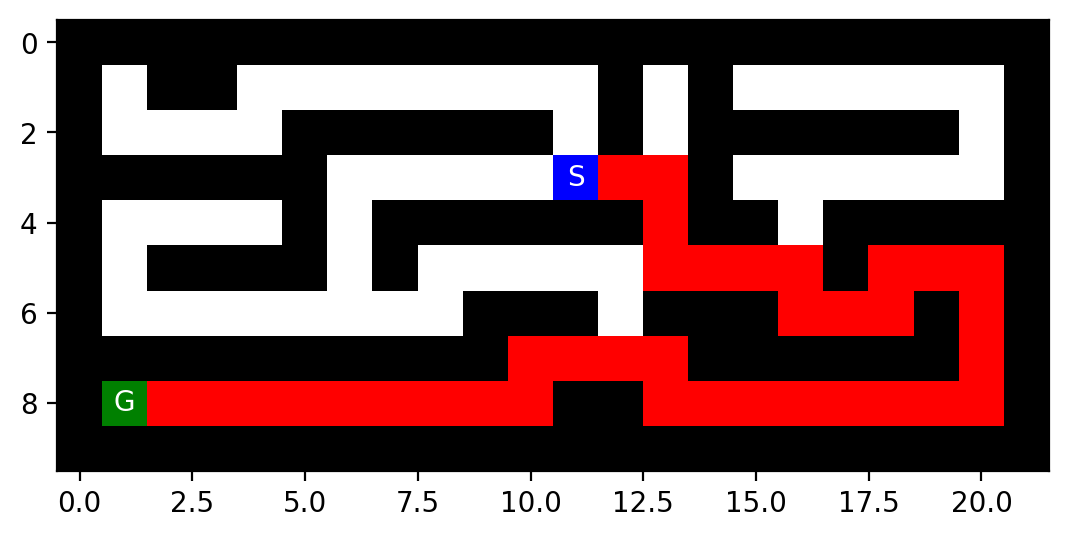

,Algorithm,Path Cost,Nodes Expanded,Max Tree Depth,Max Frontier Size,max memory usage
0,DFS,37,37,36,7,43


In [17]:
def DFS(maze, start, goal):
    #  Initialize the initial node and check if it's the goal
    initial_node = Node(pos=start)
    if start == goal:  # Check if the initial state is the goal
        return initial_node.get_path_from_root()

    #  Initialize the frontier (FIFO queue) and reached set
    frontier = [initial_node]  # Frontier initialized with the initial node
    reached = set()  # Reached set to track visited nodes
    visited = []  # List to track visited nodes in order
    branch = []   # List to track branching points
    nodes_expanded = 0
    max_tree_depth = 0
    max_frontier_size = 1  # Maximum size of the frontier (starts with 1, the initial node)
    max_memory_usage = 1  # Maximum number of nodes in memory (frontier + reached)
    while frontier:
        node = frontier.pop(-1)  # DFS uses LIFO, so we pop from the end (stack behavior)
        nodes_expanded += 1
        node1 = [(node.pos[0] - 1, node.pos[1]), (node.pos[0] + 1, node.pos[1]), 
                 (node.pos[0], node.pos[1] - 1), (node.pos[0], node.pos[1] + 1)]

        # Remove start and goal positions from neighbor list if present
        if mh.find_pos(maze, what="S") in node1:
            node1.pop(node1.index(mh.find_pos(maze, what="S")))
        if mh.find_pos(maze, what="G") in node1:
            node1.pop(node1.index(mh.find_pos(maze, what="G")))

        # Pruning branches if necessary
        while len(visited) > 2 and (visited[-1] not in node1):
            branch.pop(-1)
            last_branch_item = branch[-1]
            if last_branch_item in visited:
                index = visited.index(last_branch_item)
                visited1 = visited[:index + 1]
            for v in visited:
                if v not in visited1 and mh.look(maze, v) != 'G' and mh.look(maze, v) != 'S':
                    mark_maze(maze, v, ' ')
            visited = visited1

        visited.append(node.pos)

        # Mark the current position in the maze if it's not the start or goal
        if mh.look(maze, node.pos) != 'G' and mh.look(maze, node.pos) != 'S':
            mark_maze(maze, node.pos, '.')

        reached.add(node.pos)
        br = 0

        # **Addition**: Check if any neighbor of the current node is the goal
        for dx, dy, action in ACTIONS:
            next_pos = (node.pos[0] + dx, node.pos[1] + dy)  # Calculate next position
            if next_pos == goal:  # Early exit if the next position is the goal
                child = Node(next_pos, node, action, node.cost + 1)
                solution_path = child.get_path_from_root()
                path_cost = len(solution_path) - 1
                # Mark the solution path in the maze
                for path_node in solution_path:
                    if mh.look(maze, path_node.pos) != 'G' and mh.look(maze, path_node.pos) != 'S':
                        mark_maze(maze, path_node.pos, 'P')
                    clear_output(wait=True)
                    mh.show_maze(maze)
                return solution_path, path_cost, nodes_expanded, max_tree_depth, max_frontier_size,max_memory_usage

        # **Continuation of your code**: Expand the search by adding child nodes
        for dx, dy, action in ACTIONS:
            next_pos = (node.pos[0] + dx, node.pos[1] + dy)  # Next position

            if mh.look(maze, next_pos) != 'X' and next_pos not in visited:  # Valid position
                br += 1
                child = Node(next_pos, node, action, node.cost + 1)
                frontier.append(child)  # Add child to frontier
                max_tree_depth = max(max_tree_depth, child.cost)
                max_frontier_size = max(max_frontier_size, len(frontier))
                if br >= 2:
                    branch.append(node.pos)

                if mh.look(maze, node.pos) == 'G' and len(reached) >= 15:
                    last_branch_item = branch[-1]
                    if last_branch_item in visited:
                        index = visited.index(last_branch_item)
                        visited1 = visited[:index + 1]
                    for v in visited:
                        if v not in visited1 and mh.look(maze, v) != 'G' and mh.look(maze, v) != 'S':
                            mark_maze(maze, v, ' ')
                    visited = visited1
                    continue            

        if br == 0 and node.pos in visited:
            last_branch_item = branch[-1]
            if last_branch_item in visited:
                index = visited.index(last_branch_item)
                visited1 = visited[:index + 1]
            for v in visited:
                if v not in visited1 and mh.look(maze, v) != 'G' and mh.look(maze, v) != 'S':
                    mark_maze(maze, v, ' ')
            visited = visited1
            continue

        max_memory_usage = max(max_memory_usage, len(frontier) + len(reached))
        clear_output(wait=True)
        mh.show_maze(maze)
with open("small_maze.txt", "r") as f:
    maze_str = f.read()
maze = mh.parse_maze(maze_str)
start= mh.find_pos(maze, what = "S")
goal= mh.find_pos(maze, what = "G")
print('start point is',start,'goal point is',goal)
[solution_path,DFS_small_path_cost,DFS_small_nodes_expanded,DFS_small_max_tree_depth, DFS_small_max_frontier_size,DFS_small_memory_usage] = DFS(maze, start, goal)
data = {
    'Algorithm': ['DFS'],
    'Path Cost': [DFS_small_path_cost],
    'Nodes Expanded': [DFS_small_nodes_expanded],
    'Max Tree Depth': [DFS_small_max_tree_depth],
    'Max Frontier Size': [DFS_small_max_frontier_size],
    'max memory usage':[DFS_small_memory_usage]
}

# Create a DataFrame
df = pd.DataFrame(data)
df

### Depth-First-search for medium-maze

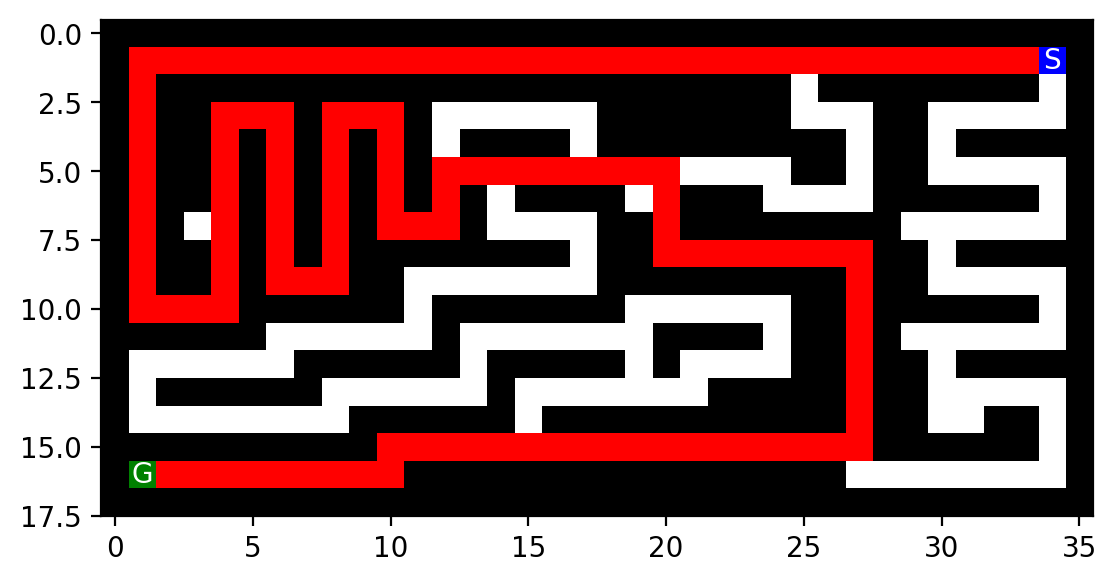

,Algorithm,Path Cost,Nodes Expanded,Max Tree Depth,Max Frontier Size,max memory usage
0,DFS,130,146,129,9,154


In [18]:
def DFS(maze, start, goal):
    #  Initialize the initial node and check if it's the goal
    initial_node = Node(pos=start)
    if start == goal:  # Check if the initial state is the goal
        return initial_node.get_path_from_root()

    #  Initialize the frontier (FIFO queue) and reached set
    frontier = [initial_node]  # Frontier initialized with the initial node
    reached = set()  # Reached set to track visited nodes
    visited = []  # List to track visited nodes in order
    branch = []   # List to track branching points
    nodes_expanded = 0
    max_tree_depth = 0
    max_frontier_size = 1  # Maximum size of the frontier (starts with 1, the initial node)
    max_memory_usage = 1  # Maximum number of nodes in memory (frontier + reached)
    while frontier:
        node = frontier.pop(-1)  # DFS uses LIFO, so we pop from the end (stack behavior)
        nodes_expanded += 1
        node1 = [(node.pos[0] - 1, node.pos[1]), (node.pos[0] + 1, node.pos[1]), 
                 (node.pos[0], node.pos[1] - 1), (node.pos[0], node.pos[1] + 1)]

        # Remove start and goal positions from neighbor list if present
        if mh.find_pos(maze, what="S") in node1:
            node1.pop(node1.index(mh.find_pos(maze, what="S")))
        if mh.find_pos(maze, what="G") in node1:
            node1.pop(node1.index(mh.find_pos(maze, what="G")))

        # Pruning branches if necessary
        while len(visited) > 2 and (visited[-1] not in node1):
            branch.pop(-1)
            last_branch_item = branch[-1]
            if last_branch_item in visited:
                index = visited.index(last_branch_item)
                visited1 = visited[:index + 1]
            for v in visited:
                if v not in visited1 and mh.look(maze, v) != 'G' and mh.look(maze, v) != 'S':
                    mark_maze(maze, v, ' ')
            visited = visited1

        visited.append(node.pos)

        # Mark the current position in the maze if it's not the start or goal
        if mh.look(maze, node.pos) != 'G' and mh.look(maze, node.pos) != 'S':
            mark_maze(maze, node.pos, '.')

        reached.add(node.pos)
        br = 0

        # **Addition**: Check if any neighbor of the current node is the goal
        for dx, dy, action in ACTIONS:
            next_pos = (node.pos[0] + dx, node.pos[1] + dy)  # Calculate next position
            if next_pos == goal:  # Early exit if the next position is the goal
                child = Node(next_pos, node, action, node.cost + 1)
                solution_path = child.get_path_from_root()
                path_cost = len(solution_path) - 1
                # Mark the solution path in the maze
                for path_node in solution_path:
                    if mh.look(maze, path_node.pos) != 'G' and mh.look(maze, path_node.pos) != 'S':
                        mark_maze(maze, path_node.pos, 'P')
                    clear_output(wait=True)
                    mh.show_maze(maze)
                return solution_path, path_cost, nodes_expanded, max_tree_depth, max_frontier_size,max_memory_usage

        # **Continuation of your code**: Expand the search by adding child nodes
        for dx, dy, action in ACTIONS:
            next_pos = (node.pos[0] + dx, node.pos[1] + dy)  # Next position

            if mh.look(maze, next_pos) != 'X' and next_pos not in visited:  # Valid position
                br += 1
                child = Node(next_pos, node, action, node.cost + 1)
                frontier.append(child)  # Add child to frontier
                max_tree_depth = max(max_tree_depth, child.cost)
                max_frontier_size = max(max_frontier_size, len(frontier))
                if br >= 2:
                    branch.append(node.pos)

                if mh.look(maze, node.pos) == 'G' and len(reached) >= 15:
                    last_branch_item = branch[-1]
                    if last_branch_item in visited:
                        index = visited.index(last_branch_item)
                        visited1 = visited[:index + 1]
                    for v in visited:
                        if v not in visited1 and mh.look(maze, v) != 'G' and mh.look(maze, v) != 'S':
                            mark_maze(maze, v, ' ')
                    visited = visited1
                    continue            

        if br == 0 and node.pos in visited:
            last_branch_item = branch[-1]
            if last_branch_item in visited:
                index = visited.index(last_branch_item)
                visited1 = visited[:index + 1]
            for v in visited:
                if v not in visited1 and mh.look(maze, v) != 'G' and mh.look(maze, v) != 'S':
                    mark_maze(maze, v, ' ')
            visited = visited1
            continue

        max_memory_usage = max(max_memory_usage, len(frontier) + len(reached))
        clear_output(wait=True)
        mh.show_maze(maze)
with open("medium_maze.txt", "r") as f:
    maze_str = f.read()
maze = mh.parse_maze(maze_str)
start= mh.find_pos(maze, what = "S")
goal= mh.find_pos(maze, what = "G")
print('start point is',start,'goal point is',goal)
[solution_path,DFS_medium_path_cost,DFS_medium_nodes_expanded,DFS_medium_max_tree_depth, DFS_medium_max_frontier_size,DFS_medium_memory_usage] = DFS(maze, start, goal)
data = {
    'Algorithm': ['DFS'],
    'Path Cost': [DFS_medium_path_cost],
    'Nodes Expanded': [DFS_medium_nodes_expanded],
    'Max Tree Depth': [DFS_medium_max_tree_depth],
    'Max Frontier Size': [DFS_medium_max_frontier_size],
    'max memory usage':[DFS_medium_memory_usage]
}

# Create a DataFrame
df = pd.DataFrame(data)
df

### Depth-First-search for large-maze

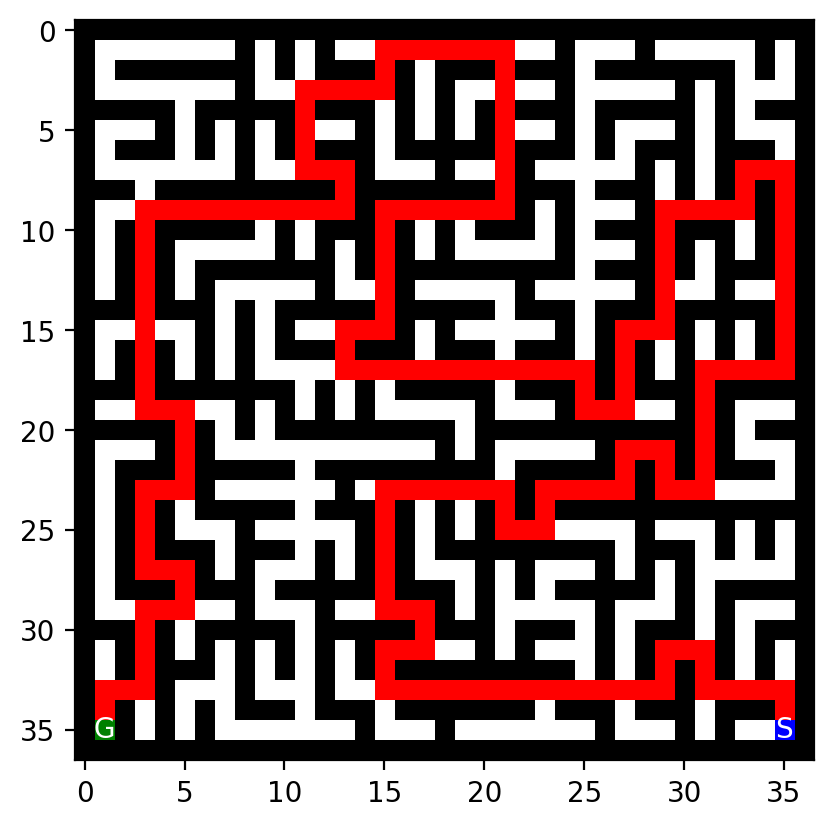

,Algorithm,Path Cost,Nodes Expanded,Max Tree Depth,Max Frontier Size,max memory usage
0,DFS,210,387,222,39,425


In [19]:
def DFS(maze, start, goal):
    #  Initialize the initial node and check if it's the goal
    initial_node = Node(pos=start)
    if start == goal:  # Check if the initial state is the goal
        return initial_node.get_path_from_root()

    #  Initialize the frontier (FIFO queue) and reached set
    frontier = [initial_node]  # Frontier initialized with the initial node
    reached = set()  # Reached set to track visited nodes
    visited = []  # List to track visited nodes in order
    branch = []   # List to track branching points
    nodes_expanded = 0
    max_tree_depth = 0
    max_frontier_size = 1  # Maximum size of the frontier (starts with 1, the initial node)
    max_memory_usage = 1  # Maximum number of nodes in memory (frontier + reached)
    while frontier:
        node = frontier.pop(-1)  # DFS uses LIFO, so we pop from the end (stack behavior)
        nodes_expanded += 1
        node1 = [(node.pos[0] - 1, node.pos[1]), (node.pos[0] + 1, node.pos[1]), 
                 (node.pos[0], node.pos[1] - 1), (node.pos[0], node.pos[1] + 1)]

        # Remove start and goal positions from neighbor list if present
        if mh.find_pos(maze, what="S") in node1:
            node1.pop(node1.index(mh.find_pos(maze, what="S")))
        if mh.find_pos(maze, what="G") in node1:
            node1.pop(node1.index(mh.find_pos(maze, what="G")))

        # Pruning branches if necessary
        while len(visited) > 2 and (visited[-1] not in node1):
            branch.pop(-1)
            last_branch_item = branch[-1]
            if last_branch_item in visited:
                index = visited.index(last_branch_item)
                visited1 = visited[:index + 1]
            for v in visited:
                if v not in visited1 and mh.look(maze, v) != 'G' and mh.look(maze, v) != 'S':
                    mark_maze(maze, v, ' ')
            visited = visited1

        visited.append(node.pos)

        # Mark the current position in the maze if it's not the start or goal
        if mh.look(maze, node.pos) != 'G' and mh.look(maze, node.pos) != 'S':
            mark_maze(maze, node.pos, '.')

        reached.add(node.pos)
        br = 0

        # **Addition**: Check if any neighbor of the current node is the goal
        for dx, dy, action in ACTIONS:
            next_pos = (node.pos[0] + dx, node.pos[1] + dy)  # Calculate next position
            if next_pos == goal:  # Early exit if the next position is the goal
                child = Node(next_pos, node, action, node.cost + 1)
                solution_path = child.get_path_from_root()
                path_cost = len(solution_path) - 1
                # Mark the solution path in the maze
                for path_node in solution_path:
                    if mh.look(maze, path_node.pos) != 'G' and mh.look(maze, path_node.pos) != 'S':
                        mark_maze(maze, path_node.pos, 'P')
                    clear_output(wait=True)
                    mh.show_maze(maze)
                return solution_path, path_cost, nodes_expanded, max_tree_depth, max_frontier_size,max_memory_usage

        # **Continuation of your code**: Expand the search by adding child nodes
        for dx, dy, action in ACTIONS:
            next_pos = (node.pos[0] + dx, node.pos[1] + dy)  # Next position

            if mh.look(maze, next_pos) != 'X' and next_pos not in visited:  # Valid position
                br += 1
                child = Node(next_pos, node, action, node.cost + 1)
                frontier.append(child)  # Add child to frontier
                max_tree_depth = max(max_tree_depth, child.cost)
                max_frontier_size = max(max_frontier_size, len(frontier))
                if br >= 2:
                    branch.append(node.pos)

                if mh.look(maze, node.pos) == 'G' and len(reached) >= 15:
                    last_branch_item = branch[-1]
                    if last_branch_item in visited:
                        index = visited.index(last_branch_item)
                        visited1 = visited[:index + 1]
                    for v in visited:
                        if v not in visited1 and mh.look(maze, v) != 'G' and mh.look(maze, v) != 'S':
                            mark_maze(maze, v, ' ')
                    visited = visited1
                    continue            

        if br == 0 and node.pos in visited:
            last_branch_item = branch[-1]
            if last_branch_item in visited:
                index = visited.index(last_branch_item)
                visited1 = visited[:index + 1]
            for v in visited:
                if v not in visited1 and mh.look(maze, v) != 'G' and mh.look(maze, v) != 'S':
                    mark_maze(maze, v, ' ')
            visited = visited1
            continue

        max_memory_usage = max(max_memory_usage, len(frontier) + len(reached))
        clear_output(wait=True)
        mh.show_maze(maze)
with open("large_maze.txt", "r") as f:
    maze_str = f.read()
maze = mh.parse_maze(maze_str)
start= mh.find_pos(maze, what = "S")
goal= mh.find_pos(maze, what = "G")
print('start point is',start,'goal point is',goal)
[solution_path,DFS_large_path_cost,DFS_large_nodes_expanded,DFS_large_max_tree_depth, DFS_large_max_frontier_size,DFS_large_memory_usage] = DFS(maze, start, goal)
data = {
    'Algorithm': ['DFS'],
    'Path Cost': [DFS_large_path_cost],
    'Nodes Expanded': [DFS_large_nodes_expanded],
    'Max Tree Depth': [DFS_large_max_tree_depth],
    'Max Frontier Size': [DFS_large_max_frontier_size],
    'max memory usage':[DFS_large_memory_usage]
}

# Create a DataFrame
df = pd.DataFrame(data)
df

### Depth-First-search for Wall-maze

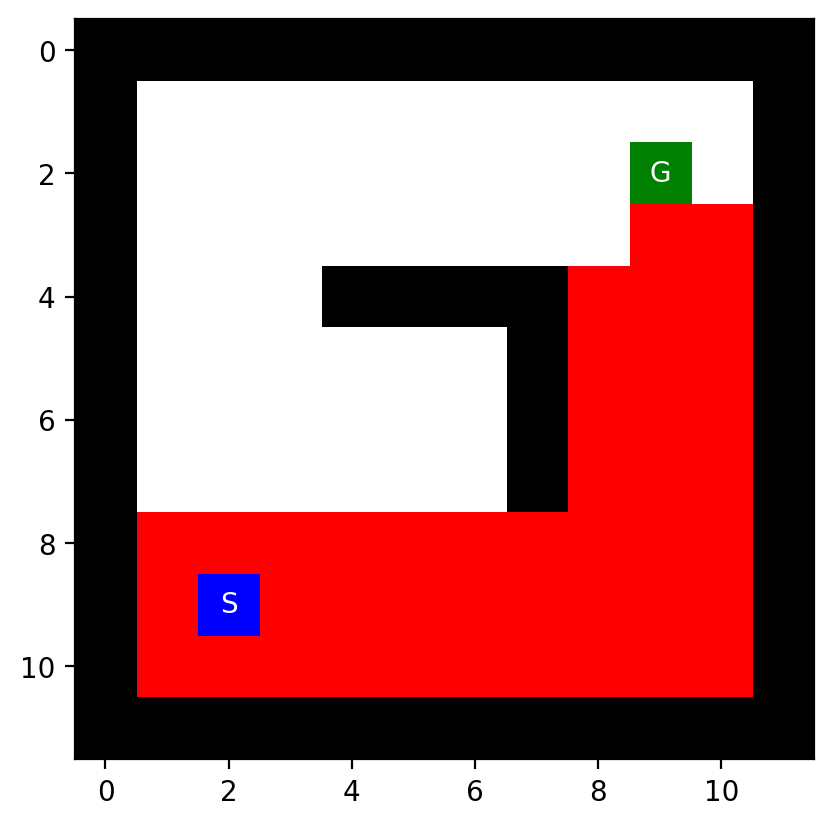

,Algorithm,Path Cost,Nodes Expanded,Max Tree Depth,Max Frontier Size,max memory usage
0,DFS,44,44,43,36,79


In [20]:
def DFS(maze, start, goal):
    #  Initialize the initial node and check if it's the goal
    initial_node = Node(pos=start)
    if start == goal:  # Check if the initial state is the goal
        return initial_node.get_path_from_root()

    #  Initialize the frontier (FIFO queue) and reached set
    frontier = [initial_node]  # Frontier initialized with the initial node
    reached = set()  # Reached set to track visited nodes
    visited = []  # List to track visited nodes in order
    branch = []   # List to track branching points
    nodes_expanded = 0
    max_tree_depth = 0
    max_frontier_size = 1  # Maximum size of the frontier (starts with 1, the initial node)
    max_memory_usage = 1  # Maximum number of nodes in memory (frontier + reached)
    while frontier:
        node = frontier.pop(-1)  # DFS uses LIFO, so we pop from the end (stack behavior)
        nodes_expanded += 1
        node1 = [(node.pos[0] - 1, node.pos[1]), (node.pos[0] + 1, node.pos[1]), 
                 (node.pos[0], node.pos[1] - 1), (node.pos[0], node.pos[1] + 1)]

        # Remove start and goal positions from neighbor list if present
        if mh.find_pos(maze, what="S") in node1:
            node1.pop(node1.index(mh.find_pos(maze, what="S")))
        if mh.find_pos(maze, what="G") in node1:
            node1.pop(node1.index(mh.find_pos(maze, what="G")))

        # Pruning branches if necessary
        while len(visited) > 2 and (visited[-1] not in node1):
            branch.pop(-1)
            last_branch_item = branch[-1]
            if last_branch_item in visited:
                index = visited.index(last_branch_item)
                visited1 = visited[:index + 1]
            for v in visited:
                if v not in visited1 and mh.look(maze, v) != 'G' and mh.look(maze, v) != 'S':
                    mark_maze(maze, v, ' ')
            visited = visited1

        visited.append(node.pos)

        # Mark the current position in the maze if it's not the start or goal
        if mh.look(maze, node.pos) != 'G' and mh.look(maze, node.pos) != 'S':
            mark_maze(maze, node.pos, '.')

        reached.add(node.pos)
        br = 0

        # **Addition**: Check if any neighbor of the current node is the goal
        for dx, dy, action in ACTIONS:
            next_pos = (node.pos[0] + dx, node.pos[1] + dy)  # Calculate next position
            if next_pos == goal:  # Early exit if the next position is the goal
                child = Node(next_pos, node, action, node.cost + 1)
                solution_path = child.get_path_from_root()
                path_cost = len(solution_path) - 1
                # Mark the solution path in the maze
                for path_node in solution_path:
                    if mh.look(maze, path_node.pos) != 'G' and mh.look(maze, path_node.pos) != 'S':
                        mark_maze(maze, path_node.pos, 'P')
                    clear_output(wait=True)
                    mh.show_maze(maze)
                return solution_path, path_cost, nodes_expanded, max_tree_depth, max_frontier_size,max_memory_usage

        # **Continuation of your code**: Expand the search by adding child nodes
        for dx, dy, action in ACTIONS:
            next_pos = (node.pos[0] + dx, node.pos[1] + dy)  # Next position

            if mh.look(maze, next_pos) != 'X' and next_pos not in visited:  # Valid position
                br += 1
                child = Node(next_pos, node, action, node.cost + 1)
                frontier.append(child)  # Add child to frontier
                max_tree_depth = max(max_tree_depth, child.cost)
                max_frontier_size = max(max_frontier_size, len(frontier))
                if br >= 2:
                    branch.append(node.pos)

                if mh.look(maze, node.pos) == 'G' and len(reached) >= 15:
                    last_branch_item = branch[-1]
                    if last_branch_item in visited:
                        index = visited.index(last_branch_item)
                        visited1 = visited[:index + 1]
                    for v in visited:
                        if v not in visited1 and mh.look(maze, v) != 'G' and mh.look(maze, v) != 'S':
                            mark_maze(maze, v, ' ')
                    visited = visited1
                    continue            

        if br == 0 and node.pos in visited:
            last_branch_item = branch[-1]
            if last_branch_item in visited:
                index = visited.index(last_branch_item)
                visited1 = visited[:index + 1]
            for v in visited:
                if v not in visited1 and mh.look(maze, v) != 'G' and mh.look(maze, v) != 'S':
                    mark_maze(maze, v, ' ')
            visited = visited1
            continue

        max_memory_usage = max(max_memory_usage, len(frontier) + len(reached))
        clear_output(wait=True)
        mh.show_maze(maze)
with open("wall_maze.txt", "r") as f:
    maze_str = f.read()
maze = mh.parse_maze(maze_str)
start= mh.find_pos(maze, what = "S")
goal= mh.find_pos(maze, what = "G")
print('start point is',start,'goal point is',goal)
[solution_path,DFS_wall_path_cost,DFS_wall_nodes_expanded,DFS_wall_max_tree_depth, DFS_wall_max_frontier_size,DFS_wall_memory_usage] = DFS(maze, start, goal)
data = {
    'Algorithm': ['DFS'],
    'Path Cost': [DFS_wall_path_cost],
    'Nodes Expanded': [DFS_wall_nodes_expanded],
    'Max Tree Depth': [DFS_wall_max_tree_depth],
    'Max Frontier Size': [DFS_wall_max_frontier_size],
    'max memory usage':[DFS_wall_memory_usage]
}

# Create a DataFrame
df = pd.DataFrame(data)
df

### Depth-First-search for loops-maze

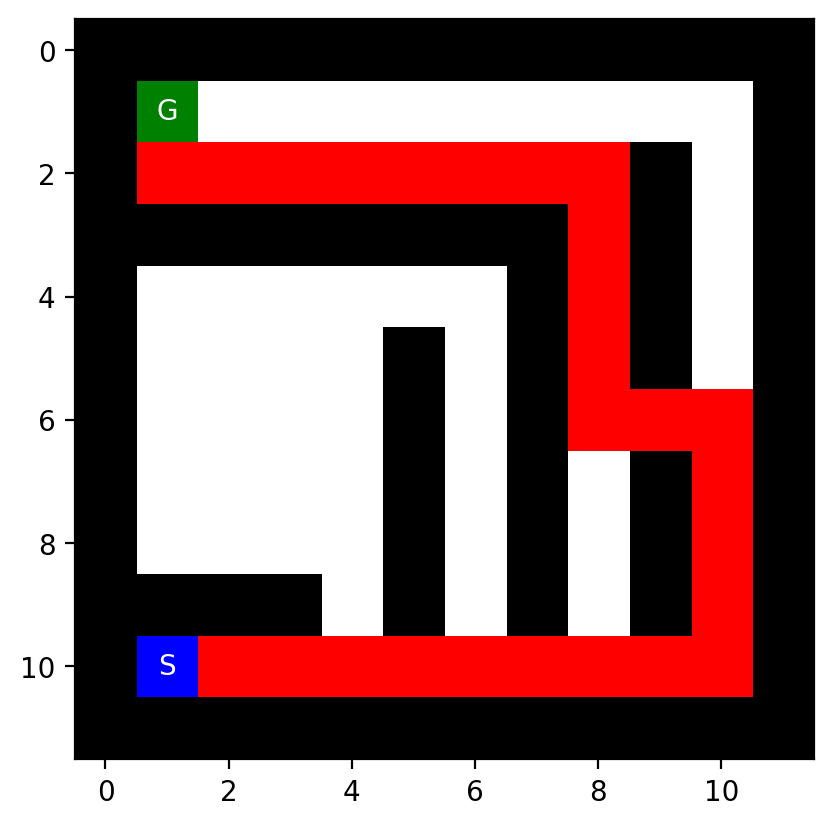

,Algorithm,Path Cost,Nodes Expanded,Max Tree Depth,Max Frontier Size,max memory usage
0,DFS,27,30,26,12,41


In [21]:
def DFS(maze, start, goal):
    #  Initialize the initial node and check if it's the goal
    initial_node = Node(pos=start)
    if start == goal:  # Check if the initial state is the goal
        return initial_node.get_path_from_root()

    #  Initialize the frontier (FIFO queue) and reached set
    frontier = [initial_node]  # Frontier initialized with the initial node
    reached = set()  # Reached set to track visited nodes
    visited = []  # List to track visited nodes in order
    branch = []   # List to track branching points
    nodes_expanded = 0
    max_tree_depth = 0
    max_frontier_size = 1  # Maximum size of the frontier (starts with 1, the initial node)
    max_memory_usage = 1  # Maximum number of nodes in memory (frontier + reached)
    while frontier:
        node = frontier.pop(-1)  # DFS uses LIFO, so we pop from the end (stack behavior)
        nodes_expanded += 1
        node1 = [(node.pos[0] - 1, node.pos[1]), (node.pos[0] + 1, node.pos[1]), 
                 (node.pos[0], node.pos[1] - 1), (node.pos[0], node.pos[1] + 1)]

        # Remove start and goal positions from neighbor list if present
        if mh.find_pos(maze, what="S") in node1:
            node1.pop(node1.index(mh.find_pos(maze, what="S")))
        if mh.find_pos(maze, what="G") in node1:
            node1.pop(node1.index(mh.find_pos(maze, what="G")))

        # Pruning branches if necessary
        while len(visited) > 2 and (visited[-1] not in node1):
            branch.pop(-1)
            last_branch_item = branch[-1]
            if last_branch_item in visited:
                index = visited.index(last_branch_item)
                visited1 = visited[:index + 1]
            for v in visited:
                if v not in visited1 and mh.look(maze, v) != 'G' and mh.look(maze, v) != 'S':
                    mark_maze(maze, v, ' ')
            visited = visited1

        visited.append(node.pos)

        # Mark the current position in the maze if it's not the start or goal
        if mh.look(maze, node.pos) != 'G' and mh.look(maze, node.pos) != 'S':
            mark_maze(maze, node.pos, '.')

        reached.add(node.pos)
        br = 0

        # **Addition**: Check if any neighbor of the current node is the goal
        for dx, dy, action in ACTIONS:
            next_pos = (node.pos[0] + dx, node.pos[1] + dy)  # Calculate next position
            if next_pos == goal:  # Early exit if the next position is the goal
                child = Node(next_pos, node, action, node.cost + 1)
                solution_path = child.get_path_from_root()
                path_cost = len(solution_path) - 1
                # Mark the solution path in the maze
                for path_node in solution_path:
                    if mh.look(maze, path_node.pos) != 'G' and mh.look(maze, path_node.pos) != 'S':
                        mark_maze(maze, path_node.pos, 'P')
                    clear_output(wait=True)
                    mh.show_maze(maze)
                return solution_path, path_cost, nodes_expanded, max_tree_depth, max_frontier_size,max_memory_usage

        # **Continuation of your code**: Expand the search by adding child nodes
        for dx, dy, action in ACTIONS:
            next_pos = (node.pos[0] + dx, node.pos[1] + dy)  # Next position

            if mh.look(maze, next_pos) != 'X' and next_pos not in visited:  # Valid position
                br += 1
                child = Node(next_pos, node, action, node.cost + 1)
                frontier.append(child)  # Add child to frontier
                max_tree_depth = max(max_tree_depth, child.cost)
                max_frontier_size = max(max_frontier_size, len(frontier))
                if br >= 2:
                    branch.append(node.pos)

                if mh.look(maze, node.pos) == 'G' and len(reached) >= 15:
                    last_branch_item = branch[-1]
                    if last_branch_item in visited:
                        index = visited.index(last_branch_item)
                        visited1 = visited[:index + 1]
                    for v in visited:
                        if v not in visited1 and mh.look(maze, v) != 'G' and mh.look(maze, v) != 'S':
                            mark_maze(maze, v, ' ')
                    visited = visited1
                    continue            

        if br == 0 and node.pos in visited:
            last_branch_item = branch[-1]
            if last_branch_item in visited:
                index = visited.index(last_branch_item)
                visited1 = visited[:index + 1]
            for v in visited:
                if v not in visited1 and mh.look(maze, v) != 'G' and mh.look(maze, v) != 'S':
                    mark_maze(maze, v, ' ')
            visited = visited1
            continue

        max_memory_usage = max(max_memory_usage, len(frontier) + len(reached))
        clear_output(wait=True)
        mh.show_maze(maze)
with open("loops_maze.txt", "r") as f:
    maze_str = f.read()
maze = mh.parse_maze(maze_str)
start= mh.find_pos(maze, what = "S")
goal= mh.find_pos(maze, what = "G")
print('start point is',start,'goal point is',goal)
[solution_path,DFS_loops_path_cost,DFS_loops_nodes_expanded,DFS_loops_max_tree_depth, DFS_loops_max_frontier_size,DFS_loops_memory_usage] = DFS(maze, start, goal)
data = {
    'Algorithm': ['DFS'],
    'Path Cost': [DFS_loops_path_cost],
    'Nodes Expanded': [DFS_loops_nodes_expanded],
    'Max Tree Depth': [DFS_loops_max_tree_depth],
    'Max Frontier Size': [DFS_loops_max_frontier_size],
    'max memory usage':[DFS_loops_memory_usage]
}

# Create a DataFrame
df = pd.DataFrame(data)
df

### Depth-First-search for empty-maze

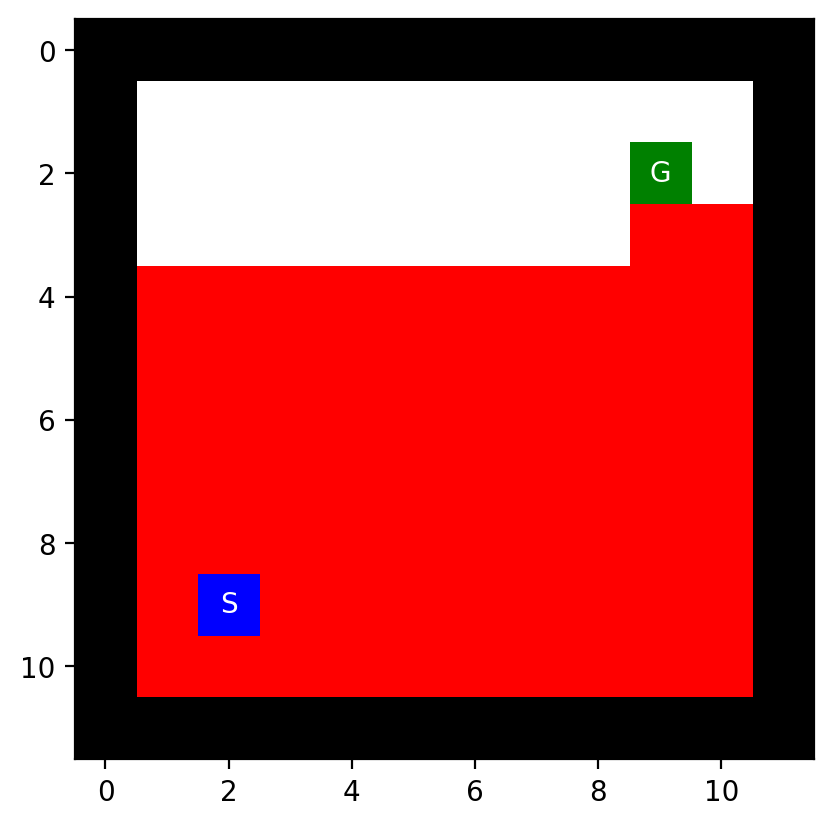

,Algorithm,Path Cost,Nodes Expanded,Max Tree Depth,Max Frontier Size,max memory usage
0,DFS,72,72,71,65,136


In [22]:
def DFS(maze, start, goal):
    #  Initialize the initial node and check if it's the goal
    initial_node = Node(pos=start)
    if start == goal:  # Check if the initial state is the goal
        return initial_node.get_path_from_root()

    #  Initialize the frontier (FIFO queue) and reached set
    frontier = [initial_node]  # Frontier initialized with the initial node
    reached = set()  # Reached set to track visited nodes
    visited = []  # List to track visited nodes in order
    branch = []   # List to track branching points
    nodes_expanded = 0
    max_tree_depth = 0
    max_frontier_size = 1  # Maximum size of the frontier (starts with 1, the initial node)
    max_memory_usage = 1  # Maximum number of nodes in memory (frontier + reached)
    while frontier:
        node = frontier.pop(-1)  # DFS uses LIFO, so we pop from the end (stack behavior)
        nodes_expanded += 1
        node1 = [(node.pos[0] - 1, node.pos[1]), (node.pos[0] + 1, node.pos[1]), 
                 (node.pos[0], node.pos[1] - 1), (node.pos[0], node.pos[1] + 1)]

        # Remove start and goal positions from neighbor list if present
        if mh.find_pos(maze, what="S") in node1:
            node1.pop(node1.index(mh.find_pos(maze, what="S")))
        if mh.find_pos(maze, what="G") in node1:
            node1.pop(node1.index(mh.find_pos(maze, what="G")))

        # Pruning branches if necessary
        while len(visited) > 2 and (visited[-1] not in node1):
            branch.pop(-1)
            last_branch_item = branch[-1]
            if last_branch_item in visited:
                index = visited.index(last_branch_item)
                visited1 = visited[:index + 1]
            for v in visited:
                if v not in visited1 and mh.look(maze, v) != 'G' and mh.look(maze, v) != 'S':
                    mark_maze(maze, v, ' ')
            visited = visited1

        visited.append(node.pos)

        # Mark the current position in the maze if it's not the start or goal
        if mh.look(maze, node.pos) != 'G' and mh.look(maze, node.pos) != 'S':
            mark_maze(maze, node.pos, '.')

        reached.add(node.pos)
        br = 0

        # **Addition**: Check if any neighbor of the current node is the goal
        for dx, dy, action in ACTIONS:
            next_pos = (node.pos[0] + dx, node.pos[1] + dy)  # Calculate next position
            if next_pos == goal:  # Early exit if the next position is the goal
                child = Node(next_pos, node, action, node.cost + 1)
                solution_path = child.get_path_from_root()
                path_cost = len(solution_path) - 1
                # Mark the solution path in the maze
                for path_node in solution_path:
                    if mh.look(maze, path_node.pos) != 'G' and mh.look(maze, path_node.pos) != 'S':
                        mark_maze(maze, path_node.pos, 'P')
                    clear_output(wait=True)
                    mh.show_maze(maze)
                return solution_path, path_cost, nodes_expanded, max_tree_depth, max_frontier_size,max_memory_usage

        # **Continuation of your code**: Expand the search by adding child nodes
        for dx, dy, action in ACTIONS:
            next_pos = (node.pos[0] + dx, node.pos[1] + dy)  # Next position

            if mh.look(maze, next_pos) != 'X' and next_pos not in visited:  # Valid position
                br += 1
                child = Node(next_pos, node, action, node.cost + 1)
                frontier.append(child)  # Add child to frontier
                max_tree_depth = max(max_tree_depth, child.cost)
                max_frontier_size = max(max_frontier_size, len(frontier))
                if br >= 2:
                    branch.append(node.pos)

                if mh.look(maze, node.pos) == 'G' and len(reached) >= 15:
                    last_branch_item = branch[-1]
                    if last_branch_item in visited:
                        index = visited.index(last_branch_item)
                        visited1 = visited[:index + 1]
                    for v in visited:
                        if v not in visited1 and mh.look(maze, v) != 'G' and mh.look(maze, v) != 'S':
                            mark_maze(maze, v, ' ')
                    visited = visited1
                    continue            

        if br == 0 and node.pos in visited:
            last_branch_item = branch[-1]
            if last_branch_item in visited:
                index = visited.index(last_branch_item)
                visited1 = visited[:index + 1]
            for v in visited:
                if v not in visited1 and mh.look(maze, v) != 'G' and mh.look(maze, v) != 'S':
                    mark_maze(maze, v, ' ')
            visited = visited1
            continue

        max_memory_usage = max(max_memory_usage, len(frontier) + len(reached))
        clear_output(wait=True)
        mh.show_maze(maze)
with open("empty_maze.txt", "r") as f:
    maze_str = f.read()
maze = mh.parse_maze(maze_str)
start= mh.find_pos(maze, what = "S")
goal= mh.find_pos(maze, what = "G")
print('start point is',start,'goal point is',goal)
[solution_path,DFS_empty_path_cost,DFS_empty_nodes_expanded,DFS_empty_max_tree_depth, DFS_empty_max_frontier_size,DFS_empty_memory_usage] = DFS(maze, start, goal)
data = {
    'Algorithm': ['DFS'],
    'Path Cost': [DFS_empty_path_cost],
    'Nodes Expanded': [DFS_empty_nodes_expanded],
    'Max Tree Depth': [DFS_empty_max_tree_depth],
    'Max Frontier Size': [DFS_empty_max_frontier_size],
    'max memory usage':[DFS_empty_memory_usage]
}

# Create a DataFrame
df = pd.DataFrame(data)
df

### Depth-First-search for empty_2-maze

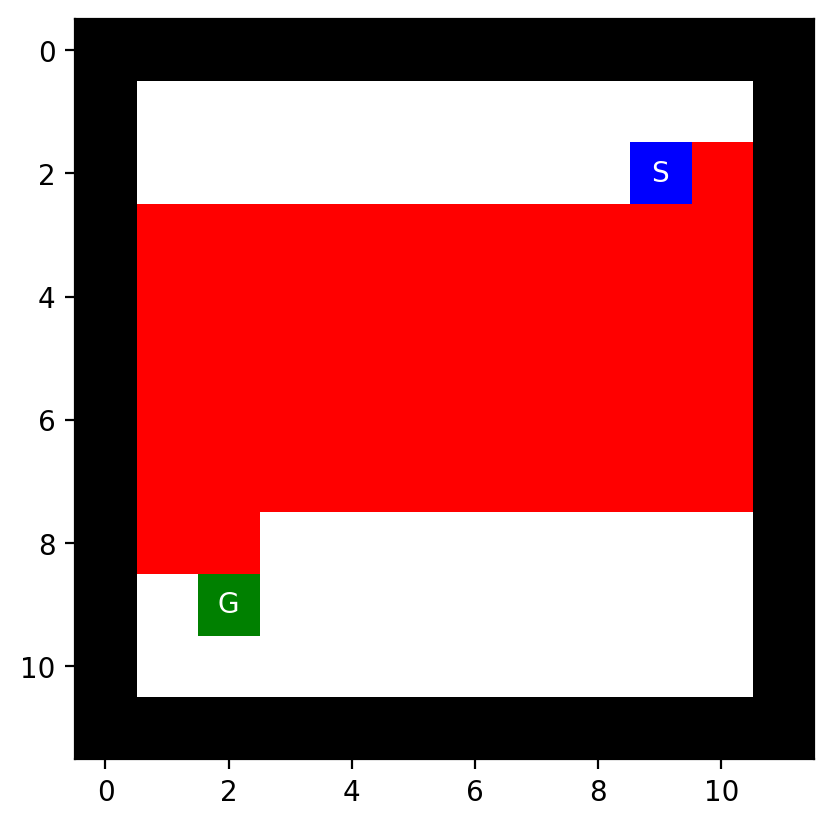

,Algorithm,Path Cost,Nodes Expanded,Max Tree Depth,Max Frontier Size,max memory usage
0,DFS,54,54,53,59,112


In [23]:
def DFS(maze, start, goal):
    #  Initialize the initial node and check if it's the goal
    initial_node = Node(pos=start)
    if start == goal:  # Check if the initial state is the goal
        return initial_node.get_path_from_root()

    #  Initialize the frontier (FIFO queue) and reached set
    frontier = [initial_node]  # Frontier initialized with the initial node
    reached = set()  # Reached set to track visited nodes
    visited = []  # List to track visited nodes in order
    branch = []   # List to track branching points
    nodes_expanded = 0
    max_tree_depth = 0
    max_frontier_size = 1  # Maximum size of the frontier (starts with 1, the initial node)
    max_memory_usage = 1  # Maximum number of nodes in memory (frontier + reached)
    while frontier:
        node = frontier.pop(-1)  # DFS uses LIFO, so we pop from the end (stack behavior)
        nodes_expanded += 1
        node1 = [(node.pos[0] - 1, node.pos[1]), (node.pos[0] + 1, node.pos[1]), 
                 (node.pos[0], node.pos[1] - 1), (node.pos[0], node.pos[1] + 1)]

        # Remove start and goal positions from neighbor list if present
        if mh.find_pos(maze, what="S") in node1:
            node1.pop(node1.index(mh.find_pos(maze, what="S")))
        if mh.find_pos(maze, what="G") in node1:
            node1.pop(node1.index(mh.find_pos(maze, what="G")))

        # Pruning branches if necessary
        while len(visited) > 2 and (visited[-1] not in node1):
            branch.pop(-1)
            last_branch_item = branch[-1]
            if last_branch_item in visited:
                index = visited.index(last_branch_item)
                visited1 = visited[:index + 1]
            for v in visited:
                if v not in visited1 and mh.look(maze, v) != 'G' and mh.look(maze, v) != 'S':
                    mark_maze(maze, v, ' ')
            visited = visited1

        visited.append(node.pos)

        # Mark the current position in the maze if it's not the start or goal
        if mh.look(maze, node.pos) != 'G' and mh.look(maze, node.pos) != 'S':
            mark_maze(maze, node.pos, '.')

        reached.add(node.pos)
        br = 0

        # **Addition**: Check if any neighbor of the current node is the goal
        for dx, dy, action in ACTIONS:
            next_pos = (node.pos[0] + dx, node.pos[1] + dy)  # Calculate next position
            if next_pos == goal:  # Early exit if the next position is the goal
                child = Node(next_pos, node, action, node.cost + 1)
                solution_path = child.get_path_from_root()
                path_cost = len(solution_path) - 1
                # Mark the solution path in the maze
                for path_node in solution_path:
                    if mh.look(maze, path_node.pos) != 'G' and mh.look(maze, path_node.pos) != 'S':
                        mark_maze(maze, path_node.pos, 'P')
                    clear_output(wait=True)
                    mh.show_maze(maze)
                return solution_path, path_cost, nodes_expanded, max_tree_depth, max_frontier_size,max_memory_usage

        # **Continuation of your code**: Expand the search by adding child nodes
        for dx, dy, action in ACTIONS:
            next_pos = (node.pos[0] + dx, node.pos[1] + dy)  # Next position

            if mh.look(maze, next_pos) != 'X' and next_pos not in visited:  # Valid position
                br += 1
                child = Node(next_pos, node, action, node.cost + 1)
                frontier.append(child)  # Add child to frontier
                max_tree_depth = max(max_tree_depth, child.cost)
                max_frontier_size = max(max_frontier_size, len(frontier))
                if br >= 2:
                    branch.append(node.pos)

                if mh.look(maze, node.pos) == 'G' and len(reached) >= 15:
                    last_branch_item = branch[-1]
                    if last_branch_item in visited:
                        index = visited.index(last_branch_item)
                        visited1 = visited[:index + 1]
                    for v in visited:
                        if v not in visited1 and mh.look(maze, v) != 'G' and mh.look(maze, v) != 'S':
                            mark_maze(maze, v, ' ')
                    visited = visited1
                    continue            

        if br == 0 and node.pos in visited:
            last_branch_item = branch[-1]
            if last_branch_item in visited:
                index = visited.index(last_branch_item)
                visited1 = visited[:index + 1]
            for v in visited:
                if v not in visited1 and mh.look(maze, v) != 'G' and mh.look(maze, v) != 'S':
                    mark_maze(maze, v, ' ')
            visited = visited1
            continue

        max_memory_usage = max(max_memory_usage, len(frontier) + len(reached))
        clear_output(wait=True)
        mh.show_maze(maze)
with open("empty_2_maze.txt", "r") as f:
    maze_str = f.read()
maze = mh.parse_maze(maze_str)
start= mh.find_pos(maze, what = "S")
goal= mh.find_pos(maze, what = "G")
print('start point is',start,'goal point is',goal)
[solution_path,DFS_empty_2_path_cost,DFS_empty_2_nodes_expanded,DFS_empty_2_max_tree_depth, DFS_empty_2_max_frontier_size,DFS_empty_2_memory_usage] = DFS(maze, start, goal)
data = {
    'Algorithm': ['DFS'],
    'Path Cost': [DFS_empty_2_path_cost],
    'Nodes Expanded': [DFS_empty_2_nodes_expanded],
    'Max Tree Depth': [DFS_empty_2_max_tree_depth],
    'Max Frontier Size': [DFS_empty_2_max_frontier_size],
    'max memory usage':[DFS_empty_2_memory_usage]
}

# Create a DataFrame
df = pd.DataFrame(data)
df

### Depth-First-search for open-maze

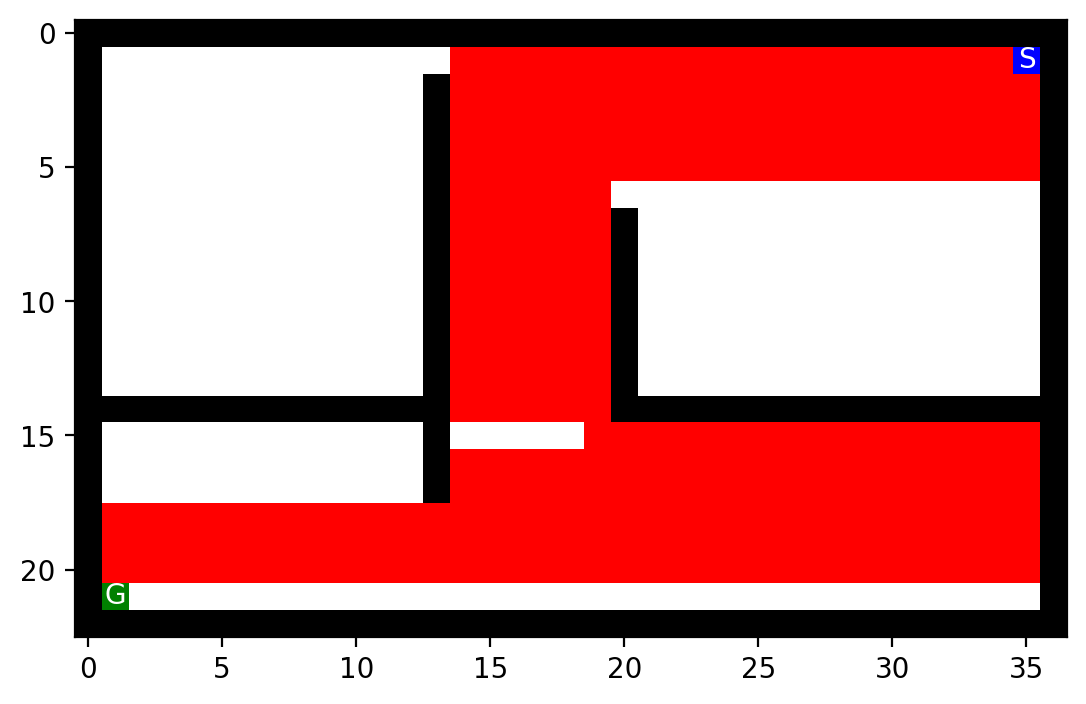

,Algorithm,Path Cost,Nodes Expanded,Max Tree Depth,Max Frontier Size,max memory usage
0,DFS,330,7595,329,329,936


In [24]:
def DFS(maze, start, goal):
    #  Initialize the initial node and check if it's the goal
    initial_node = Node(pos=start)
    if start == goal:  # Check if the initial state is the goal
        return initial_node.get_path_from_root()

    #  Initialize the frontier (FIFO queue) and reached set
    frontier = [initial_node]  # Frontier initialized with the initial node
    reached = set()  # Reached set to track visited nodes
    visited = []  # List to track visited nodes in order
    branch = []   # List to track branching points
    nodes_expanded = 0
    max_tree_depth = 0
    max_frontier_size = 1  # Maximum size of the frontier (starts with 1, the initial node)
    max_memory_usage = 1  # Maximum number of nodes in memory (frontier + reached)
    while frontier:
        node = frontier.pop(-1)  # DFS uses LIFO, so we pop from the end (stack behavior)
        nodes_expanded += 1
        node1 = [(node.pos[0] - 1, node.pos[1]), (node.pos[0] + 1, node.pos[1]), 
                 (node.pos[0], node.pos[1] - 1), (node.pos[0], node.pos[1] + 1)]

        # Remove start and goal positions from neighbor list if present
        if mh.find_pos(maze, what="S") in node1:
            node1.pop(node1.index(mh.find_pos(maze, what="S")))
        if mh.find_pos(maze, what="G") in node1:
            node1.pop(node1.index(mh.find_pos(maze, what="G")))

        # Pruning branches if necessary
        while len(visited) > 2 and (visited[-1] not in node1):
            branch.pop(-1)
            last_branch_item = branch[-1]
            if last_branch_item in visited:
                index = visited.index(last_branch_item)
                visited1 = visited[:index + 1]
            for v in visited:
                if v not in visited1 and mh.look(maze, v) != 'G' and mh.look(maze, v) != 'S':
                    mark_maze(maze, v, ' ')
            visited = visited1

        visited.append(node.pos)

        # Mark the current position in the maze if it's not the start or goal
        if mh.look(maze, node.pos) != 'G' and mh.look(maze, node.pos) != 'S':
            mark_maze(maze, node.pos, '.')

        reached.add(node.pos)
        br = 0

        # **Addition**: Check if any neighbor of the current node is the goal
        for dx, dy, action in ACTIONS:
            next_pos = (node.pos[0] + dx, node.pos[1] + dy)  # Calculate next position
            if next_pos == goal:  # Early exit if the next position is the goal
                child = Node(next_pos, node, action, node.cost + 1)
                solution_path = child.get_path_from_root()
                path_cost = len(solution_path) - 1
                # Mark the solution path in the maze
                for path_node in solution_path:
                    if mh.look(maze, path_node.pos) != 'G' and mh.look(maze, path_node.pos) != 'S':
                        mark_maze(maze, path_node.pos, 'P')
                    clear_output(wait=True)
                    mh.show_maze(maze)
                return solution_path, path_cost, nodes_expanded, max_tree_depth, max_frontier_size,max_memory_usage

        # **Continuation of your code**: Expand the search by adding child nodes
        for dx, dy, action in ACTIONS:
            next_pos = (node.pos[0] + dx, node.pos[1] + dy)  # Next position

            if mh.look(maze, next_pos) != 'X' and next_pos not in visited:  # Valid position
                br += 1
                child = Node(next_pos, node, action, node.cost + 1)
                frontier.append(child)  # Add child to frontier
                max_tree_depth = max(max_tree_depth, child.cost)
                max_frontier_size = max(max_frontier_size, len(frontier))
                if br >= 2:
                    branch.append(node.pos)

                if mh.look(maze, node.pos) == 'G' and len(reached) >= 15:
                    last_branch_item = branch[-1]
                    if last_branch_item in visited:
                        index = visited.index(last_branch_item)
                        visited1 = visited[:index + 1]
                    for v in visited:
                        if v not in visited1 and mh.look(maze, v) != 'G' and mh.look(maze, v) != 'S':
                            mark_maze(maze, v, ' ')
                    visited = visited1
                    continue            

        if br == 0 and node.pos in visited:
            last_branch_item = branch[-1]
            if last_branch_item in visited:
                index = visited.index(last_branch_item)
                visited1 = visited[:index + 1]
            for v in visited:
                if v not in visited1 and mh.look(maze, v) != 'G' and mh.look(maze, v) != 'S':
                    mark_maze(maze, v, ' ')
            visited = visited1
            continue

        max_memory_usage = max(max_memory_usage, len(frontier) + len(reached))
        clear_output(wait=True)
        mh.show_maze(maze)
with open("open_maze.txt", "r") as f:
    maze_str = f.read()
maze = mh.parse_maze(maze_str)
start= mh.find_pos(maze, what = "S")
goal= mh.find_pos(maze, what = "G")
print('start point is',start,'goal point is',goal)
[solution_path,DFS_open_path_cost,DFS_open_nodes_expanded,DFS_open_max_tree_depth, DFS_open_max_frontier_size,DFS_open_memory_usage] = DFS(maze, start, goal)
data = {
    'Algorithm': ['DFS'],
    'Path Cost': [DFS_open_path_cost],
    'Nodes Expanded': [DFS_open_nodes_expanded],
    'Max Tree Depth': [DFS_open_max_tree_depth],
    'Max Frontier Size': [DFS_open_max_frontier_size],
    'max memory usage':[DFS_open_memory_usage]
}

# Create a DataFrame
df = pd.DataFrame(data)
df

### How does BFS and DFS (without a reached data structure) deal with loops (cycles)?

In DFS, the search may revisit nodes it has previously explored if a cycle is present and there is no reached/visited set to track the explored nodes. This could result in an endless loop. For instance, in a cyclic graph, DFS might continuously loop through the cycle by reexamining a node and its children.
BFS effectively blocks revisits, protecting against cycles. Every node will only be investigated once, because of existance of the reached set. BFS will bypasses previously visited nodes, saving unnecessary exploration and queue operations.

### Are your implementations complete and optimal? Explain why. What is the time and space complexity of each of **your** implementations? Especially discuss the difference in space complexity between BFS and DFS.

First, let's discuss the completeness. BFS finally finds a solution (if one exists) since it investigates every node level by level . Even in the presence of cycles, BFS will terminate due to the reached structure.In contrast without a reached structure, DFS may get trapped in an infinite loop if there are cycles. In cases where the graph is infinite or contains cycles, DFS might never reach a solution (incomplete), even if one exists. But in finite search spaces it is complete.

Regarding the optimality of the solution, BFS investigates nodes level by level, which means that the first time a solution is found, it will be the shortest (optimal) path . DFS returns the first solution it finds, therefore it might find a solution that is not the shortest or most efficient.

BFS Time complexity is O(b^d), where "b" is the branching factor (average number of child nodes per state), and "d" is the depth of the shallowest goal node. In the worst case, BFS may explore the entire state space.

BFS Space complexity is O(b^d), as BFS stores all generated nodes in memory until the goal
state is found or the entire tree is explored. In the worst case, it stores all nodes at the
maximum depth "d".

DFS Time complexity is O(b^m), where "b" is the branching factor and "m" is the maximum
depth of the state space. In the worst case, DFS may explore the entire depth-first
branch before backtracking.

DFS Space Complexity is O(bm) if no reached data structure and memory management (forget old branches) is used, where "b" is the branching factor, and "m" is the maximum depth of the state space. 

## Task 3: Informed search: Implement greedy best-first search and A* search  [20 Points]

You can use the map to estimate the distance from your current position to the goal using the Manhattan distance (see https://en.wikipedia.org/wiki/Taxicab_geometry) as a heuristic function. Both algorithms are based on Best-First search which requires only a small change from the BFS algorithm you have already implemented (see textbook/slides).

### greedy best-first search for small maze

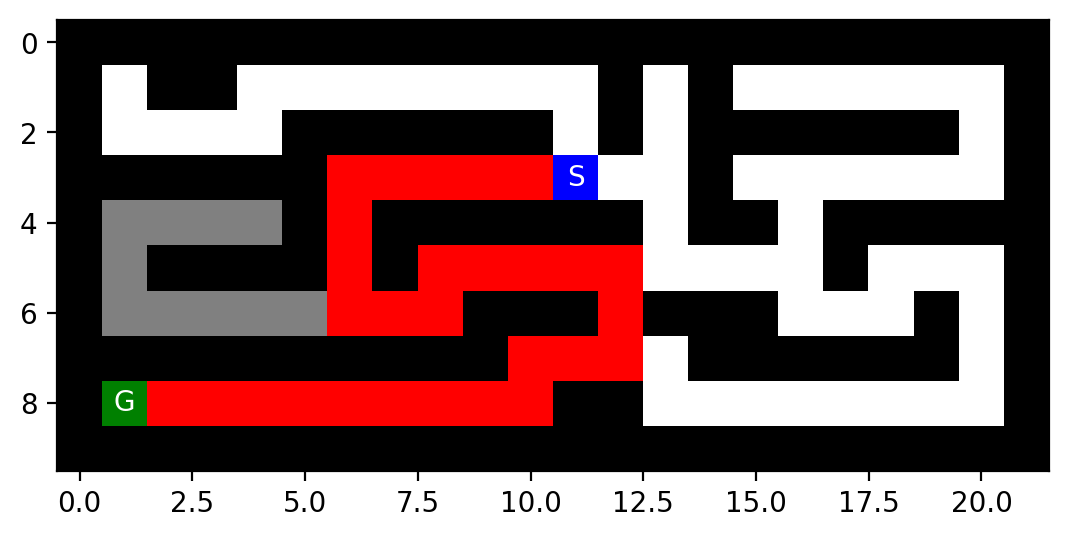

,Algorithm,Path Cost,Nodes Expanded,Max Tree Depth,Max Frontier Size,max memory usage
0,Greedy_BFS,29,39,29,48,90


In [25]:

class Node:
    def __init__(self, pos, parent=None, action=None, cost=0,h=0):
        self.pos = tuple(pos)    # the state; positions are (row,col)
        self.parent = parent     # reference to parent node. None means root node.
        self.action = action     # action used in the transition function (root node has None)
        self.cost = cost         # for uniform cost this is the depth. It is also g(n) for A* search
        self.h = h         # for manhattan distance
    def __str__(self):
        return f"Node - pos = {self.pos}; action = {self.action}; cost = {self.cost}"

    def get_path_from_root(self):
        """returns nodes on the path from the root to the current node."""
        node = self
        path = [node]

        while not node.parent is None:
            node = node.parent
            path.append(node)
            

        path.reverse()

        return(path)
def manhattan_distance(pos, goal):
    """Calculate the Manhattan distance from current position to goal."""
    return abs(pos[0] - goal[0]) + abs(pos[1] - goal[1])

def sorting(frontier, node):
    """Insert the node into the frontier, maintaining the list sorted by heuristic h(n)."""
    inserted = False
    for i in range(len(frontier)):
        if node.h < frontier[i].h:
            frontier.insert(i, node)
            inserted = True
            break
    if not inserted:
        frontier.append(node)  # Insert at the end if not inserted earlier
            
ACTIONS = [(-1, 0, 'North'), (1, 0, 'South'), (0, -1, 'West'), (0, 1, 'East')]    
def mark_maze(maze, pos, symbol):
    """Marks the maze at a given position with a symbol."""
    maze[pos[0]][pos[1]] = symbol
    
def Greedy_BFS(maze, start, goal):
    #  Initialize the initial node and check if it's the goal
    initial_node = Node(pos=start,h=manhattan_distance(start, goal))
    if start == goal:  # Check if the initial state is the goal
        return initial_node.get_path_from_root()
    #  Initialize the frontier (FIFO queue) and reached set
    frontier = [initial_node]  # Frontier initialized with the initial node
    
    reached = set()  # reached set to track visited nodes
    reached.add(start)
    nodes_expanded = 0
    max_tree_depth = 0
    max_frontier_size = 1  # Maximum size of the frontier (starts with 1, the initial node)
    max_memory_usage = 1  # Maximum number of nodes in memory (frontier + reached)
    # Loop until we either find the goal or exhaust the frontier
    while frontier:
        
        node = frontier.pop(0)
        nodes_expanded += 1
        if mh.look(maze, node.pos)!='S':
            mark_maze(maze, node.pos, '.')
        
        
        for dx, dy, action in ACTIONS:
            next_pos = (node.pos[0] + dx, node.pos[1] + dy) #next position 
            if mh.look(maze, next_pos)!='X' and next_pos not in reached:
                reached.add(next_pos)
                
                # Create child nodes
                child = Node(next_pos, node, action, node.cost+1,h=manhattan_distance(next_pos, goal)) #child branch
                sorting(frontier, child)
                #print('child',child)
                frontier.append(child)
                max_tree_depth = max(max_tree_depth, child.cost)
                max_frontier_size = max(max_frontier_size, len(frontier))
                if mh.look(maze, next_pos)=='G':
                    solution_path = child.get_path_from_root()
                    path_cost = len(solution_path) - 1
                    for path_node in solution_path:
                        if mh.look(maze, path_node.pos)!='G' and mh.look(maze, path_node.pos)!='S':
                            mark_maze(maze, path_node.pos, 'P')
                            clear_output(wait=True)
                            mh.show_maze(maze)
                    return solution_path, path_cost, nodes_expanded, max_tree_depth, max_frontier_size,max_memory_usage

                
                
            else:
                #print('Wall')
                continue
        max_memory_usage = max(max_memory_usage, len(frontier) + len(reached))
        clear_output(wait=True)
        mh.show_maze(maze)     
    #return None
with open("small_maze.txt", "r") as f:
    maze_str = f.read()
maze = mh.parse_maze(maze_str)
start= mh.find_pos(maze, what = "S")
goal= mh.find_pos(maze, what = "G")
print('start point is',start,'goal point is',goal)
[solution_path,GBFS_small_path_cost,GBFS_small_nodes_expanded,GBFS_small_max_tree_depth, GBFS_small_max_frontier_size,GBFS_small_memory_usage] = Greedy_BFS(maze, start, goal)
data = {
    'Algorithm': ['Greedy_BFS'],
    'Path Cost': [GBFS_small_path_cost],
    'Nodes Expanded': [GBFS_small_nodes_expanded],
    'Max Tree Depth': [GBFS_small_max_tree_depth],
    'Max Frontier Size': [GBFS_small_max_frontier_size],
    'max memory usage':[GBFS_small_memory_usage]
}

# Create a DataFrame
df = pd.DataFrame(data)
df

### greedy best-first search for medium maze

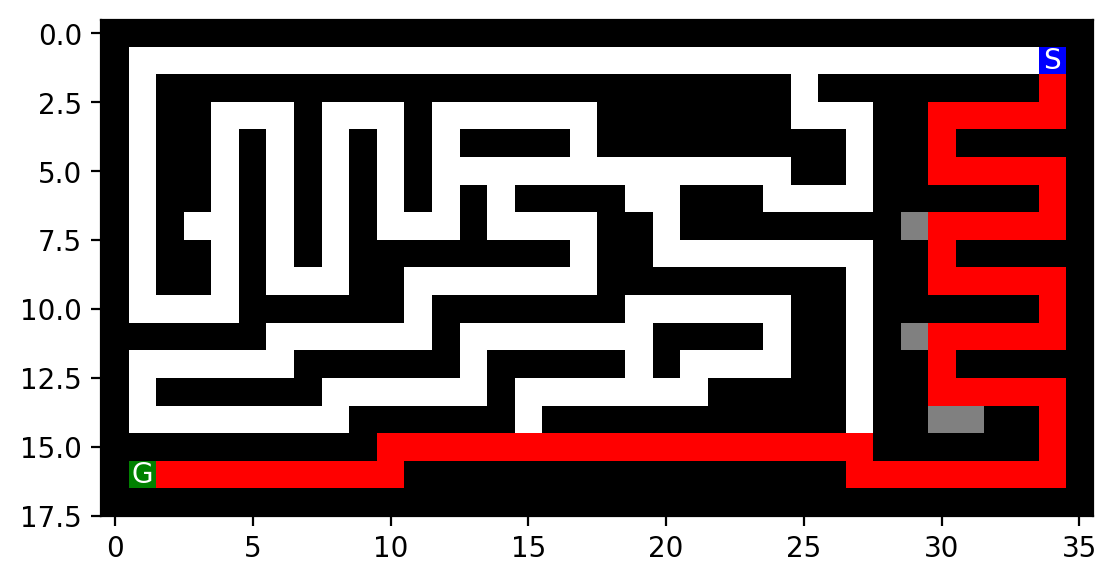

,Algorithm,Path Cost,Nodes Expanded,Max Tree Depth,Max Frontier Size,max memory usage
0,Greedy_BFS,74,78,74,85,165


In [26]:

class Node:
    def __init__(self, pos, parent=None, action=None, cost=0,h=0):
        self.pos = tuple(pos)    # the state; positions are (row,col)
        self.parent = parent     # reference to parent node. None means root node.
        self.action = action     # action used in the transition function (root node has None)
        self.cost = cost         # for uniform cost this is the depth. It is also g(n) for A* search
        self.h = h         # for manhattan distance
    def __str__(self):
        return f"Node - pos = {self.pos}; action = {self.action}; cost = {self.cost}"

    def get_path_from_root(self):
        """returns nodes on the path from the root to the current node."""
        node = self
        path = [node]

        while not node.parent is None:
            node = node.parent
            path.append(node)
            

        path.reverse()

        return(path)
def manhattan_distance(pos, goal):
    """Calculate the Manhattan distance from current position to goal."""
    return abs(pos[0] - goal[0]) + abs(pos[1] - goal[1])

def sorting(frontier, node):
    """Insert the node into the frontier, maintaining the list sorted by heuristic h(n)."""
    inserted = False
    for i in range(len(frontier)):
        if node.h < frontier[i].h:
            frontier.insert(i, node)
            inserted = True
            break
    if not inserted:
        frontier.append(node)  # Insert at the end if not inserted earlier
            
ACTIONS = [(-1, 0, 'North'), (1, 0, 'South'), (0, -1, 'West'), (0, 1, 'East')]    
def mark_maze(maze, pos, symbol):
    """Marks the maze at a given position with a symbol."""
    maze[pos[0]][pos[1]] = symbol
    
def Greedy_BFS(maze, start, goal):
    #  Initialize the initial node and check if it's the goal
    initial_node = Node(pos=start,h=manhattan_distance(start, goal))
    if start == goal:  # Check if the initial state is the goal
        return initial_node.get_path_from_root()
    #  Initialize the frontier (FIFO queue) and reached set
    frontier = [initial_node]  # Frontier initialized with the initial node
    
    reached = set()  # reached set to track visited nodes
    reached.add(start)
    nodes_expanded = 0
    max_tree_depth = 0
    max_frontier_size = 1  # Maximum size of the frontier (starts with 1, the initial node)
    max_memory_usage = 1  # Maximum number of nodes in memory (frontier + reached)
    # Loop until we either find the goal or exhaust the frontier
    while frontier:
        
        node = frontier.pop(0)
        nodes_expanded += 1
        if mh.look(maze, node.pos)!='S':
            mark_maze(maze, node.pos, '.')
        
        
        for dx, dy, action in ACTIONS:
            next_pos = (node.pos[0] + dx, node.pos[1] + dy) #next position 
            if mh.look(maze, next_pos)!='X' and next_pos not in reached:
                reached.add(next_pos)
                
                # Create child nodes
                child = Node(next_pos, node, action, node.cost+1,h=manhattan_distance(next_pos, goal)) #child branch
                sorting(frontier, child)
                #print('child',child)
                frontier.append(child)
                max_tree_depth = max(max_tree_depth, child.cost)
                max_frontier_size = max(max_frontier_size, len(frontier))
                if mh.look(maze, next_pos)=='G':
                    solution_path = child.get_path_from_root()
                    path_cost = len(solution_path) - 1
                    for path_node in solution_path:
                        if mh.look(maze, path_node.pos)!='G' and mh.look(maze, path_node.pos)!='S':
                            mark_maze(maze, path_node.pos, 'P')
                            clear_output(wait=True)
                            mh.show_maze(maze)
                    return solution_path, path_cost, nodes_expanded, max_tree_depth, max_frontier_size,max_memory_usage

                
                
            else:
                #print('Wall')
                continue
        max_memory_usage = max(max_memory_usage, len(frontier) + len(reached))
        clear_output(wait=True)
        mh.show_maze(maze)     
    #return None
with open("medium_maze.txt", "r") as f:
    maze_str = f.read()
maze = mh.parse_maze(maze_str)
start= mh.find_pos(maze, what = "S")
goal= mh.find_pos(maze, what = "G")
print('start point is',start,'goal point is',goal)
[solution_path,GBFS_medium_path_cost,GBFS_medium_nodes_expanded,GBFS_medium_max_tree_depth, GBFS_medium_max_frontier_size,GBFS_medium_memory_usage] = Greedy_BFS(maze, start, goal)
data = {
    'Algorithm': ['Greedy_BFS'],
    'Path Cost': [GBFS_medium_path_cost],
    'Nodes Expanded': [GBFS_medium_nodes_expanded],
    'Max Tree Depth': [GBFS_medium_max_tree_depth],
    'Max Frontier Size': [GBFS_medium_max_frontier_size],
    'max memory usage':[GBFS_medium_memory_usage]
}

# Create a DataFrame
df = pd.DataFrame(data)
df

### greedy best-first search for large maze

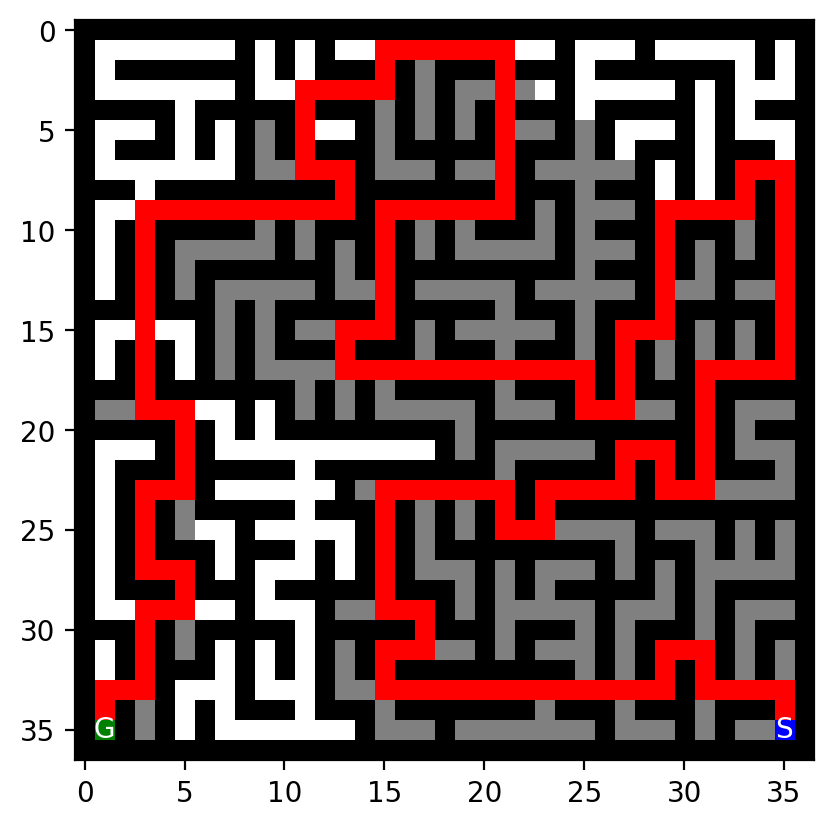

,Algorithm,Path Cost,Nodes Expanded,Max Tree Depth,Max Frontier Size,max memory usage
0,Greedy_BFS,210,668,210,305,790


In [27]:

class Node:
    def __init__(self, pos, parent=None, action=None, cost=0,h=0):
        self.pos = tuple(pos)    # the state; positions are (row,col)
        self.parent = parent     # reference to parent node. None means root node.
        self.action = action     # action used in the transition function (root node has None)
        self.cost = cost         # for uniform cost this is the depth. It is also g(n) for A* search
        self.h = h         # for manhattan distance
    def __str__(self):
        return f"Node - pos = {self.pos}; action = {self.action}; cost = {self.cost}"

    def get_path_from_root(self):
        """returns nodes on the path from the root to the current node."""
        node = self
        path = [node]

        while not node.parent is None:
            node = node.parent
            path.append(node)
            

        path.reverse()

        return(path)
def manhattan_distance(pos, goal):
    """Calculate the Manhattan distance from current position to goal."""
    return abs(pos[0] - goal[0]) + abs(pos[1] - goal[1])

def sorting(frontier, node):
    """Insert the node into the frontier, maintaining the list sorted by heuristic h(n)."""
    inserted = False
    for i in range(len(frontier)):
        if node.h < frontier[i].h:
            frontier.insert(i, node)
            inserted = True
            break
    if not inserted:
        frontier.append(node)  # Insert at the end if not inserted earlier
            
ACTIONS = [(-1, 0, 'North'), (1, 0, 'South'), (0, -1, 'West'), (0, 1, 'East')]    
def mark_maze(maze, pos, symbol):
    """Marks the maze at a given position with a symbol."""
    maze[pos[0]][pos[1]] = symbol
    
def Greedy_BFS(maze, start, goal):
    #  Initialize the initial node and check if it's the goal
    initial_node = Node(pos=start,h=manhattan_distance(start, goal))
    if start == goal:  # Check if the initial state is the goal
        return initial_node.get_path_from_root()
    #  Initialize the frontier (FIFO queue) and reached set
    frontier = [initial_node]  # Frontier initialized with the initial node
    
    reached = set()  # reached set to track visited nodes
    reached.add(start)
    nodes_expanded = 0
    max_tree_depth = 0
    max_frontier_size = 1  # Maximum size of the frontier (starts with 1, the initial node)
    max_memory_usage = 1  # Maximum number of nodes in memory (frontier + reached)
    # Loop until we either find the goal or exhaust the frontier
    while frontier:
        
        node = frontier.pop(0)
        nodes_expanded += 1
        if mh.look(maze, node.pos)!='S':
            mark_maze(maze, node.pos, '.')
        
        
        for dx, dy, action in ACTIONS:
            next_pos = (node.pos[0] + dx, node.pos[1] + dy) #next position 
            if mh.look(maze, next_pos)!='X' and next_pos not in reached:
                reached.add(next_pos)
                
                # Create child nodes
                child = Node(next_pos, node, action, node.cost+1,h=manhattan_distance(next_pos, goal)) #child branch
                sorting(frontier, child)
                #print('child',child)
                frontier.append(child)
                max_tree_depth = max(max_tree_depth, child.cost)
                max_frontier_size = max(max_frontier_size, len(frontier))
                if mh.look(maze, next_pos)=='G':
                    solution_path = child.get_path_from_root()
                    path_cost = len(solution_path) - 1
                    for path_node in solution_path:
                        if mh.look(maze, path_node.pos)!='G' and mh.look(maze, path_node.pos)!='S':
                            mark_maze(maze, path_node.pos, 'P')
                            clear_output(wait=True)
                            mh.show_maze(maze)
                    return solution_path, path_cost, nodes_expanded, max_tree_depth, max_frontier_size,max_memory_usage

                
                
            else:
                #print('Wall')
                continue
        max_memory_usage = max(max_memory_usage, len(frontier) + len(reached))
        clear_output(wait=True)
        mh.show_maze(maze)     
    #return None
with open("large_maze.txt", "r") as f:
    maze_str = f.read()
maze = mh.parse_maze(maze_str)
start= mh.find_pos(maze, what = "S")
goal= mh.find_pos(maze, what = "G")
print('start point is',start,'goal point is',goal)
[solution_path,GBFS_large_path_cost,GBFS_large_nodes_expanded,GBFS_large_max_tree_depth, GBFS_large_max_frontier_size,GBFS_large_memory_usage] = Greedy_BFS(maze, start, goal)
data = {
    'Algorithm': ['Greedy_BFS'],
    'Path Cost': [GBFS_large_path_cost],
    'Nodes Expanded': [GBFS_large_nodes_expanded],
    'Max Tree Depth': [GBFS_large_max_tree_depth],
    'Max Frontier Size': [GBFS_large_max_frontier_size],
    'max memory usage':[GBFS_large_memory_usage]
}

# Create a DataFrame
df = pd.DataFrame(data)
df

### Greedy-BFS wall maze

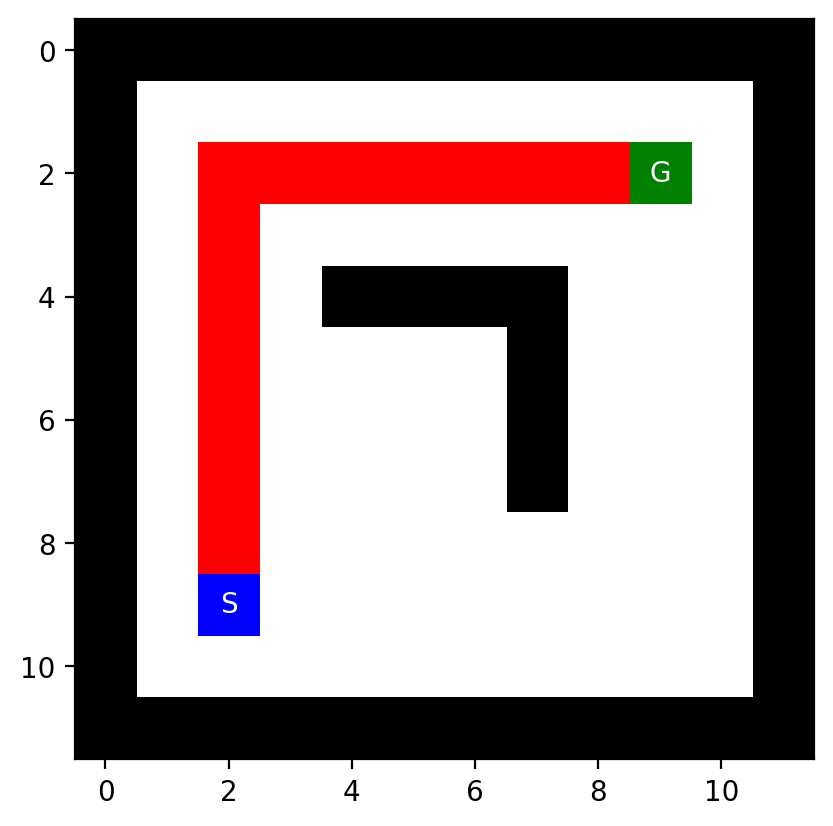

,Algorithm,Path Cost,Nodes Expanded,Max Tree Depth,Max Frontier Size,max memory usage
0,Greedy_BFS,14,14,14,71,106


In [28]:

class Node:
    def __init__(self, pos, parent=None, action=None, cost=0,h=0):
        self.pos = tuple(pos)    # the state; positions are (row,col)
        self.parent = parent     # reference to parent node. None means root node.
        self.action = action     # action used in the transition function (root node has None)
        self.cost = cost         # for uniform cost this is the depth. It is also g(n) for A* search
        self.h = h         # for manhattan distance
    def __str__(self):
        return f"Node - pos = {self.pos}; action = {self.action}; cost = {self.cost}"

    def get_path_from_root(self):
        """returns nodes on the path from the root to the current node."""
        node = self
        path = [node]

        while not node.parent is None:
            node = node.parent
            path.append(node)
            

        path.reverse()

        return(path)
def manhattan_distance(pos, goal):
    """Calculate the Manhattan distance from current position to goal."""
    return abs(pos[0] - goal[0]) + abs(pos[1] - goal[1])

def sorting(frontier, node):
    """Insert the node into the frontier, maintaining the list sorted by heuristic h(n)."""
    inserted = False
    for i in range(len(frontier)):
        if node.h < frontier[i].h:
            frontier.insert(i, node)
            inserted = True
            break
    if not inserted:
        frontier.append(node)  # Insert at the end if not inserted earlier
            
ACTIONS = [(-1, 0, 'North'), (1, 0, 'South'), (0, -1, 'West'), (0, 1, 'East')]    
def mark_maze(maze, pos, symbol):
    """Marks the maze at a given position with a symbol."""
    maze[pos[0]][pos[1]] = symbol
    
def Greedy_BFS(maze, start, goal):
    #  Initialize the initial node and check if it's the goal
    initial_node = Node(pos=start,h=manhattan_distance(start, goal))
    if start == goal:  # Check if the initial state is the goal
        return initial_node.get_path_from_root()
    #  Initialize the frontier (FIFO queue) and reached set
    frontier = [initial_node]  # Frontier initialized with the initial node
    
    reached = set()  # reached set to track visited nodes
    reached.add(start)
    nodes_expanded = 0
    max_tree_depth = 0
    max_frontier_size = 1  # Maximum size of the frontier (starts with 1, the initial node)
    max_memory_usage = 1  # Maximum number of nodes in memory (frontier + reached)
    # Loop until we either find the goal or exhaust the frontier
    while frontier:
        
        node = frontier.pop(0)
        nodes_expanded += 1
        if mh.look(maze, node.pos)!='S':
            mark_maze(maze, node.pos, '.')
        
        
        for dx, dy, action in ACTIONS:
            next_pos = (node.pos[0] + dx, node.pos[1] + dy) #next position 
            if mh.look(maze, next_pos)!='X' and next_pos not in reached:
                reached.add(next_pos)
                
                # Create child nodes
                child = Node(next_pos, node, action, node.cost+1,h=manhattan_distance(next_pos, goal)) #child branch
                sorting(frontier, child)
                #print('child',child)
                frontier.append(child)
                max_tree_depth = max(max_tree_depth, child.cost)
                max_frontier_size = max(max_frontier_size, len(frontier))
                if mh.look(maze, next_pos)=='G':
                    solution_path = child.get_path_from_root()
                    path_cost = len(solution_path) - 1
                    for path_node in solution_path:
                        if mh.look(maze, path_node.pos)!='G' and mh.look(maze, path_node.pos)!='S':
                            mark_maze(maze, path_node.pos, 'P')
                            clear_output(wait=True)
                            mh.show_maze(maze)
                    return solution_path, path_cost, nodes_expanded, max_tree_depth, max_frontier_size,max_memory_usage
                
                
            else:
                #print('Wall')
                continue
        max_memory_usage = max(max_memory_usage, len(frontier) + len(reached))
        clear_output(wait=True)
        mh.show_maze(maze)    
    #return None
with open("wall_maze.txt", "r") as f:
    maze_str = f.read()
maze = mh.parse_maze(maze_str)
start= mh.find_pos(maze, what = "S")
goal= mh.find_pos(maze, what = "G")
print('start point is',start,'goal point is',goal)
[solution_path,GBFS_wall_path_cost,GBFS_wall_nodes_expanded,GBFS_wall_max_tree_depth, GBFS_wall_max_frontier_size,GBFS_wall_memory_usage] = Greedy_BFS(maze, start, goal)
data = {
    'Algorithm': ['Greedy_BFS'],
    'Path Cost': [GBFS_wall_path_cost],
    'Nodes Expanded': [GBFS_wall_nodes_expanded],
    'Max Tree Depth': [GBFS_wall_max_tree_depth],
    'Max Frontier Size': [GBFS_wall_max_frontier_size],
    'max memory usage':[GBFS_wall_memory_usage]
}

# Create a DataFrame
df = pd.DataFrame(data)
df

### Greedy-BFS loops maze

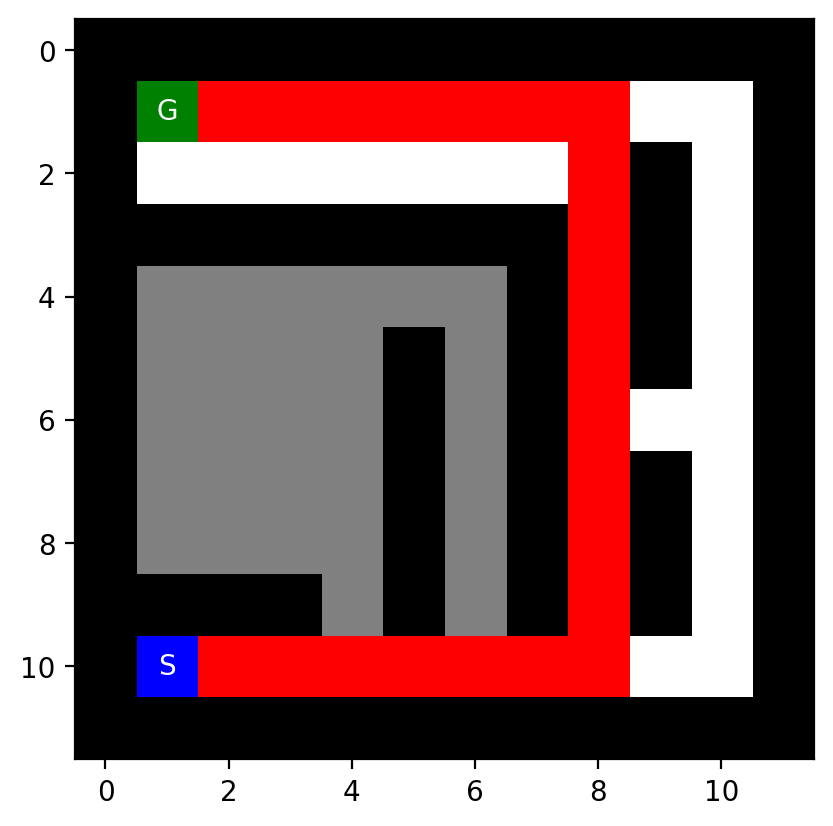

,Algorithm,Path Cost,Nodes Expanded,Max Tree Depth,Max Frontier Size,max memory usage
0,Greedy_BFS,23,85,23,36,92


In [29]:

class Node:
    def __init__(self, pos, parent=None, action=None, cost=0,h=0):
        self.pos = tuple(pos)    # the state; positions are (row,col)
        self.parent = parent     # reference to parent node. None means root node.
        self.action = action     # action used in the transition function (root node has None)
        self.cost = cost         # for uniform cost this is the depth. It is also g(n) for A* search
        self.h = h         # for manhattan distance
    def __str__(self):
        return f"Node - pos = {self.pos}; action = {self.action}; cost = {self.cost}"

    def get_path_from_root(self):
        """returns nodes on the path from the root to the current node."""
        node = self
        path = [node]

        while not node.parent is None:
            node = node.parent
            path.append(node)
            

        path.reverse()

        return(path)
def manhattan_distance(pos, goal):
    """Calculate the Manhattan distance from current position to goal."""
    return abs(pos[0] - goal[0]) + abs(pos[1] - goal[1])

def sorting(frontier, node):
    """Insert the node into the frontier, maintaining the list sorted by heuristic h(n)."""
    inserted = False
    for i in range(len(frontier)):
        if node.h < frontier[i].h:
            frontier.insert(i, node)
            inserted = True
            break
    if not inserted:
        frontier.append(node)  # Insert at the end if not inserted earlier
            
ACTIONS = [(-1, 0, 'North'), (1, 0, 'South'), (0, -1, 'West'), (0, 1, 'East')]    
def mark_maze(maze, pos, symbol):
    """Marks the maze at a given position with a symbol."""
    maze[pos[0]][pos[1]] = symbol
    
def Greedy_BFS(maze, start, goal):
    #  Initialize the initial node and check if it's the goal
    initial_node = Node(pos=start,h=manhattan_distance(start, goal))
    if start == goal:  # Check if the initial state is the goal
        return initial_node.get_path_from_root()
    #  Initialize the frontier (FIFO queue) and reached set
    frontier = [initial_node]  # Frontier initialized with the initial node
    
    reached = set()  # reached set to track visited nodes
    reached.add(start)
    nodes_expanded = 0
    max_tree_depth = 0
    max_frontier_size = 1  # Maximum size of the frontier (starts with 1, the initial node)
    max_memory_usage = 1  # Maximum number of nodes in memory (frontier + reached)
    # Loop until we either find the goal or exhaust the frontier
    while frontier:
        
        node = frontier.pop(0)
        nodes_expanded += 1
        if mh.look(maze, node.pos)!='S':
            mark_maze(maze, node.pos, '.')
        
        
        for dx, dy, action in ACTIONS:
            next_pos = (node.pos[0] + dx, node.pos[1] + dy) #next position 
            if mh.look(maze, next_pos)!='X' and next_pos not in reached:
                reached.add(next_pos)
                
                # Create child nodes
                child = Node(next_pos, node, action, node.cost+1,h=manhattan_distance(next_pos, goal)) #child branch
                sorting(frontier, child)
                #print('child',child)
                frontier.append(child)
                max_tree_depth = max(max_tree_depth, child.cost)
                max_frontier_size = max(max_frontier_size, len(frontier))
                if mh.look(maze, next_pos)=='G':
                    solution_path = child.get_path_from_root()
                    path_cost = len(solution_path) - 1
                    for path_node in solution_path:
                        if mh.look(maze, path_node.pos)!='G' and mh.look(maze, path_node.pos)!='S':
                            mark_maze(maze, path_node.pos, 'P')
                            clear_output(wait=True)
                            mh.show_maze(maze)
                    return solution_path, path_cost, nodes_expanded, max_tree_depth, max_frontier_size,max_memory_usage
                
                
            else:
                #print('Wall')
                continue
        max_memory_usage = max(max_memory_usage, len(frontier) + len(reached))
        clear_output(wait=True)
        mh.show_maze(maze)    
    #return None
with open("loops_maze.txt", "r") as f:
    maze_str = f.read()
maze = mh.parse_maze(maze_str)
start= mh.find_pos(maze, what = "S")
goal= mh.find_pos(maze, what = "G")
print('start point is',start,'goal point is',goal)
[solution_path,GBFS_loops_path_cost,GBFS_loops_nodes_expanded,GBFS_loops_max_tree_depth, GBFS_loops_max_frontier_size,GBFS_loops_memory_usage] = Greedy_BFS(maze, start, goal)
data = {
    'Algorithm': ['Greedy_BFS'],
    'Path Cost': [GBFS_loops_path_cost],
    'Nodes Expanded': [GBFS_loops_nodes_expanded],
    'Max Tree Depth': [GBFS_loops_max_tree_depth],
    'Max Frontier Size': [GBFS_loops_max_frontier_size],
    'max memory usage':[GBFS_loops_memory_usage]
}

# Create a DataFrame
df = pd.DataFrame(data)
df

### Greedy-BFS empty maze

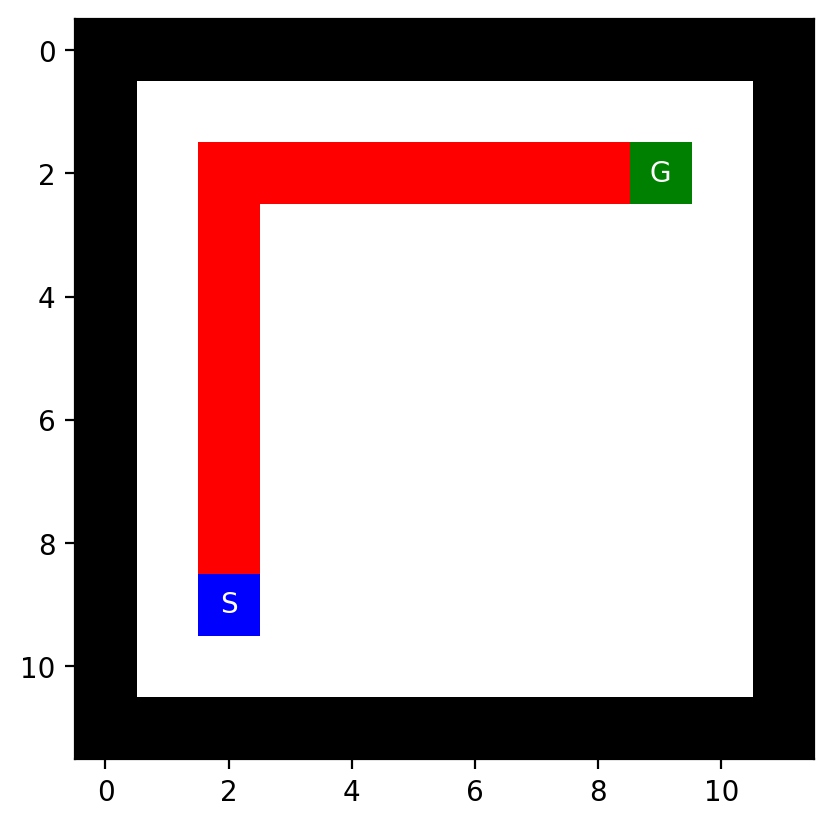

,Algorithm,Path Cost,Nodes Expanded,Max Tree Depth,Max Frontier Size,max memory usage
0,Greedy_BFS,14,14,14,71,106


In [30]:

class Node:
    def __init__(self, pos, parent=None, action=None, cost=0,h=0):
        self.pos = tuple(pos)    # the state; positions are (row,col)
        self.parent = parent     # reference to parent node. None means root node.
        self.action = action     # action used in the transition function (root node has None)
        self.cost = cost         # for uniform cost this is the depth. It is also g(n) for A* search
        self.h = h         # for manhattan distance
    def __str__(self):
        return f"Node - pos = {self.pos}; action = {self.action}; cost = {self.cost}"

    def get_path_from_root(self):
        """returns nodes on the path from the root to the current node."""
        node = self
        path = [node]

        while not node.parent is None:
            node = node.parent
            path.append(node)
            

        path.reverse()

        return(path)
def manhattan_distance(pos, goal):
    """Calculate the Manhattan distance from current position to goal."""
    return abs(pos[0] - goal[0]) + abs(pos[1] - goal[1])

def sorting(frontier, node):
    """Insert the node into the frontier, maintaining the list sorted by heuristic h(n)."""
    inserted = False
    for i in range(len(frontier)):
        if node.h < frontier[i].h:
            frontier.insert(i, node)
            inserted = True
            break
    if not inserted:
        frontier.append(node)  # Insert at the end if not inserted earlier
            
ACTIONS = [(-1, 0, 'North'), (1, 0, 'South'), (0, -1, 'West'), (0, 1, 'East')]    
def mark_maze(maze, pos, symbol):
    """Marks the maze at a given position with a symbol."""
    maze[pos[0]][pos[1]] = symbol
    
def Greedy_BFS(maze, start, goal):
    #  Initialize the initial node and check if it's the goal
    initial_node = Node(pos=start,h=manhattan_distance(start, goal))
    if start == goal:  # Check if the initial state is the goal
        return initial_node.get_path_from_root()
    #  Initialize the frontier (FIFO queue) and reached set
    frontier = [initial_node]  # Frontier initialized with the initial node
    
    reached = set()  # reached set to track visited nodes
    reached.add(start)
    nodes_expanded = 0
    max_tree_depth = 0
    max_frontier_size = 1  # Maximum size of the frontier (starts with 1, the initial node)
    max_memory_usage = 1  # Maximum number of nodes in memory (frontier + reached)
    # Loop until we either find the goal or exhaust the frontier
    while frontier:
        
        node = frontier.pop(0)
        nodes_expanded += 1
        if mh.look(maze, node.pos)!='S':
            mark_maze(maze, node.pos, '.')
        
        
        for dx, dy, action in ACTIONS:
            next_pos = (node.pos[0] + dx, node.pos[1] + dy) #next position 
            if mh.look(maze, next_pos)!='X' and next_pos not in reached:
                reached.add(next_pos)
                
                # Create child nodes
                child = Node(next_pos, node, action, node.cost+1,h=manhattan_distance(next_pos, goal)) #child branch
                sorting(frontier, child)
                #print('child',child)
                frontier.append(child)
                max_tree_depth = max(max_tree_depth, child.cost)
                max_frontier_size = max(max_frontier_size, len(frontier))
                if mh.look(maze, next_pos)=='G':
                    solution_path = child.get_path_from_root()
                    path_cost = len(solution_path) - 1
                    for path_node in solution_path:
                        if mh.look(maze, path_node.pos)!='G' and mh.look(maze, path_node.pos)!='S':
                            mark_maze(maze, path_node.pos, 'P')
                            clear_output(wait=True)
                            mh.show_maze(maze)
                    return solution_path, path_cost, nodes_expanded, max_tree_depth, max_frontier_size,max_memory_usage
                
                
            else:
                #print('Wall')
                continue
        max_memory_usage = max(max_memory_usage, len(frontier) + len(reached))
        clear_output(wait=True)
        mh.show_maze(maze)     
    #return None
with open("empty_maze.txt", "r") as f:
    maze_str = f.read()
maze = mh.parse_maze(maze_str)
start= mh.find_pos(maze, what = "S")
goal= mh.find_pos(maze, what = "G")
print('start point is',start,'goal point is',goal)
[solution_path,GBFS_empty_path_cost,GBFS_empty_nodes_expanded,GBFS_empty_max_tree_depth, GBFS_empty_max_frontier_size,GBFS_empty_memory_usage] = Greedy_BFS(maze, start, goal)
data = {
    'Algorithm': ['Greedy_BFS'],
    'Path Cost': [GBFS_empty_path_cost],
    'Nodes Expanded': [GBFS_empty_nodes_expanded],
    'Max Tree Depth': [GBFS_empty_max_tree_depth],
    'Max Frontier Size': [GBFS_empty_max_frontier_size],
    'max memory usage':[GBFS_empty_memory_usage]
}

# Create a DataFrame
df = pd.DataFrame(data)
df

### Greedy-BFS empty_2 maze

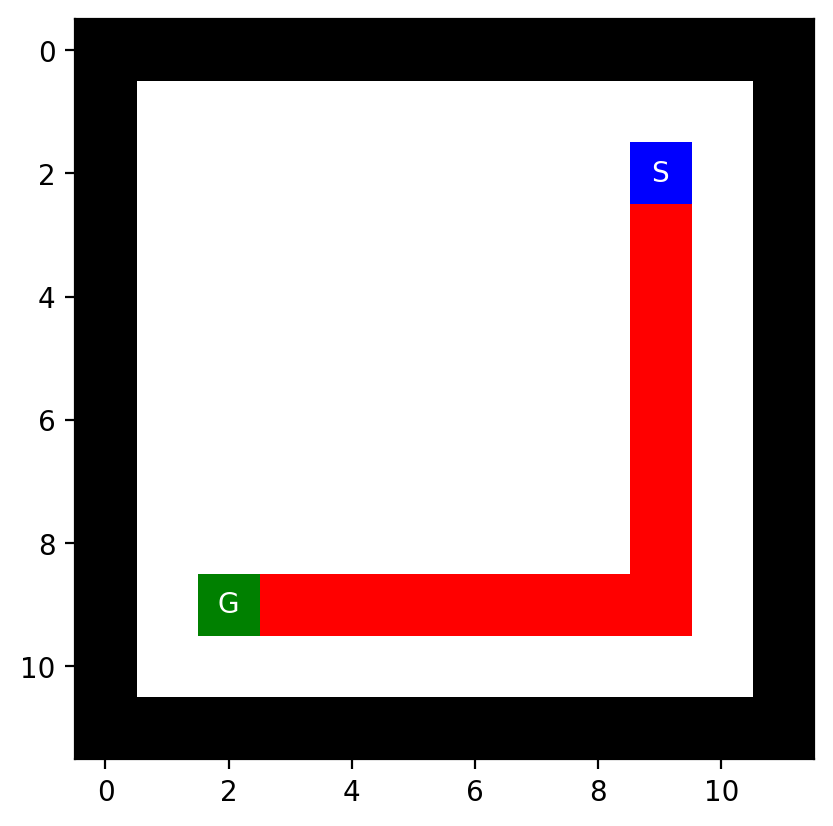

,Algorithm,Path Cost,Nodes Expanded,Max Tree Depth,Max Frontier Size,max memory usage
0,Greedy_BFS,14,14,14,71,106


In [31]:

class Node:
    def __init__(self, pos, parent=None, action=None, cost=0,h=0):
        self.pos = tuple(pos)    # the state; positions are (row,col)
        self.parent = parent     # reference to parent node. None means root node.
        self.action = action     # action used in the transition function (root node has None)
        self.cost = cost         # for uniform cost this is the depth. It is also g(n) for A* search
        self.h = h         # for manhattan distance
    def __str__(self):
        return f"Node - pos = {self.pos}; action = {self.action}; cost = {self.cost}"

    def get_path_from_root(self):
        """returns nodes on the path from the root to the current node."""
        node = self
        path = [node]

        while not node.parent is None:
            node = node.parent
            path.append(node)
            

        path.reverse()

        return(path)
def manhattan_distance(pos, goal):
    """Calculate the Manhattan distance from current position to goal."""
    return abs(pos[0] - goal[0]) + abs(pos[1] - goal[1])

def sorting(frontier, node):
    """Insert the node into the frontier, maintaining the list sorted by heuristic h(n)."""
    inserted = False
    for i in range(len(frontier)):
        if node.h < frontier[i].h:
            frontier.insert(i, node)
            inserted = True
            break
    if not inserted:
        frontier.append(node)  # Insert at the end if not inserted earlier
            
ACTIONS = [(-1, 0, 'North'), (1, 0, 'South'), (0, -1, 'West'), (0, 1, 'East')]    
def mark_maze(maze, pos, symbol):
    """Marks the maze at a given position with a symbol."""
    maze[pos[0]][pos[1]] = symbol
    
def Greedy_BFS(maze, start, goal):
    #  Initialize the initial node and check if it's the goal
    initial_node = Node(pos=start,h=manhattan_distance(start, goal))
    if start == goal:  # Check if the initial state is the goal
        return initial_node.get_path_from_root()
    #  Initialize the frontier (FIFO queue) and reached set
    frontier = [initial_node]  # Frontier initialized with the initial node
    
    reached = set()  # reached set to track visited nodes
    reached.add(start)
    nodes_expanded = 0
    max_tree_depth = 0
    max_frontier_size = 1  # Maximum size of the frontier (starts with 1, the initial node)
    max_memory_usage = 1  # Maximum number of nodes in memory (frontier + reached)
    # Loop until we either find the goal or exhaust the frontier
    while frontier:
        
        node = frontier.pop(0)
        nodes_expanded += 1
        if mh.look(maze, node.pos)!='S':
            mark_maze(maze, node.pos, '.')
        
        
        for dx, dy, action in ACTIONS:
            next_pos = (node.pos[0] + dx, node.pos[1] + dy) #next position 
            if mh.look(maze, next_pos)!='X' and next_pos not in reached:
                reached.add(next_pos)
                
                # Create child nodes
                child = Node(next_pos, node, action, node.cost+1,h=manhattan_distance(next_pos, goal)) #child branch
                sorting(frontier, child)
                #print('child',child)
                frontier.append(child)
                max_tree_depth = max(max_tree_depth, child.cost)
                max_frontier_size = max(max_frontier_size, len(frontier))
                if mh.look(maze, next_pos)=='G':
                    solution_path = child.get_path_from_root()
                    path_cost = len(solution_path) - 1
                    for path_node in solution_path:
                        if mh.look(maze, path_node.pos)!='G' and mh.look(maze, path_node.pos)!='S':
                            mark_maze(maze, path_node.pos, 'P')
                            clear_output(wait=True)
                            mh.show_maze(maze)
                    return solution_path, path_cost, nodes_expanded, max_tree_depth, max_frontier_size,max_memory_usage
                
                
            else:
                #print('Wall')
                continue
        max_memory_usage = max(max_memory_usage, len(frontier) + len(reached))
        clear_output(wait=True)
        mh.show_maze(maze)     
    #return None
with open("empty_2_maze.txt", "r") as f:
    maze_str = f.read()
maze = mh.parse_maze(maze_str)
start= mh.find_pos(maze, what = "S")
goal= mh.find_pos(maze, what = "G")
print('start point is',start,'goal point is',goal)
[solution_path,GBFS_empty_2_path_cost,GBFS_empty_2_nodes_expanded,GBFS_empty_2_max_tree_depth, GBFS_empty_2_max_frontier_size,GBFS_empty_2_memory_usage] = Greedy_BFS(maze, start, goal)
data = {
    'Algorithm': ['Greedy_BFS'],
    'Path Cost': [GBFS_empty_2_path_cost],
    'Nodes Expanded': [GBFS_empty_2_nodes_expanded],
    'Max Tree Depth': [GBFS_empty_2_max_tree_depth],
    'Max Frontier Size': [GBFS_empty_2_max_frontier_size],
    'max memory usage':[GBFS_empty_2_memory_usage]
}

# Create a DataFrame
df = pd.DataFrame(data)
df

### Greedy-BFS open maze

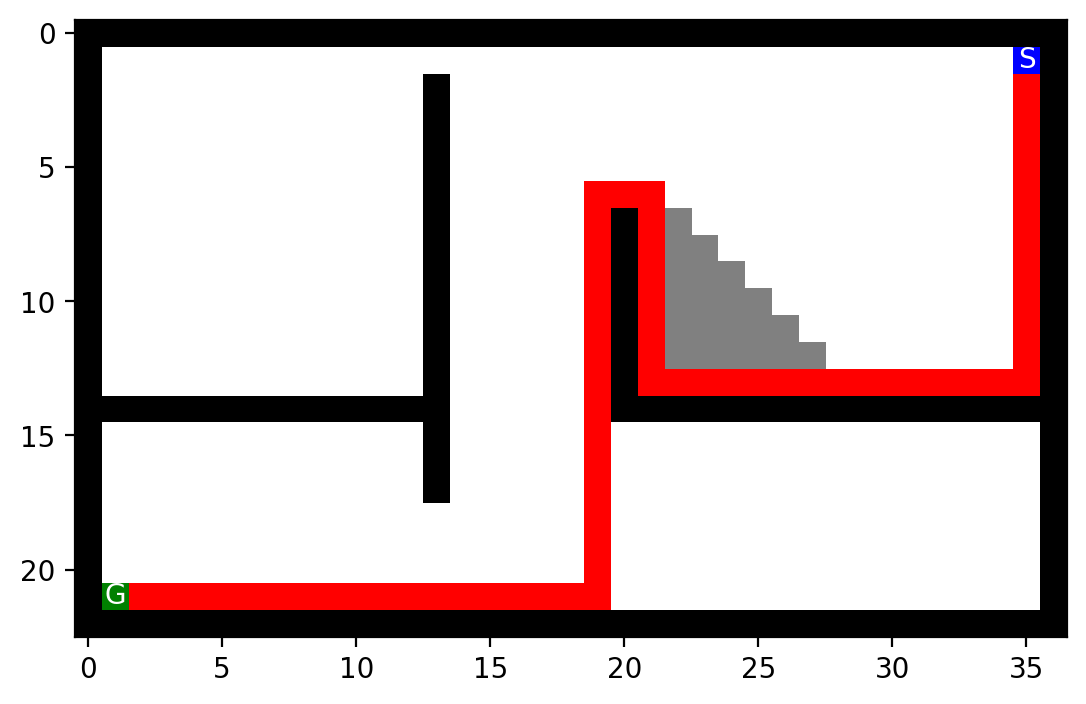

,Algorithm,Path Cost,Nodes Expanded,Max Tree Depth,Max Frontier Size,max memory usage
0,Greedy_BFS,68,89,68,220,370


In [32]:

class Node:
    def __init__(self, pos, parent=None, action=None, cost=0,h=0):
        self.pos = tuple(pos)    # the state; positions are (row,col)
        self.parent = parent     # reference to parent node. None means root node.
        self.action = action     # action used in the transition function (root node has None)
        self.cost = cost         # for uniform cost this is the depth. It is also g(n) for A* search
        self.h = h         # for manhattan distance
    def __str__(self):
        return f"Node - pos = {self.pos}; action = {self.action}; cost = {self.cost}"

    def get_path_from_root(self):
        """returns nodes on the path from the root to the current node."""
        node = self
        path = [node]

        while not node.parent is None:
            node = node.parent
            path.append(node)
            

        path.reverse()

        return(path)
def manhattan_distance(pos, goal):
    """Calculate the Manhattan distance from current position to goal."""
    return abs(pos[0] - goal[0]) + abs(pos[1] - goal[1])

def sorting(frontier, node):
    """Insert the node into the frontier, maintaining the list sorted by heuristic h(n)."""
    inserted = False
    for i in range(len(frontier)):
        if node.h < frontier[i].h:
            frontier.insert(i, node)
            inserted = True
            break
    if not inserted:
        frontier.append(node)  # Insert at the end if not inserted earlier
            
ACTIONS = [(-1, 0, 'North'), (1, 0, 'South'), (0, -1, 'West'), (0, 1, 'East')]    
def mark_maze(maze, pos, symbol):
    """Marks the maze at a given position with a symbol."""
    maze[pos[0]][pos[1]] = symbol
    
def Greedy_BFS(maze, start, goal):
    #  Initialize the initial node and check if it's the goal
    initial_node = Node(pos=start,h=manhattan_distance(start, goal))
    if start == goal:  # Check if the initial state is the goal
        return initial_node.get_path_from_root()
    #  Initialize the frontier (FIFO queue) and reached set
    frontier = [initial_node]  # Frontier initialized with the initial node
    
    reached = set()  # reached set to track visited nodes
    reached.add(start)
    nodes_expanded = 0
    max_tree_depth = 0
    max_frontier_size = 1  # Maximum size of the frontier (starts with 1, the initial node)
    max_memory_usage = 1  # Maximum number of nodes in memory (frontier + reached)
    # Loop until we either find the goal or exhaust the frontier
    while frontier:
        
        node = frontier.pop(0)
        nodes_expanded += 1
        if mh.look(maze, node.pos)!='S':
            mark_maze(maze, node.pos, '.')
        
        
        for dx, dy, action in ACTIONS:
            next_pos = (node.pos[0] + dx, node.pos[1] + dy) #next position 
            if mh.look(maze, next_pos)!='X' and next_pos not in reached:
                reached.add(next_pos)
                
                # Create child nodes
                child = Node(next_pos, node, action, node.cost+1,h=manhattan_distance(next_pos, goal)) #child branch
                sorting(frontier, child)
                #print('child',child)
                frontier.append(child)
                max_tree_depth = max(max_tree_depth, child.cost)
                max_frontier_size = max(max_frontier_size, len(frontier))
                if mh.look(maze, next_pos)=='G':
                    solution_path = child.get_path_from_root()
                    path_cost = len(solution_path) - 1
                    for path_node in solution_path:
                        if mh.look(maze, path_node.pos)!='G' and mh.look(maze, path_node.pos)!='S':
                            mark_maze(maze, path_node.pos, 'P')
                            clear_output(wait=True)
                            mh.show_maze(maze)
                    return solution_path, path_cost, nodes_expanded, max_tree_depth, max_frontier_size,max_memory_usage

                
                
            else:
                #print('Wall')
                continue
        max_memory_usage = max(max_memory_usage, len(frontier) + len(reached))
        clear_output(wait=True)
        mh.show_maze(maze)     
    #return None
with open("open_maze.txt", "r") as f:
    maze_str = f.read()
maze = mh.parse_maze(maze_str)
start= mh.find_pos(maze, what = "S")
goal= mh.find_pos(maze, what = "G")
print('start point is',start,'goal point is',goal)
[solution_path,GBFS_open_path_cost,GBFS_open_nodes_expanded,GBFS_open_max_tree_depth, GBFS_open_max_frontier_size,GBFS_open_memory_usage] = Greedy_BFS(maze, start, goal)
data = {
    'Algorithm': ['Greedy_BFS'],
    'Path Cost': [GBFS_open_path_cost],
    'Nodes Expanded': [GBFS_open_nodes_expanded],
    'Max Tree Depth': [GBFS_open_max_tree_depth],
    'Max Frontier Size': [GBFS_open_max_frontier_size],
    'max memory usage':[GBFS_open_memory_usage]
}

# Create a DataFrame
df = pd.DataFrame(data)
df

### A* search BFS small maze

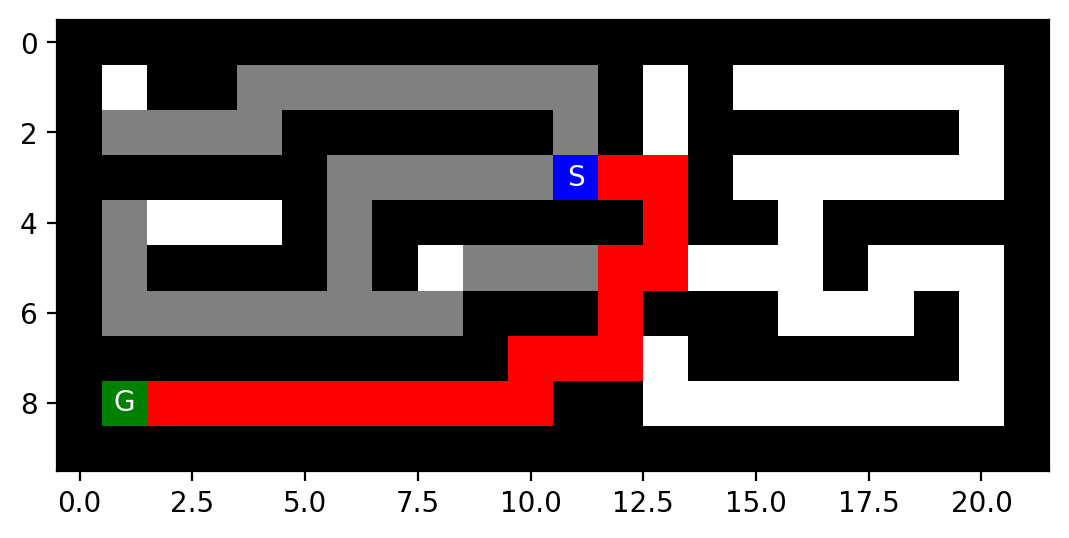

,Algorithm,Path Cost,Nodes Expanded,Max Tree Depth,Max Frontier Size,max memory usage
0,A_BFS,19,52,19,8,65


In [33]:
class Node:
    def __init__(self, pos, parent=None, action=None, cost=0, h=0):
        self.pos = tuple(pos)    # the state; positions are (row, col)
        self.parent = parent     # reference to parent node. None means root node.
        self.action = action     # action used in the transition function (root node has None)
        self.cost = cost         # for uniform cost this is the depth. It is also g(n) for A* search
        self.h = h               # for Manhattan distance
        self.f = self.cost + self.h  # f(n) = g(n) + h(n), A* search uses this
        
    def __str__(self):
        return f"Node - pos = {self.pos}; action = {self.action}; cost = {self.cost}"

    def get_path_from_root(self):
        """Returns nodes on the path from the root to the current node."""
        node = self
        path = [node]

        while node.parent is not None:
            node = node.parent
            path.append(node)

        path.reverse()
        return path

def manhattan_distance(pos, goal):
    """Calculate the Manhattan distance from current position to goal."""
    return abs(pos[0] - goal[0]) + abs(pos[1] - goal[1])

def sorting(frontier, node):
    """Insert the node into the frontier, maintaining the list sorted by heuristic h(n)."""
    inserted = False
    for i in range(len(frontier)):
        if node.f < frontier[i].f:
            frontier.insert(i, node)
            inserted = True
            break
    if not inserted:
        frontier.append(node)  # Insert at the end if not inserted earlier
            
ACTIONS = [(-1, 0, 'North'), (1, 0, 'South'), (0, -1, 'West'), (0, 1, 'East')]    

def mark_maze(maze, pos, symbol):
    """Marks the maze at a given position with a symbol."""
    maze[pos[0]][pos[1]] = symbol

def A_BFS(maze, start, goal):
    # Initialize the initial node and check if it's the goal
    initial_node = Node(pos=start, h=manhattan_distance(start, goal))
    if start == goal:  # Check if the initial state is the goal
        return initial_node.get_path_from_root(), 0, 0, 0, 0

    
    # Initialize the frontier (FIFO queue) and reached set
    frontier = [initial_node]  # Frontier initialized with the initial node
    reached = set()  # Reached set to track visited nodes
    reached.add(start)
    nodes_expanded = 0  # Total number of nodes expanded
    max_tree_depth = 0  # Maximum depth of the search tree
    max_frontier_size = 1  # Maximum size of the frontier (starts with 1, the initial node)
    max_memory_usage = 1  # Maximum number of nodes in memory (frontier + reached)
    while frontier:
        
        node = frontier.pop(0)
        nodes_expanded += 1  # Count this node as expanded
        if maze[node.pos[0]][node.pos[1]] != 'S':
            mark_maze(maze, node.pos, '.')

        # Explore neighboring nodes (possible actions)
        for dx, dy, action in ACTIONS:
            next_pos = (node.pos[0] + dx, node.pos[1] + dy)  # Next position
            if maze[next_pos[0]][next_pos[1]] != 'X' and next_pos not in reached:
                reached.add(next_pos)
                
                # Create child nodes
                child = Node(next_pos, node, action, node.cost + 1, h=manhattan_distance(next_pos, goal))  # Child branch
                sorting(frontier, child)
                max_tree_depth = max(max_tree_depth, child.cost)
                max_frontier_size = max(max_frontier_size, len(frontier))
                
                if maze[next_pos[0]][next_pos[1]] == 'G':
                    solution_path = child.get_path_from_root()
                    path_cost = len(solution_path) - 1
                    for path_node in solution_path:
                        if maze[path_node.pos[0]][path_node.pos[1]] not in ['G', 'S']:
                            mark_maze(maze, path_node.pos, 'P')
                            clear_output(wait=True)
                            mh.show_maze(maze)
                    return solution_path, path_cost, nodes_expanded, max_tree_depth, max_frontier_size,max_memory_usage


        max_memory_usage = max(max_memory_usage, len(frontier) + len(reached))
        clear_output(wait=True)
        mh.show_maze(maze)
    
    return None
with open("small_maze.txt", "r") as f:
    maze_str = f.read()
maze = mh.parse_maze(maze_str)
start= mh.find_pos(maze, what = "S")
goal= mh.find_pos(maze, what = "G")
print('start point is',start,'goal point is',goal)


[solution_path,ABFS_small_path_cost,ABFS_small_nodes_expanded,ABFS_small_max_tree_depth, ABFS_small_max_frontier_size,ABFS_small_memory_usage] =  A_BFS(maze, start, goal)
data = {
    'Algorithm': ['A_BFS'],
    'Path Cost': [ABFS_small_path_cost],
    'Nodes Expanded': [ABFS_small_nodes_expanded],
    'Max Tree Depth': [ABFS_small_max_tree_depth],
    'Max Frontier Size': [ABFS_small_max_frontier_size],
    'max memory usage':[ABFS_small_memory_usage]
}

# Create a DataFrame
df = pd.DataFrame(data)
df

### A* search BFS medium maze

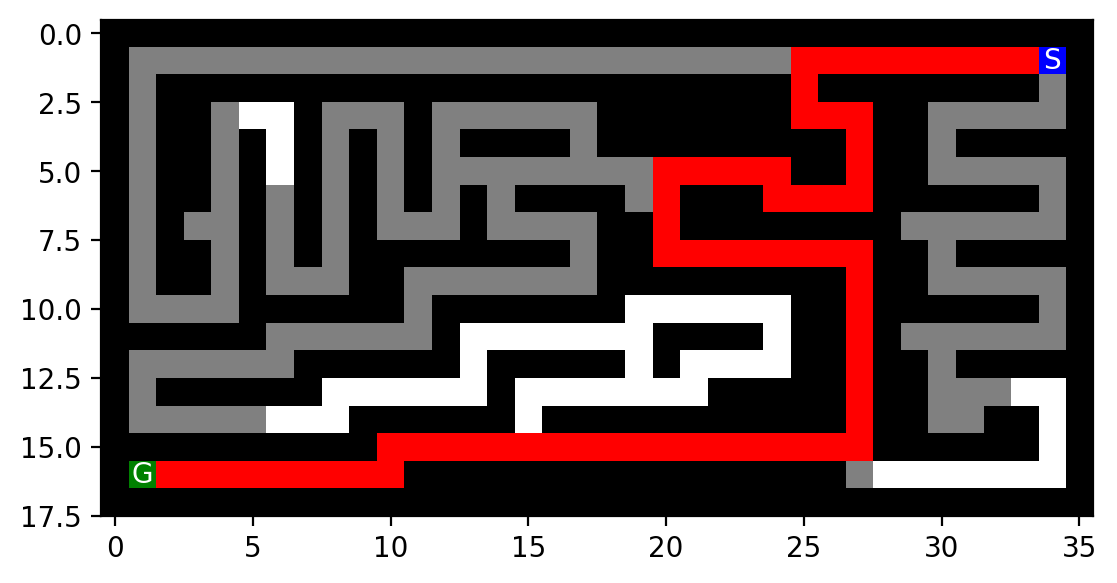

,Algorithm,Path Cost,Nodes Expanded,Max Tree Depth,Max Frontier Size,max memory usage
0,A_BFS,68,221,68,8,234


In [34]:
class Node:
    def __init__(self, pos, parent=None, action=None, cost=0, h=0):
        self.pos = tuple(pos)    # the state; positions are (row, col)
        self.parent = parent     # reference to parent node. None means root node.
        self.action = action     # action used in the transition function (root node has None)
        self.cost = cost         # for uniform cost this is the depth. It is also g(n) for A* search
        self.h = h               # for Manhattan distance
        self.f = self.cost + self.h  # f(n) = g(n) + h(n), A* search uses this
        
    def __str__(self):
        return f"Node - pos = {self.pos}; action = {self.action}; cost = {self.cost}"

    def get_path_from_root(self):
        """Returns nodes on the path from the root to the current node."""
        node = self
        path = [node]

        while node.parent is not None:
            node = node.parent
            path.append(node)

        path.reverse()
        return path

def manhattan_distance(pos, goal):
    """Calculate the Manhattan distance from current position to goal."""
    return abs(pos[0] - goal[0]) + abs(pos[1] - goal[1])

def sorting(frontier, node):
    """Insert the node into the frontier, maintaining the list sorted by heuristic h(n)."""
    inserted = False
    for i in range(len(frontier)):
        if node.f < frontier[i].f:
            frontier.insert(i, node)
            inserted = True
            break
    if not inserted:
        frontier.append(node)  # Insert at the end if not inserted earlier
            
ACTIONS = [(-1, 0, 'North'), (1, 0, 'South'), (0, -1, 'West'), (0, 1, 'East')]    

def mark_maze(maze, pos, symbol):
    """Marks the maze at a given position with a symbol."""
    maze[pos[0]][pos[1]] = symbol

def A_BFS(maze, start, goal):
    # Initialize the initial node and check if it's the goal
    initial_node = Node(pos=start, h=manhattan_distance(start, goal))
    if start == goal:  # Check if the initial state is the goal
        return initial_node.get_path_from_root(), 0, 0, 0, 0

    
    # Initialize the frontier (FIFO queue) and reached set
    frontier = [initial_node]  # Frontier initialized with the initial node
    reached = set()  # Reached set to track visited nodes
    reached.add(start)
    nodes_expanded = 0  # Total number of nodes expanded
    max_tree_depth = 0  # Maximum depth of the search tree
    max_frontier_size = 1  # Maximum size of the frontier (starts with 1, the initial node)
    max_memory_usage = 1  # Maximum number of nodes in memory (frontier + reached)
    while frontier:
        
        node = frontier.pop(0)
        nodes_expanded += 1  # Count this node as expanded
        if maze[node.pos[0]][node.pos[1]] != 'S':
            mark_maze(maze, node.pos, '.')

        # Explore neighboring nodes (possible actions)
        for dx, dy, action in ACTIONS:
            next_pos = (node.pos[0] + dx, node.pos[1] + dy)  # Next position
            if maze[next_pos[0]][next_pos[1]] != 'X' and next_pos not in reached:
                reached.add(next_pos)
                
                # Create child nodes
                child = Node(next_pos, node, action, node.cost + 1, h=manhattan_distance(next_pos, goal))  # Child branch
                sorting(frontier, child)
                max_tree_depth = max(max_tree_depth, child.cost)
                max_frontier_size = max(max_frontier_size, len(frontier))
                
                if maze[next_pos[0]][next_pos[1]] == 'G':
                    solution_path = child.get_path_from_root()
                    path_cost = len(solution_path) - 1
                    for path_node in solution_path:
                        if maze[path_node.pos[0]][path_node.pos[1]] not in ['G', 'S']:
                            mark_maze(maze, path_node.pos, 'P')
                            clear_output(wait=True)
                            mh.show_maze(maze)
                    return solution_path, path_cost, nodes_expanded, max_tree_depth, max_frontier_size,max_memory_usage


        max_memory_usage = max(max_memory_usage, len(frontier) + len(reached))
        clear_output(wait=True)
        mh.show_maze(maze)
    
    return None
with open("medium_maze.txt", "r") as f:
    maze_str = f.read()
maze = mh.parse_maze(maze_str)
start= mh.find_pos(maze, what = "S")
goal= mh.find_pos(maze, what = "G")
print('start point is',start,'goal point is',goal)


[solution_path,ABFS_medium_path_cost,ABFS_medium_nodes_expanded,ABFS_medium_max_tree_depth, ABFS_medium_max_frontier_size,ABFS_medium_memory_usage] =  A_BFS(maze, start, goal)
data = {
    'Algorithm': ['A_BFS'],
    'Path Cost': [ABFS_medium_path_cost],
    'Nodes Expanded': [ABFS_medium_nodes_expanded],
    'Max Tree Depth': [ABFS_medium_max_tree_depth],
    'Max Frontier Size': [ABFS_medium_max_frontier_size],
    'max memory usage':[ABFS_medium_memory_usage]
}

# Create a DataFrame
df = pd.DataFrame(data)
df

### A* search BFS large maze

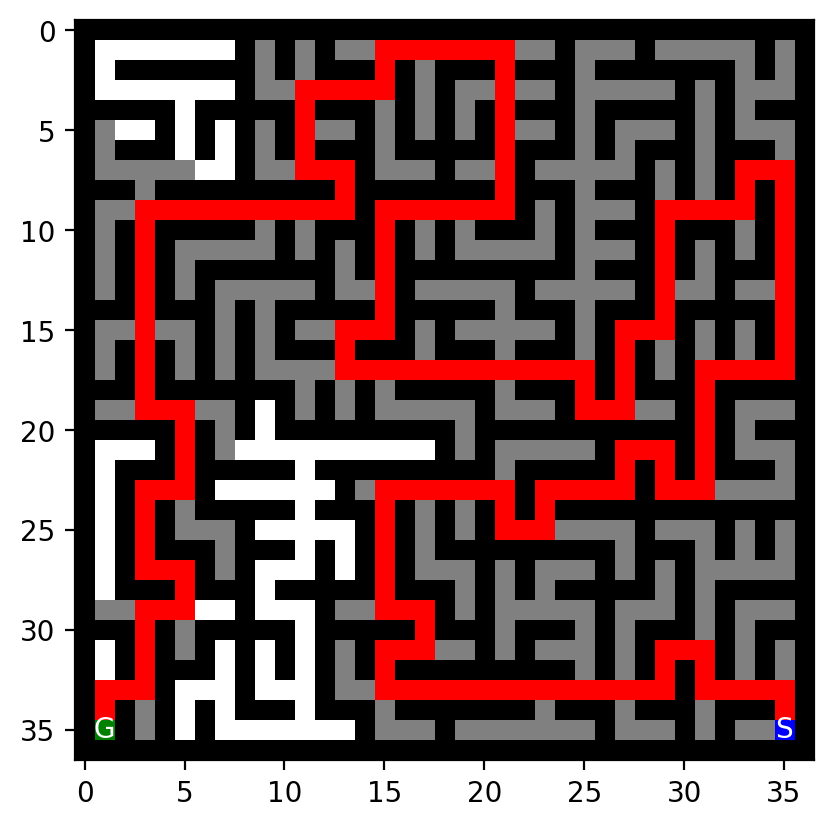

,Algorithm,Path Cost,Nodes Expanded,Max Tree Depth,Max Frontier Size,max memory usage
0,A_BFS,210,549,210,12,564


In [35]:
class Node:
    def __init__(self, pos, parent=None, action=None, cost=0, h=0):
        self.pos = tuple(pos)    # the state; positions are (row, col)
        self.parent = parent     # reference to parent node. None means root node.
        self.action = action     # action used in the transition function (root node has None)
        self.cost = cost         # for uniform cost this is the depth. It is also g(n) for A* search
        self.h = h               # for Manhattan distance
        self.f = self.cost + self.h  # f(n) = g(n) + h(n), A* search uses this
        
    def __str__(self):
        return f"Node - pos = {self.pos}; action = {self.action}; cost = {self.cost}"

    def get_path_from_root(self):
        """Returns nodes on the path from the root to the current node."""
        node = self
        path = [node]

        while node.parent is not None:
            node = node.parent
            path.append(node)

        path.reverse()
        return path

def manhattan_distance(pos, goal):
    """Calculate the Manhattan distance from current position to goal."""
    return abs(pos[0] - goal[0]) + abs(pos[1] - goal[1])

def sorting(frontier, node):
    """Insert the node into the frontier, maintaining the list sorted by heuristic h(n)."""
    inserted = False
    for i in range(len(frontier)):
        if node.f < frontier[i].f:
            frontier.insert(i, node)
            inserted = True
            break
    if not inserted:
        frontier.append(node)  # Insert at the end if not inserted earlier
            
ACTIONS = [(-1, 0, 'North'), (1, 0, 'South'), (0, -1, 'West'), (0, 1, 'East')]    

def mark_maze(maze, pos, symbol):
    """Marks the maze at a given position with a symbol."""
    maze[pos[0]][pos[1]] = symbol

def A_BFS(maze, start, goal):
    # Initialize the initial node and check if it's the goal
    initial_node = Node(pos=start, h=manhattan_distance(start, goal))
    if start == goal:  # Check if the initial state is the goal
        return initial_node.get_path_from_root(), 0, 0, 0, 0

    
    # Initialize the frontier (FIFO queue) and reached set
    frontier = [initial_node]  # Frontier initialized with the initial node
    reached = set()  # Reached set to track visited nodes
    reached.add(start)
    nodes_expanded = 0  # Total number of nodes expanded
    max_tree_depth = 0  # Maximum depth of the search tree
    max_frontier_size = 1  # Maximum size of the frontier (starts with 1, the initial node)
    max_memory_usage = 1  # Maximum number of nodes in memory (frontier + reached)
    # Loop until we either find the goal or exhaust the frontier
    while frontier:
        
        node = frontier.pop(0)
        nodes_expanded += 1  # Count this node as expanded
        if maze[node.pos[0]][node.pos[1]] != 'S':
            mark_maze(maze, node.pos, '.')

        # Explore neighboring nodes (possible actions)
        for dx, dy, action in ACTIONS:
            next_pos = (node.pos[0] + dx, node.pos[1] + dy)  # Next position
            if maze[next_pos[0]][next_pos[1]] != 'X' and next_pos not in reached:
                reached.add(next_pos)
                
                # Create child nodes
                child = Node(next_pos, node, action, node.cost + 1, h=manhattan_distance(next_pos, goal))  # Child branch
                sorting(frontier, child)
                max_tree_depth = max(max_tree_depth, child.cost)
                max_frontier_size = max(max_frontier_size, len(frontier))
                
                if maze[next_pos[0]][next_pos[1]] == 'G':
                    solution_path = child.get_path_from_root()
                    path_cost = len(solution_path) - 1
                    for path_node in solution_path:
                        if maze[path_node.pos[0]][path_node.pos[1]] not in ['G', 'S']:
                            mark_maze(maze, path_node.pos, 'P')
                            clear_output(wait=True)
                            mh.show_maze(maze)
                    return solution_path, path_cost, nodes_expanded, max_tree_depth, max_frontier_size,max_memory_usage


        max_memory_usage = max(max_memory_usage, len(frontier) + len(reached))
        clear_output(wait=True)
        mh.show_maze(maze)
    
    return None
with open("large_maze.txt", "r") as f:
    maze_str = f.read()
maze = mh.parse_maze(maze_str)
start= mh.find_pos(maze, what = "S")
goal= mh.find_pos(maze, what = "G")
print('start point is',start,'goal point is',goal)


[solution_path,ABFS_large_path_cost,ABFS_large_nodes_expanded,ABFS_large_max_tree_depth, ABFS_large_max_frontier_size,ABFS_large_memory_usage] =  A_BFS(maze, start, goal)
data = {
    'Algorithm': ['A_BFS'],
    'Path Cost': [ABFS_large_path_cost],
    'Nodes Expanded': [ABFS_large_nodes_expanded],
    'Max Tree Depth': [ABFS_large_max_tree_depth],
    'Max Frontier Size': [ABFS_large_max_frontier_size],
    'max memory usage':[ABFS_large_memory_usage]
}

# Create a DataFrame
df = pd.DataFrame(data)
df

### A* search BFS wall maze

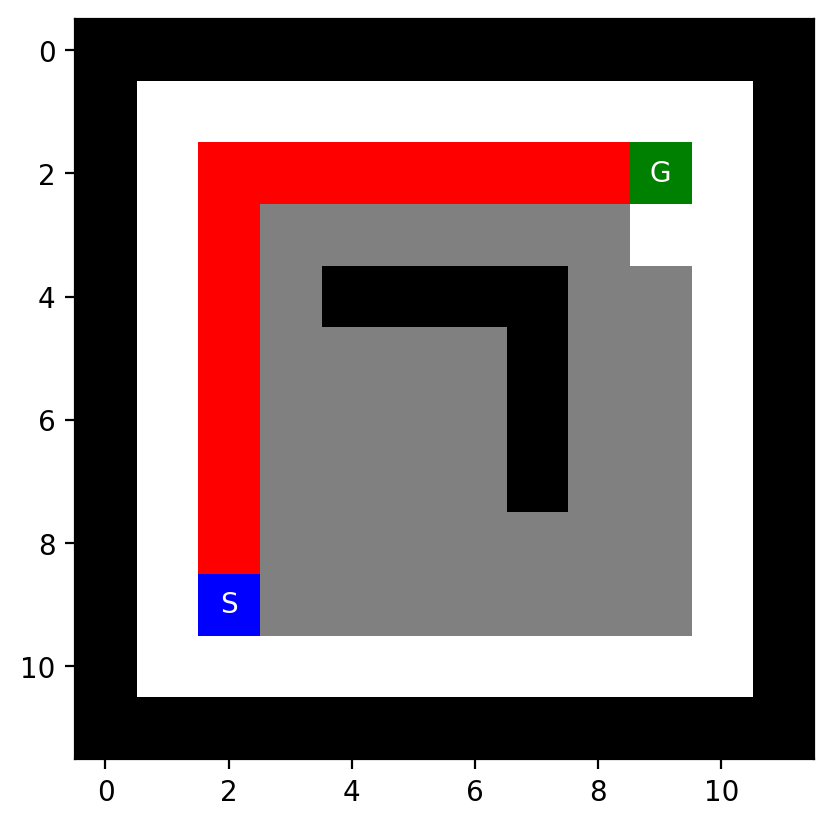

,Algorithm,Path Cost,Nodes Expanded,Max Tree Depth,Max Frontier Size,max memory usage
0,A_BFS,14,55,14,31,114


In [36]:
class Node:
    def __init__(self, pos, parent=None, action=None, cost=0, h=0):
        self.pos = tuple(pos)    # the state; positions are (row, col)
        self.parent = parent     # reference to parent node. None means root node.
        self.action = action     # action used in the transition function (root node has None)
        self.cost = cost         # for uniform cost this is the depth. It is also g(n) for A* search
        self.h = h               # for Manhattan distance
        self.f = self.cost + self.h  # f(n) = g(n) + h(n), A* search uses this
        
    def __str__(self):
        return f"Node - pos = {self.pos}; action = {self.action}; cost = {self.cost}"

    def get_path_from_root(self):
        """Returns nodes on the path from the root to the current node."""
        node = self
        path = [node]

        while node.parent is not None:
            node = node.parent
            path.append(node)

        path.reverse()
        return path

def manhattan_distance(pos, goal):
    """Calculate the Manhattan distance from current position to goal."""
    return abs(pos[0] - goal[0]) + abs(pos[1] - goal[1])

def sorting(frontier, node):
    """Insert the node into the frontier, maintaining the list sorted by heuristic h(n)."""
    inserted = False
    for i in range(len(frontier)):
        if node.f < frontier[i].f:
            frontier.insert(i, node)
            inserted = True
            break
    if not inserted:
        frontier.append(node)  # Insert at the end if not inserted earlier
            
ACTIONS = [(-1, 0, 'North'), (1, 0, 'South'), (0, -1, 'West'), (0, 1, 'East')]    

def mark_maze(maze, pos, symbol):
    """Marks the maze at a given position with a symbol."""
    maze[pos[0]][pos[1]] = symbol

def A_BFS(maze, start, goal):
    # Initialize the initial node and check if it's the goal
    initial_node = Node(pos=start, h=manhattan_distance(start, goal))
    if start == goal:  # Check if the initial state is the goal
        return initial_node.get_path_from_root(), 0, 0, 0, 0

    
    # Initialize the frontier (FIFO queue) and reached set
    frontier = [initial_node]  # Frontier initialized with the initial node
    reached = set()  # Reached set to track visited nodes
    reached.add(start)
    nodes_expanded = 0  # Total number of nodes expanded
    max_tree_depth = 0  # Maximum depth of the search tree
    max_frontier_size = 1  # Maximum size of the frontier (starts with 1, the initial node)
    max_memory_usage = 1  # Maximum number of nodes in memory (frontier + reached)
    # Loop until we either find the goal or exhaust the frontier
    while frontier:
        
        node = frontier.pop(0)
        nodes_expanded += 1  # Count this node as expanded
        if maze[node.pos[0]][node.pos[1]] != 'S':
            mark_maze(maze, node.pos, '.')

        # Explore neighboring nodes (possible actions)
        for dx, dy, action in ACTIONS:
            next_pos = (node.pos[0] + dx, node.pos[1] + dy)  # Next position
            if maze[next_pos[0]][next_pos[1]] != 'X' and next_pos not in reached:
                reached.add(next_pos)
                
                # Create child nodes
                child = Node(next_pos, node, action, node.cost + 1, h=manhattan_distance(next_pos, goal))  # Child branch
                sorting(frontier, child)
                max_tree_depth = max(max_tree_depth, child.cost)
                max_frontier_size = max(max_frontier_size, len(frontier))
                
                if maze[next_pos[0]][next_pos[1]] == 'G':
                    solution_path = child.get_path_from_root()
                    path_cost = len(solution_path) - 1
                    for path_node in solution_path:
                        if maze[path_node.pos[0]][path_node.pos[1]] not in ['G', 'S']:
                            mark_maze(maze, path_node.pos, 'P')
                            clear_output(wait=True)
                            mh.show_maze(maze)
                    return solution_path, path_cost, nodes_expanded, max_tree_depth, max_frontier_size,max_memory_usage


        max_memory_usage = max(max_memory_usage, len(frontier) + len(reached))
        clear_output(wait=True)
        mh.show_maze(maze)
    
    return None
with open("wall_maze.txt", "r") as f:
    maze_str = f.read()
maze = mh.parse_maze(maze_str)
start= mh.find_pos(maze, what = "S")
goal= mh.find_pos(maze, what = "G")
print('start point is',start,'goal point is',goal)


[solution_path,ABFS_wall_path_cost,ABFS_wall_nodes_expanded,ABFS_wall_max_tree_depth, ABFS_wall_max_frontier_size,ABFS_wall_memory_usage] =  A_BFS(maze, start, goal)
data = {
    'Algorithm': ['A_BFS'],
    'Path Cost': [ABFS_wall_path_cost],
    'Nodes Expanded': [ABFS_wall_nodes_expanded],
    'Max Tree Depth': [ABFS_wall_max_tree_depth],
    'Max Frontier Size': [ABFS_wall_max_frontier_size],
    'max memory usage':[ABFS_wall_memory_usage]
}

# Create a DataFrame
df = pd.DataFrame(data)
df

### A* search BFS loops maze

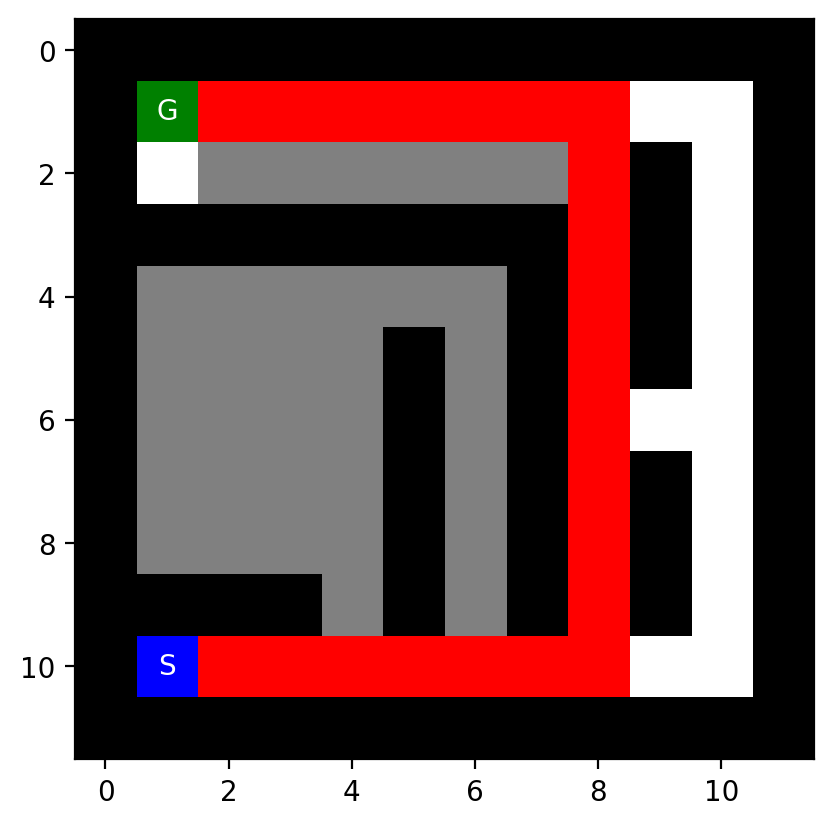

,Algorithm,Path Cost,Nodes Expanded,Max Tree Depth,Max Frontier Size,max memory usage
0,A_BFS,23,57,23,6,66


In [37]:
class Node:
    def __init__(self, pos, parent=None, action=None, cost=0, h=0):
        self.pos = tuple(pos)    # the state; positions are (row, col)
        self.parent = parent     # reference to parent node. None means root node.
        self.action = action     # action used in the transition function (root node has None)
        self.cost = cost         # for uniform cost this is the depth. It is also g(n) for A* search
        self.h = h               # for Manhattan distance
        self.f = self.cost + self.h  # f(n) = g(n) + h(n), A* search uses this
        
    def __str__(self):
        return f"Node - pos = {self.pos}; action = {self.action}; cost = {self.cost}"

    def get_path_from_root(self):
        """Returns nodes on the path from the root to the current node."""
        node = self
        path = [node]

        while node.parent is not None:
            node = node.parent
            path.append(node)

        path.reverse()
        return path

def manhattan_distance(pos, goal):
    """Calculate the Manhattan distance from current position to goal."""
    return abs(pos[0] - goal[0]) + abs(pos[1] - goal[1])

def sorting(frontier, node):
    """Insert the node into the frontier, maintaining the list sorted by heuristic h(n)."""
    inserted = False
    for i in range(len(frontier)):
        if node.f < frontier[i].f:
            frontier.insert(i, node)
            inserted = True
            break
    if not inserted:
        frontier.append(node)  # Insert at the end if not inserted earlier
            
ACTIONS = [(-1, 0, 'North'), (1, 0, 'South'), (0, -1, 'West'), (0, 1, 'East')]    

def mark_maze(maze, pos, symbol):
    """Marks the maze at a given position with a symbol."""
    maze[pos[0]][pos[1]] = symbol

def A_BFS(maze, start, goal):
    # Initialize the initial node and check if it's the goal
    initial_node = Node(pos=start, h=manhattan_distance(start, goal))
    if start == goal:  # Check if the initial state is the goal
        return initial_node.get_path_from_root(), 0, 0, 0, 0

    
    # Initialize the frontier (FIFO queue) and reached set
    frontier = [initial_node]  # Frontier initialized with the initial node
    reached = set()  # Reached set to track visited nodes
    reached.add(start)
    nodes_expanded = 0  # Total number of nodes expanded
    max_tree_depth = 0  # Maximum depth of the search tree
    max_frontier_size = 1  # Maximum size of the frontier (starts with 1, the initial node)
    max_memory_usage = 1  # Maximum number of nodes in memory (frontier + reached)
    # Loop until we either find the goal or exhaust the frontier
    while frontier:
        
        node = frontier.pop(0)
        nodes_expanded += 1  # Count this node as expanded
        if maze[node.pos[0]][node.pos[1]] != 'S':
            mark_maze(maze, node.pos, '.')

        # Explore neighboring nodes (possible actions)
        for dx, dy, action in ACTIONS:
            next_pos = (node.pos[0] + dx, node.pos[1] + dy)  # Next position
            if maze[next_pos[0]][next_pos[1]] != 'X' and next_pos not in reached:
                reached.add(next_pos)
                
                # Create child nodes
                child = Node(next_pos, node, action, node.cost + 1, h=manhattan_distance(next_pos, goal))  # Child branch
                sorting(frontier, child)
                max_tree_depth = max(max_tree_depth, child.cost)
                max_frontier_size = max(max_frontier_size, len(frontier))
                
                if maze[next_pos[0]][next_pos[1]] == 'G':
                    solution_path = child.get_path_from_root()
                    path_cost = len(solution_path) - 1
                    for path_node in solution_path:
                        if maze[path_node.pos[0]][path_node.pos[1]] not in ['G', 'S']:
                            mark_maze(maze, path_node.pos, 'P')
                            clear_output(wait=True)
                            mh.show_maze(maze)
                    return solution_path, path_cost, nodes_expanded, max_tree_depth, max_frontier_size,max_memory_usage


        max_memory_usage = max(max_memory_usage, len(frontier) + len(reached))
        clear_output(wait=True)
        mh.show_maze(maze)
    
    return None
with open("loops_maze.txt", "r") as f:
    maze_str = f.read()
maze = mh.parse_maze(maze_str)
start= mh.find_pos(maze, what = "S")
goal= mh.find_pos(maze, what = "G")
print('start point is',start,'goal point is',goal)


[solution_path,ABFS_loops_path_cost,ABFS_loops_nodes_expanded,ABFS_loops_max_tree_depth, ABFS_loops_max_frontier_size,ABFS_loops_memory_usage] =  A_BFS(maze, start, goal)
data = {
    'Algorithm': ['A_BFS'],
    'Path Cost': [ABFS_loops_path_cost],
    'Nodes Expanded': [ABFS_loops_nodes_expanded],
    'Max Tree Depth': [ABFS_loops_max_tree_depth],
    'Max Frontier Size': [ABFS_loops_max_frontier_size],
    'max memory usage':[ABFS_loops_memory_usage]
}

# Create a DataFrame
df = pd.DataFrame(data)
df

### A* search BFS empty maze

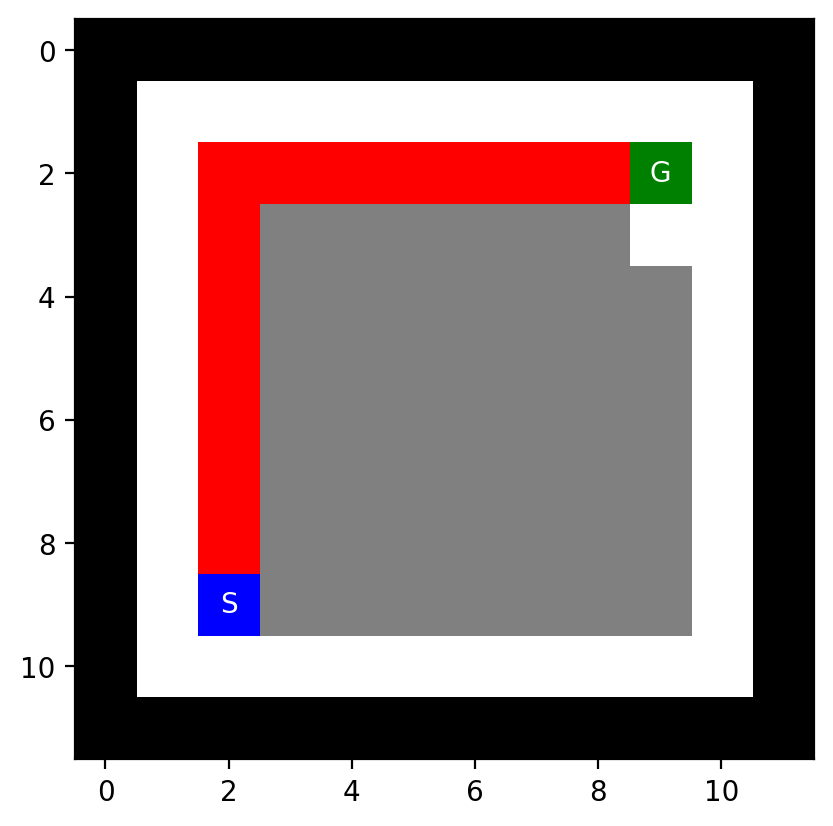

,Algorithm,Path Cost,Nodes Expanded,Max Tree Depth,Max Frontier Size,max memory usage
0,A_BFS,14,62,14,31,121


In [38]:
class Node:
    def __init__(self, pos, parent=None, action=None, cost=0, h=0):
        self.pos = tuple(pos)    # the state; positions are (row, col)
        self.parent = parent     # reference to parent node. None means root node.
        self.action = action     # action used in the transition function (root node has None)
        self.cost = cost         # for uniform cost this is the depth. It is also g(n) for A* search
        self.h = h               # for Manhattan distance
        self.f = self.cost + self.h  # f(n) = g(n) + h(n), A* search uses this
        
    def __str__(self):
        return f"Node - pos = {self.pos}; action = {self.action}; cost = {self.cost}"

    def get_path_from_root(self):
        """Returns nodes on the path from the root to the current node."""
        node = self
        path = [node]

        while node.parent is not None:
            node = node.parent
            path.append(node)

        path.reverse()
        return path

def manhattan_distance(pos, goal):
    """Calculate the Manhattan distance from current position to goal."""
    return abs(pos[0] - goal[0]) + abs(pos[1] - goal[1])

def sorting(frontier, node):
    """Insert the node into the frontier, maintaining the list sorted by heuristic h(n)."""
    inserted = False
    for i in range(len(frontier)):
        if node.f < frontier[i].f:
            frontier.insert(i, node)
            inserted = True
            break
    if not inserted:
        frontier.append(node)  # Insert at the end if not inserted earlier
            
ACTIONS = [(-1, 0, 'North'), (1, 0, 'South'), (0, -1, 'West'), (0, 1, 'East')]    

def mark_maze(maze, pos, symbol):
    """Marks the maze at a given position with a symbol."""
    maze[pos[0]][pos[1]] = symbol

def A_BFS(maze, start, goal):
    # Initialize the initial node and check if it's the goal
    initial_node = Node(pos=start, h=manhattan_distance(start, goal))
    if start == goal:  # Check if the initial state is the goal
        return initial_node.get_path_from_root(), 0, 0, 0, 0

    
    # Initialize the frontier (FIFO queue) and reached set
    frontier = [initial_node]  # Frontier initialized with the initial node
    reached = set()  # Reached set to track visited nodes
    reached.add(start)
    nodes_expanded = 0  # Total number of nodes expanded
    max_tree_depth = 0  # Maximum depth of the search tree
    max_frontier_size = 1  # Maximum size of the frontier
    max_memory_usage = 1  # Maximum number of nodes in memory (frontier + reached)

    # Loop until we either find the goal or exhaust the frontier
    while frontier:
        
        node = frontier.pop(0)
        nodes_expanded += 1  # Count this node as expanded
        if maze[node.pos[0]][node.pos[1]] != 'S':
            mark_maze(maze, node.pos, '.')

        # Explore neighboring nodes (possible actions)
        for dx, dy, action in ACTIONS:
            next_pos = (node.pos[0] + dx, node.pos[1] + dy)  # Next position
            if maze[next_pos[0]][next_pos[1]] != 'X' and next_pos not in reached:
                reached.add(next_pos)
                
                # Create child nodes
                child = Node(next_pos, node, action, node.cost + 1, h=manhattan_distance(next_pos, goal))  # Child branch
                sorting(frontier, child)
                max_tree_depth = max(max_tree_depth, child.cost)
                max_frontier_size = max(max_frontier_size, len(frontier))
                
                if maze[next_pos[0]][next_pos[1]] == 'G':
                    solution_path = child.get_path_from_root()
                    path_cost = len(solution_path) - 1
                    for path_node in solution_path:
                        if maze[path_node.pos[0]][path_node.pos[1]] not in ['G', 'S']:
                            mark_maze(maze, path_node.pos, 'P')
                            clear_output(wait=True)
                            mh.show_maze(maze)
                    return solution_path, path_cost, nodes_expanded, max_tree_depth, max_frontier_size,max_memory_usage


        max_memory_usage = max(max_memory_usage, len(frontier) + len(reached))
        clear_output(wait=True)
        mh.show_maze(maze)
    
    return None
with open("empty_maze.txt", "r") as f:
    maze_str = f.read()
maze = mh.parse_maze(maze_str)
start= mh.find_pos(maze, what = "S")
goal= mh.find_pos(maze, what = "G")
print('start point is',start,'goal point is',goal)


[solution_path,ABFS_empty_path_cost,ABFS_empty_nodes_expanded,ABFS_empty_max_tree_depth, ABFS_empty_max_frontier_size,ABFS_empty_memory_usage] =  A_BFS(maze, start, goal)
data = {
    'Algorithm': ['A_BFS'],
    'Path Cost': [ABFS_empty_path_cost],
    'Nodes Expanded': [ABFS_empty_nodes_expanded],
    'Max Tree Depth': [ABFS_empty_max_tree_depth],
    'Max Frontier Size': [ABFS_empty_max_frontier_size],
    'max memory usage':[ABFS_empty_memory_usage]
}

# Create a DataFrame
df = pd.DataFrame(data)
df

### A* search BFS empty_2 maze

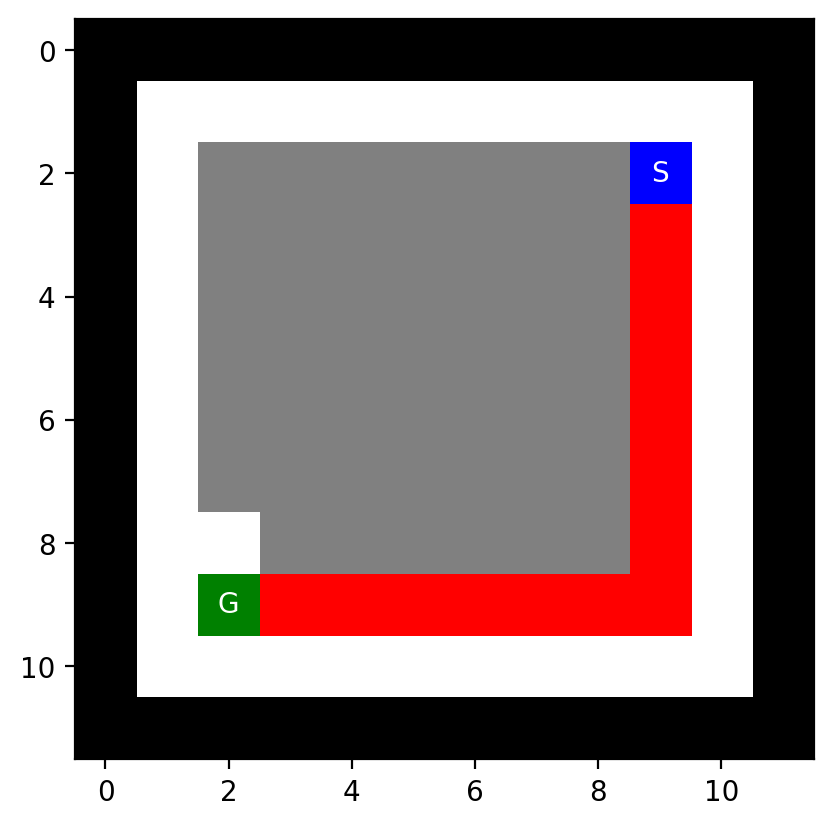

,Algorithm,Path Cost,Nodes Expanded,Max Tree Depth,Max Frontier Size,max memory usage
0,A_BFS,14,62,14,31,121


In [39]:
class Node:
    def __init__(self, pos, parent=None, action=None, cost=0, h=0):
        self.pos = tuple(pos)    # the state; positions are (row, col)
        self.parent = parent     # reference to parent node. None means root node.
        self.action = action     # action used in the transition function (root node has None)
        self.cost = cost         # for uniform cost this is the depth. It is also g(n) for A* search
        self.h = h               # for Manhattan distance
        self.f = self.cost + self.h  # f(n) = g(n) + h(n), A* search uses this
        
    def __str__(self):
        return f"Node - pos = {self.pos}; action = {self.action}; cost = {self.cost}"

    def get_path_from_root(self):
        """Returns nodes on the path from the root to the current node."""
        node = self
        path = [node]

        while node.parent is not None:
            node = node.parent
            path.append(node)

        path.reverse()
        return path

def manhattan_distance(pos, goal):
    """Calculate the Manhattan distance from current position to goal."""
    return abs(pos[0] - goal[0]) + abs(pos[1] - goal[1])

def sorting(frontier, node):
    """Insert the node into the frontier, maintaining the list sorted by heuristic h(n)."""
    inserted = False
    for i in range(len(frontier)):
        if node.f < frontier[i].f:
            frontier.insert(i, node)
            inserted = True
            break
    if not inserted:
        frontier.append(node)  # Insert at the end if not inserted earlier
            
ACTIONS = [(-1, 0, 'North'), (1, 0, 'South'), (0, -1, 'West'), (0, 1, 'East')]    

def mark_maze(maze, pos, symbol):
    """Marks the maze at a given position with a symbol."""
    maze[pos[0]][pos[1]] = symbol

def A_BFS(maze, start, goal):
    # Initialize the initial node and check if it's the goal
    initial_node = Node(pos=start, h=manhattan_distance(start, goal))
    if start == goal:  # Check if the initial state is the goal
        return initial_node.get_path_from_root(), 0, 0, 0, 0

    
    # Initialize the frontier (FIFO queue) and reached set
    frontier = [initial_node]  # Frontier initialized with the initial node
    reached = set()  # Reached set to track visited nodes
    reached.add(start)
    nodes_expanded = 0  # Total number of nodes expanded
    max_tree_depth = 0  # Maximum depth of the search tree
    max_frontier_size = 1  # Maximum size of the frontier
    max_memory_usage = 1  # Maximum number of nodes in memory (frontier + reached)

    # Loop until we either find the goal or exhaust the frontier
    while frontier:
        
        node = frontier.pop(0)
        nodes_expanded += 1  # Count this node as expanded
        if maze[node.pos[0]][node.pos[1]] != 'S':
            mark_maze(maze, node.pos, '.')

        # Explore neighboring nodes (possible actions)
        for dx, dy, action in ACTIONS:
            next_pos = (node.pos[0] + dx, node.pos[1] + dy)  # Next position
            if maze[next_pos[0]][next_pos[1]] != 'X' and next_pos not in reached:
                reached.add(next_pos)
                
                # Create child nodes
                child = Node(next_pos, node, action, node.cost + 1, h=manhattan_distance(next_pos, goal))  # Child branch
                sorting(frontier, child)
                max_tree_depth = max(max_tree_depth, child.cost)
                max_frontier_size = max(max_frontier_size, len(frontier))
                
                if maze[next_pos[0]][next_pos[1]] == 'G':
                    solution_path = child.get_path_from_root()
                    path_cost = len(solution_path) - 1
                    for path_node in solution_path:
                        if maze[path_node.pos[0]][path_node.pos[1]] not in ['G', 'S']:
                            mark_maze(maze, path_node.pos, 'P')
                            clear_output(wait=True)
                            mh.show_maze(maze)
                    return solution_path, path_cost, nodes_expanded, max_tree_depth, max_frontier_size,max_memory_usage

        max_memory_usage = max(max_memory_usage, len(frontier) + len(reached))
        clear_output(wait=True)
        mh.show_maze(maze)
    
    return None
with open("empty_2_maze.txt", "r") as f:
    maze_str = f.read()
maze = mh.parse_maze(maze_str)
start= mh.find_pos(maze, what = "S")
goal= mh.find_pos(maze, what = "G")
print('start point is',start,'goal point is',goal)


[solution_path,ABFS_empty_2_path_cost,ABFS_empty_2_nodes_expanded,ABFS_empty_2_max_tree_depth, ABFS_empty_2_max_frontier_size,ABFS_empty_2_memory_usage] =  A_BFS(maze, start, goal)
data = {
    'Algorithm': ['A_BFS'],
    'Path Cost': [ABFS_empty_2_path_cost],
    'Nodes Expanded': [ABFS_empty_2_nodes_expanded],
    'Max Tree Depth': [ABFS_empty_2_max_tree_depth],
    'Max Frontier Size': [ABFS_empty_2_max_frontier_size],
    'max memory usage':[ABFS_empty_2_memory_usage]
}

# Create a DataFrame
df = pd.DataFrame(data)
df

### A* search BFS open maze

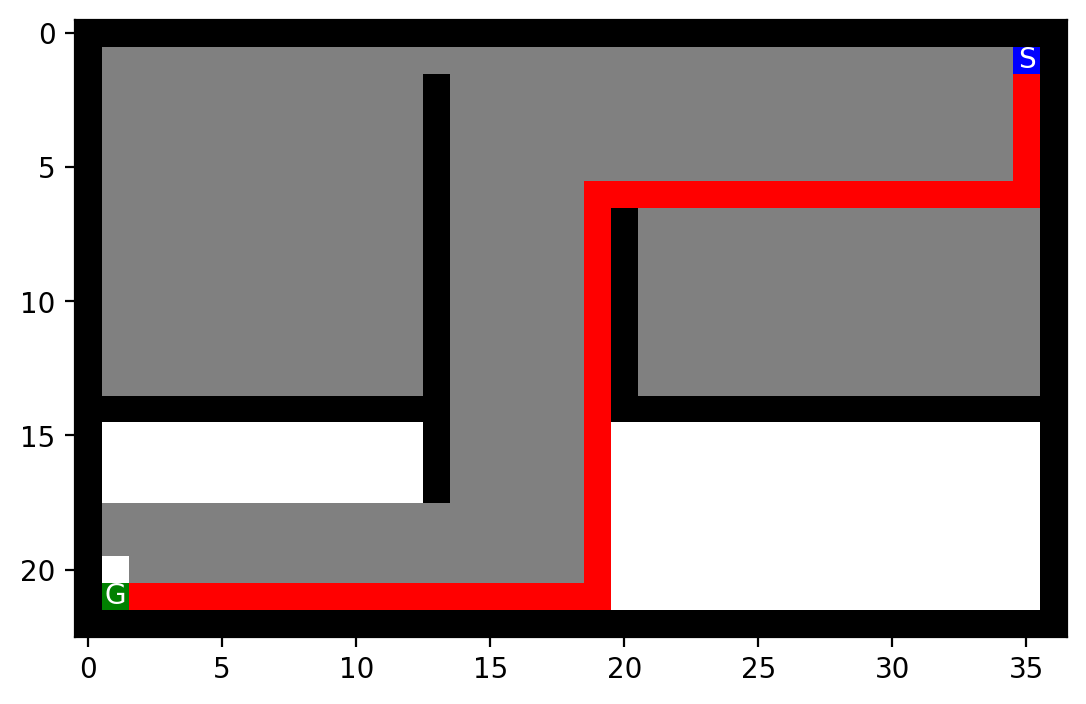

,Algorithm,Path Cost,Nodes Expanded,Max Tree Depth,Max Frontier Size,max memory usage
0,A_BFS,54,534,54,25,576


In [41]:
class Node:
    def __init__(self, pos, parent=None, action=None, cost=0, h=0):
        self.pos = tuple(pos)    # the state; positions are (row, col)
        self.parent = parent     # reference to parent node. None means root node.
        self.action = action     # action used in the transition function (root node has None)
        self.cost = cost         # for uniform cost this is the depth. It is also g(n) for A* search
        self.h = h               # for Manhattan distance
        self.f = self.cost + self.h  # f(n) = g(n) + h(n), A* search uses this
        
    def __str__(self):
        return f"Node - pos = {self.pos}; action = {self.action}; cost = {self.cost}"

    def get_path_from_root(self):
        """Returns nodes on the path from the root to the current node."""
        node = self
        path = [node]

        while node.parent is not None:
            node = node.parent
            path.append(node)

        path.reverse()
        return path

def manhattan_distance(pos, goal):
    """Calculate the Manhattan distance from current position to goal."""
    return abs(pos[0] - goal[0]) + abs(pos[1] - goal[1])

def sorting(frontier, node):
    """Insert the node into the frontier, maintaining the list sorted by heuristic h(n)."""
    inserted = False
    for i in range(len(frontier)):
        if node.f < frontier[i].f:
            frontier.insert(i, node)
            inserted = True
            break
    if not inserted:
        frontier.append(node)  # Insert at the end if not inserted earlier
            
ACTIONS = [(-1, 0, 'North'), (1, 0, 'South'), (0, -1, 'West'), (0, 1, 'East')]    

def mark_maze(maze, pos, symbol):
    """Marks the maze at a given position with a symbol."""
    maze[pos[0]][pos[1]] = symbol

def A_BFS(maze, start, goal):
    # Initialize the initial node and check if it's the goal
    initial_node = Node(pos=start, h=manhattan_distance(start, goal))
    if start == goal:  # Check if the initial state is the goal
        return initial_node.get_path_from_root(), 0, 0, 0, 0

    
    # Initialize the frontier (FIFO queue) and reached set
    frontier = [initial_node]  # Frontier initialized with the initial node
    reached = set()  # Reached set to track visited nodes
    reached.add(start)
    nodes_expanded = 0  # Total number of nodes expanded
    max_tree_depth = 0  # Maximum depth of the search tree
    max_frontier_size = 1  # Maximum size of the frontier
    max_memory_usage = 1  # Maximum number of nodes in memory (frontier + reached)

    # Loop until we either find the goal or exhaust the frontier
    while frontier:
        
        node = frontier.pop(0)
        nodes_expanded += 1  # Count this node as expanded
        if maze[node.pos[0]][node.pos[1]] != 'S':
            mark_maze(maze, node.pos, '.')

        # Explore neighboring nodes (possible actions)
        for dx, dy, action in ACTIONS:
            next_pos = (node.pos[0] + dx, node.pos[1] + dy)  # Next position
            if maze[next_pos[0]][next_pos[1]] != 'X' and next_pos not in reached:
                reached.add(next_pos)
                
                # Create child nodes
                child = Node(next_pos, node, action, node.cost + 1, h=manhattan_distance(next_pos, goal))  # Child branch
                sorting(frontier, child)
                max_tree_depth = max(max_tree_depth, child.cost)
                max_frontier_size = max(max_frontier_size, len(frontier))
                
                if maze[next_pos[0]][next_pos[1]] == 'G':
                    solution_path = child.get_path_from_root()
                    path_cost = len(solution_path) - 1
                    for path_node in solution_path:
                        if maze[path_node.pos[0]][path_node.pos[1]] not in ['G', 'S']:
                            mark_maze(maze, path_node.pos, 'P')
                            clear_output(wait=True)
                            mh.show_maze(maze)
                    return solution_path, path_cost, nodes_expanded, max_tree_depth, max_frontier_size,max_memory_usage

        max_memory_usage = max(max_memory_usage, len(frontier) + len(reached))
        clear_output(wait=True)
        mh.show_maze(maze)
    
    return None
with open("open_maze.txt", "r") as f:
    maze_str = f.read()
maze = mh.parse_maze(maze_str)
start= mh.find_pos(maze, what = "S")
goal= mh.find_pos(maze, what = "G")
print('start point is',start,'goal point is',goal)


[solution_path,ABFS_open_path_cost,ABFS_open_nodes_expanded,ABFS_open_max_tree_depth, ABFS_open_max_frontier_size,ABFS_open_memory_usage] =  A_BFS(maze, start, goal)
data = {
    'Algorithm': ['A_BFS'],
    'Path Cost': [ABFS_open_path_cost],
    'Nodes Expanded': [ABFS_open_nodes_expanded],
    'Max Tree Depth': [ABFS_open_max_tree_depth],
    'Max Frontier Size': [ABFS_open_max_frontier_size],
    'max memory usage':[ABFS_open_memory_usage]
}

# Create a DataFrame
df = pd.DataFrame(data)
df

Are your implementations complete and optimal? What is the time and space complexity?

both Greedy-BFS and A*-BFS are complete. the Greedy-BFS is not optimal but A* is optimal.
Time complexity for Greedy-BFS is O(bm) in best case and O(b^m) in worst case
Space complexity for Greedy-BFS is O(bm) in best case and O(b^m) in worst case
Time complexity for A*-BFS is equal to number of nodes
space complexity for A*-BFS is equal to number of nodes

## Task 4: Comparison and discussion [20 Points]

Run experiments to compare the implemented algorithms.

How to deal with issues:

* Your implementation returns unexpected results: Try to debug and fix the code. Visualizing the maze, the current path and the frontier after every step is very helpful. If the code still does not work, then mark the result with an asterisk (*) and describe the issue below the table.

* Your implementation cannot consistently solve a specific maze and ends up in an infinite loop:
    Debug (likely your frontier and cycle checking for DFS are the issue). If it is a shortcoming of the algorithm/implementation, then put "N/A*" in the results table and describe why this is happening.

Complete the following table for each maze.

**Small maze**

In [42]:
import pandas as pd

# Create a dictionary with the data for each algorithm (initialize as empty or zero)
data = {
    'Algorithm': ['BFS', 'DFS', 'GBS', 'A*'],
    'Path Cost': [BFS_small_path_cost,DFS_small_path_cost, GBFS_small_path_cost, ABFS_small_path_cost],
    '# of Nodes Expanded': [BFS_small_nodes_expanded, DFS_small_nodes_expanded, GBFS_small_nodes_expanded, ABFS_small_nodes_expanded],
    'Max Tree Depth': [BFS_small_max_tree_depth, DFS_small_max_tree_depth, GBFS_small_max_tree_depth, ABFS_small_max_tree_depth],
    'Max # of Nodes in Memory': [BFS_small_memory_usage, DFS_small_memory_usage, GBFS_small_memory_usage, ABFS_small_memory_usage],
    'Max Frontier Size': [BFS_small_max_frontier_size, DFS_small_max_frontier_size, GBFS_small_max_frontier_size, ABFS_small_max_frontier_size]
}

# Create a DataFrame from the dictionary
df_small = pd.DataFrame(data)

# Display the DataFrame
df_small


,Algorithm,Path Cost,# of Nodes Expanded,Max Tree Depth,Max # of Nodes in Memory,Max Frontier Size
0,BFS,19,90,19,94,8
1,DFS,37,37,36,43,7
2,GBS,29,39,29,90,48
3,A*,19,52,19,65,8


**Medium maze**

In [43]:
import pandas as pd

# Create a dictionary with the data for each algorithm (initialize as empty or zero)
data = {
    'Algorithm': ['BFS', 'DFS', 'GBS', 'A*'],
    'Path Cost': [BFS_medium_path_cost,DFS_medium_path_cost, GBFS_medium_path_cost, ABFS_medium_path_cost],
    '# of Nodes Expanded': [BFS_medium_nodes_expanded, DFS_medium_nodes_expanded, GBFS_medium_nodes_expanded, ABFS_medium_nodes_expanded],
    'Max Tree Depth': [BFS_medium_max_tree_depth, DFS_medium_max_tree_depth, GBFS_medium_max_tree_depth, ABFS_medium_max_tree_depth],
    'Max # of Nodes in Memory': [BFS_medium_memory_usage, DFS_medium_memory_usage, GBFS_medium_memory_usage, ABFS_medium_memory_usage],
    'Max Frontier Size': [BFS_medium_max_frontier_size, DFS_medium_max_frontier_size, GBFS_medium_max_frontier_size, ABFS_medium_max_frontier_size]
}

# Create a DataFrame from the dictionary
df_medium = pd.DataFrame(data)

# Display the DataFrame
df_medium 


,Algorithm,Path Cost,# of Nodes Expanded,Max Tree Depth,Max # of Nodes in Memory,Max Frontier Size
0,BFS,68,267,68,272,8
1,DFS,130,146,129,154,9
2,GBS,74,78,74,165,85
3,A*,68,221,68,234,8


**large maze**

In [44]:
import pandas as pd

# Create a dictionary with the data for each algorithm (initialize as empty or zero)
data = {
    'Algorithm': ['BFS', 'DFS', 'GBS', 'A*'],
    'Path Cost': [BFS_large_path_cost,DFS_large_path_cost, GBFS_large_path_cost, ABFS_large_path_cost],
    '# of Nodes Expanded': [BFS_large_nodes_expanded, DFS_large_nodes_expanded, GBFS_large_nodes_expanded, ABFS_large_nodes_expanded],
    'Max Tree Depth': [BFS_large_max_tree_depth, DFS_large_max_tree_depth, GBFS_large_max_tree_depth, ABFS_large_max_tree_depth],
    'Max # of Nodes in Memory': [BFS_large_memory_usage, DFS_large_memory_usage, GBFS_large_memory_usage, ABFS_large_memory_usage],
    'Max Frontier Size': [BFS_large_max_frontier_size, DFS_large_max_frontier_size, GBFS_large_max_frontier_size, ABFS_large_max_frontier_size]
}

# Create a DataFrame from the dictionary
df_large = pd.DataFrame(data)

# Display the DataFrame
df_large


,Algorithm,Path Cost,# of Nodes Expanded,Max Tree Depth,Max # of Nodes in Memory,Max Frontier Size
0,BFS,210,617,210,624,8
1,DFS,210,387,222,425,39
2,GBS,210,668,210,790,305
3,A*,210,549,210,564,12


**wall maze**

In [45]:
import pandas as pd

# Create a dictionary with the data for each algorithm (initialize as empty or zero)
data = {
    'Algorithm': ['BFS', 'DFS', 'GBS', 'A*'],
    'Path Cost': [BFS_wall_path_cost,DFS_wall_path_cost, GBFS_wall_path_cost, ABFS_wall_path_cost],
    '# of Nodes Expanded': [BFS_wall_nodes_expanded, DFS_wall_nodes_expanded, GBFS_wall_nodes_expanded, ABFS_wall_nodes_expanded],
    'Max Tree Depth': [BFS_wall_max_tree_depth, DFS_wall_max_tree_depth, GBFS_wall_max_tree_depth, ABFS_wall_max_tree_depth],
    'Max # of Nodes in Memory': [BFS_wall_memory_usage, DFS_wall_memory_usage, GBFS_wall_memory_usage, ABFS_wall_memory_usage],
    'Max Frontier Size': [BFS_wall_max_frontier_size, DFS_wall_max_frontier_size, GBFS_wall_max_frontier_size, ABFS_wall_max_frontier_size]
}

# Create a DataFrame from the dictionary
df_wall = pd.DataFrame(data)

# Display the DataFrame
df_wall


,Algorithm,Path Cost,# of Nodes Expanded,Max Tree Depth,Max # of Nodes in Memory,Max Frontier Size
0,BFS,14,85,14,92,11
1,DFS,44,44,43,79,36
2,GBS,14,14,14,106,71
3,A*,14,55,14,114,31


**loops maze**

In [46]:
import pandas as pd

# Create a dictionary with the data for each algorithm (initialize as empty or zero)
data = {
    'Algorithm': ['BFS', 'DFS', 'GBS', 'A*'],
    'Path Cost': [BFS_loops_path_cost,DFS_loops_path_cost, GBFS_loops_path_cost, ABFS_loops_path_cost],
    '# of Nodes Expanded': [BFS_loops_nodes_expanded, DFS_loops_nodes_expanded, GBFS_loops_nodes_expanded, ABFS_loops_nodes_expanded],
    'Max Tree Depth': [BFS_loops_max_tree_depth, DFS_loops_max_tree_depth, GBFS_loops_max_tree_depth, ABFS_loops_max_tree_depth],
    'Max # of Nodes in Memory': [BFS_loops_memory_usage, DFS_loops_memory_usage, GBFS_loops_memory_usage, ABFS_loops_memory_usage],
    'Max Frontier Size': [BFS_loops_max_frontier_size, DFS_loops_max_frontier_size, GBFS_loops_max_frontier_size, ABFS_loops_max_frontier_size]
}

# Create a DataFrame from the dictionary
df_loops = pd.DataFrame(data)

# Display the DataFrame
df_loops


,Algorithm,Path Cost,# of Nodes Expanded,Max Tree Depth,Max # of Nodes in Memory,Max Frontier Size
0,BFS,23,70,23,73,8
1,DFS,27,30,26,41,12
2,GBS,23,85,23,92,36
3,A*,23,57,23,66,6


**empty maze**

In [47]:
import pandas as pd

# Create a dictionary with the data for each algorithm (initialize as empty or zero)
data = {
    'Algorithm': ['BFS', 'DFS', 'GBS', 'A*'],
    'Path Cost': [BFS_empty_path_cost,DFS_empty_path_cost, GBFS_empty_path_cost, ABFS_empty_path_cost],
    '# of Nodes Expanded': [BFS_empty_nodes_expanded, DFS_empty_nodes_expanded, GBFS_empty_nodes_expanded, ABFS_empty_nodes_expanded],
    'Max Tree Depth': [BFS_empty_max_tree_depth, DFS_empty_max_tree_depth, GBFS_empty_max_tree_depth, ABFS_empty_max_tree_depth],
    'Max # of Nodes in Memory': [BFS_empty_memory_usage, DFS_empty_memory_usage, GBFS_empty_memory_usage, ABFS_empty_memory_usage],
    'Max Frontier Size': [BFS_empty_max_frontier_size, DFS_empty_max_frontier_size, GBFS_empty_max_frontier_size, ABFS_empty_max_frontier_size]
}

# Create a DataFrame from the dictionary
df_empty = pd.DataFrame(data)

# Display the DataFrame
df_empty


,Algorithm,Path Cost,# of Nodes Expanded,Max Tree Depth,Max # of Nodes in Memory,Max Frontier Size
0,BFS,14,92,14,99,12
1,DFS,72,72,71,136,65
2,GBS,14,14,14,106,71
3,A*,14,62,14,121,31


**empty_2 maze**

In [48]:
import pandas as pd

# Create a dictionary with the data for each algorithm (initialize as empty or zero)
data = {
    'Algorithm': ['BFS', 'DFS', 'GBS', 'A*'],
    'Path Cost': [BFS_empty_2_path_cost,DFS_empty_2_path_cost, GBFS_empty_2_path_cost, ABFS_empty_2_path_cost],
    '# of Nodes Expanded': [BFS_empty_2_nodes_expanded, DFS_empty_2_nodes_expanded, GBFS_empty_2_nodes_expanded, ABFS_empty_2_nodes_expanded],
    'Max Tree Depth': [BFS_empty_2_max_tree_depth, DFS_empty_2_max_tree_depth, GBFS_empty_2_max_tree_depth, ABFS_empty_2_max_tree_depth],
    'Max # of Nodes in Memory': [BFS_empty_2_memory_usage, DFS_empty_2_memory_usage, GBFS_empty_2_memory_usage, ABFS_empty_2_memory_usage],
    'Max Frontier Size': [BFS_empty_2_max_frontier_size, DFS_empty_2_max_frontier_size, GBFS_empty_2_max_frontier_size, ABFS_empty_2_max_frontier_size]
}

# Create a DataFrame from the dictionary
df_empty_2 = pd.DataFrame(data)

# Display the DataFrame
df_empty_2


,Algorithm,Path Cost,# of Nodes Expanded,Max Tree Depth,Max # of Nodes in Memory,Max Frontier Size
0,BFS,14,92,14,99,12
1,DFS,54,54,53,112,59
2,GBS,14,14,14,106,71
3,A*,14,62,14,121,31


**open maze**

In [49]:
import pandas as pd

# Create a dictionary with the data for each algorithm (initialize as empty or zero)
data = {
    'Algorithm': ['BFS', 'DFS', 'GBS', 'A*'],
    'Path Cost': [BFS_open_path_cost,DFS_open_path_cost, GBFS_open_path_cost, ABFS_open_path_cost],
    '# of Nodes Expanded': [BFS_open_nodes_expanded, DFS_open_nodes_expanded, GBFS_open_nodes_expanded, ABFS_open_nodes_expanded],
    'Max Tree Depth': [BFS_open_max_tree_depth, DFS_open_max_tree_depth, GBFS_open_max_tree_depth, ABFS_open_max_tree_depth],
    'Max # of Nodes in Memory': [BFS_open_memory_usage, DFS_open_memory_usage, GBFS_open_memory_usage, ABFS_open_memory_usage],
    'Max Frontier Size': [BFS_open_max_frontier_size, DFS_open_max_frontier_size, GBFS_open_max_frontier_size, ABFS_open_max_frontier_size]
}

# Create a DataFrame from the dictionary
df_open = pd.DataFrame(data)

# Display the DataFrame
df_open


,Algorithm,Path Cost,# of Nodes Expanded,Max Tree Depth,Max # of Nodes in Memory,Max Frontier Size
0,BFS,54,679,54,687,25
1,DFS,330,7595,329,936,329
2,GBS,68,89,68,370,220
3,A*,54,534,54,576,25


Present the results as using charts (see [Python Code Examples/charts and tables](../HOWTOs/charts_and_tables.ipynb)).

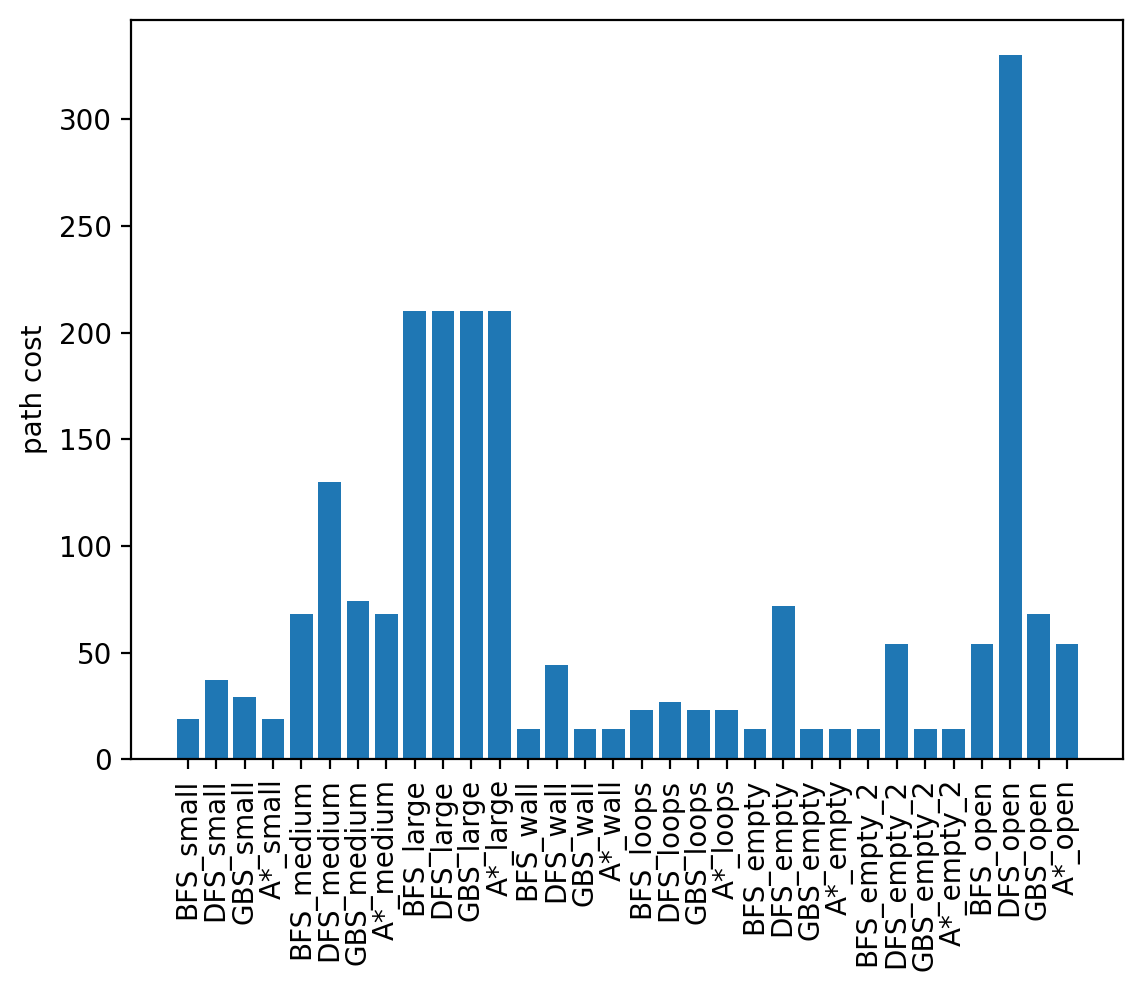

In [60]:
import matplotlib.pyplot as plt
path_costs = list(df_small['Path Cost'])+list(df_medium['Path Cost'])+list(df_large['Path Cost'])+list(
    df_wall['Path Cost'])+ list(df_loops['Path Cost']) + list(df_empty['Path Cost'])+ list(df_empty_2['Path Cost'])+ list(df_open['Path Cost'])

# Create the labels for each bar
labels = ['BFS_small', 'DFS_small', 'GBS_small', 'A*_small',
          'BFS_medium', 'DFS_medium', 'GBS_medium', 'A*_medium',
          'BFS_large', 'DFS_large', 'GBS_large', 'A*_large',
          'BFS_wall', 'DFS_wall', 'GBS_wall', 'A*_wall',
          'BFS_loops', 'DFS_loops', 'GBS_loops', 'A*_loops',
          'BFS_empty', 'DFS_empty', 'GBS_empty', 'A*_empty',
          'BFS_empty_2', 'DFS_empty_2', 'GBS_empty_2', 'A*_empty_2',
          'BFS_open', 'DFS_open', 'GBS_open', 'A*_open']

# Plot the bar chart
plt.bar(labels, path_costs)
plt.ylabel("path cost")
plt.xticks(rotation=90)
plt.show()

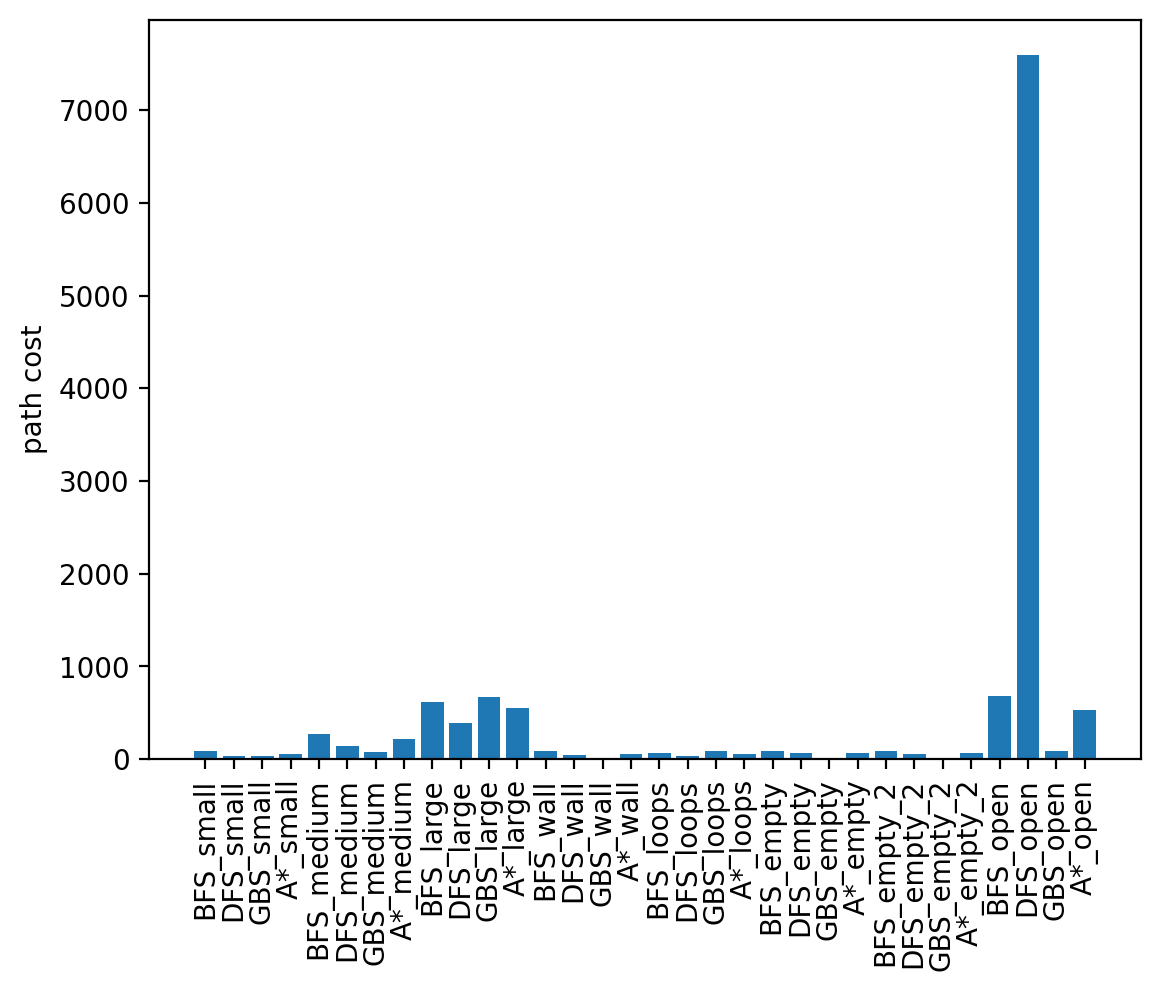

In [61]:
import matplotlib.pyplot as plt
path_costs = list(df_small['# of Nodes Expanded'])+list(df_medium['# of Nodes Expanded'])+list(df_large['# of Nodes Expanded'])+list(
    df_wall['# of Nodes Expanded'])+ list(df_loops['# of Nodes Expanded']) + list(
    df_empty['# of Nodes Expanded'])+ list(df_empty_2['# of Nodes Expanded'])+ list(df_open['# of Nodes Expanded'])

# Create the labels for each bar
labels = ['BFS_small', 'DFS_small', 'GBS_small', 'A*_small',
          'BFS_medium', 'DFS_medium', 'GBS_medium', 'A*_medium',
          'BFS_large', 'DFS_large', 'GBS_large', 'A*_large',
          'BFS_wall', 'DFS_wall', 'GBS_wall', 'A*_wall',
          'BFS_loops', 'DFS_loops', 'GBS_loops', 'A*_loops',
          'BFS_empty', 'DFS_empty', 'GBS_empty', 'A*_empty',
          'BFS_empty_2', 'DFS_empty_2', 'GBS_empty_2', 'A*_empty_2',
          'BFS_open', 'DFS_open', 'GBS_open', 'A*_open']

# Plot the bar chart
plt.bar(labels, path_costs)
plt.ylabel("path cost")
plt.xticks(rotation=90)
plt.show()

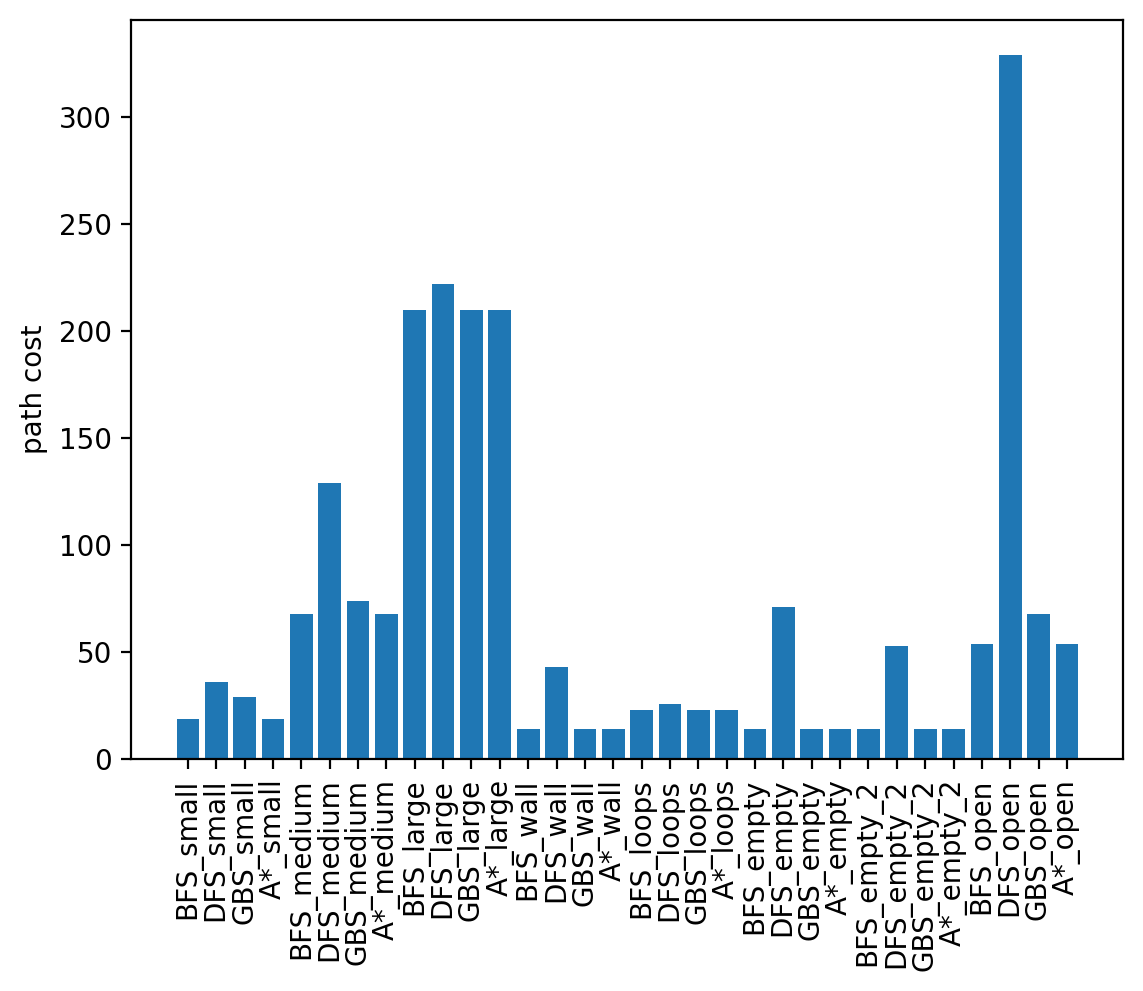

In [62]:
import matplotlib.pyplot as plt
path_costs = list(df_small['Max Tree Depth'])+list(df_medium['Max Tree Depth'])+list(df_large['Max Tree Depth'])+list(
    df_wall['Max Tree Depth'])+ list(df_loops['Max Tree Depth']) + list(
    df_empty['Max Tree Depth'])+ list(df_empty_2['Max Tree Depth'])+ list(df_open['Max Tree Depth'])

# Create the labels for each bar
labels = ['BFS_small', 'DFS_small', 'GBS_small', 'A*_small',
          'BFS_medium', 'DFS_medium', 'GBS_medium', 'A*_medium',
          'BFS_large', 'DFS_large', 'GBS_large', 'A*_large',
          'BFS_wall', 'DFS_wall', 'GBS_wall', 'A*_wall',
          'BFS_loops', 'DFS_loops', 'GBS_loops', 'A*_loops',
          'BFS_empty', 'DFS_empty', 'GBS_empty', 'A*_empty',
          'BFS_empty_2', 'DFS_empty_2', 'GBS_empty_2', 'A*_empty_2',
          'BFS_open', 'DFS_open', 'GBS_open', 'A*_open']

# Plot the bar chart
plt.bar(labels, path_costs)
plt.ylabel("path cost")
plt.xticks(rotation=90)
plt.show()

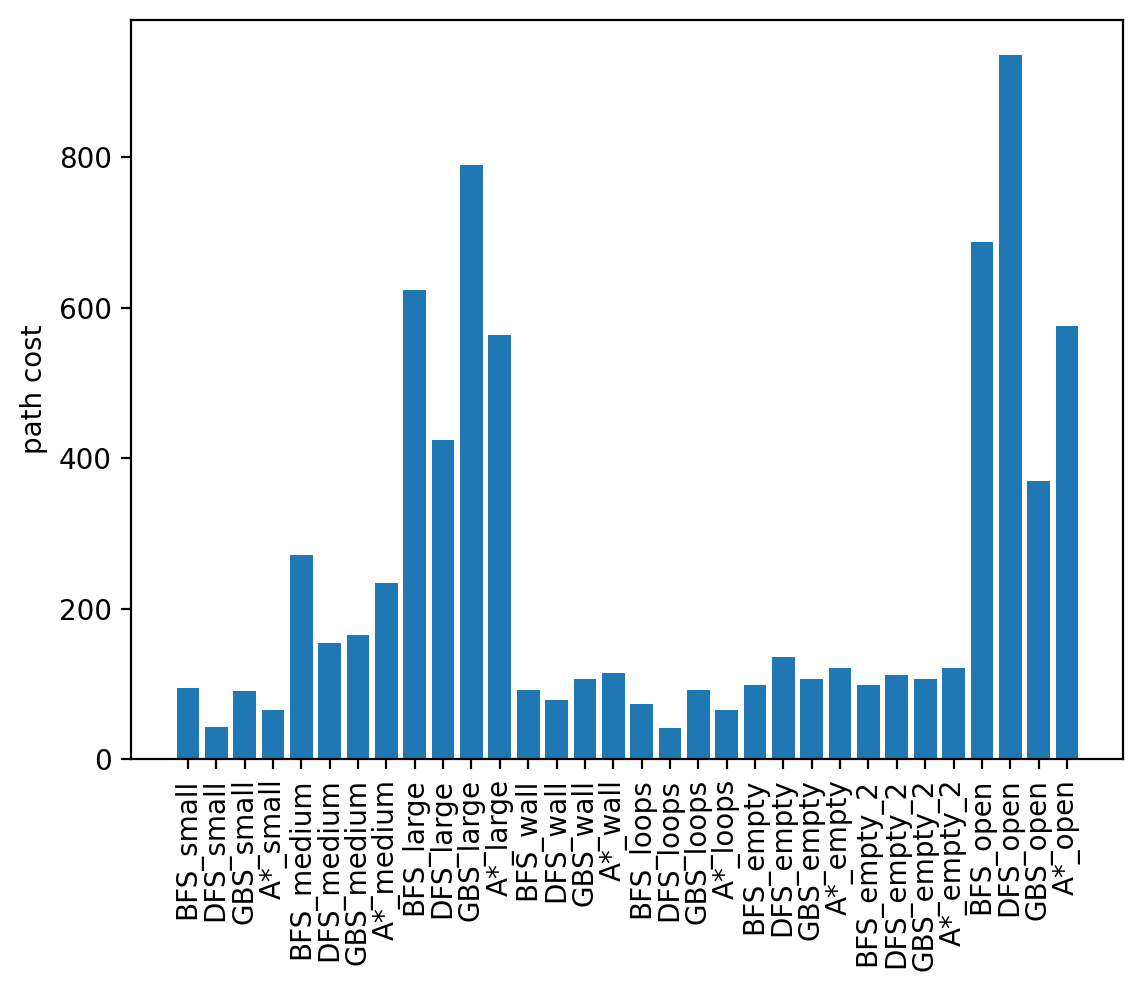

In [63]:
import matplotlib.pyplot as plt
path_costs = list(df_small['Max # of Nodes in Memory'])+list(df_medium['Max # of Nodes in Memory'])+list(df_large['Max # of Nodes in Memory'])+list(
    df_wall['Max # of Nodes in Memory'])+ list(df_loops['Max # of Nodes in Memory']) + list(
    df_empty['Max # of Nodes in Memory'])+ list(df_empty_2['Max # of Nodes in Memory'])+ list(df_open['Max # of Nodes in Memory'])

# Create the labels for each bar
labels = ['BFS_small', 'DFS_small', 'GBS_small', 'A*_small',
          'BFS_medium', 'DFS_medium', 'GBS_medium', 'A*_medium',
          'BFS_large', 'DFS_large', 'GBS_large', 'A*_large',
          'BFS_wall', 'DFS_wall', 'GBS_wall', 'A*_wall',
          'BFS_loops', 'DFS_loops', 'GBS_loops', 'A*_loops',
          'BFS_empty', 'DFS_empty', 'GBS_empty', 'A*_empty',
          'BFS_empty_2', 'DFS_empty_2', 'GBS_empty_2', 'A*_empty_2',
          'BFS_open', 'DFS_open', 'GBS_open', 'A*_open']

# Plot the bar chart
plt.bar(labels, path_costs)
plt.ylabel("path cost")
plt.xticks(rotation=90)
plt.show()

Discuss the most important lessons you have learned from implementing the different search strategies.

BFS assures finding the shortest path if one exists, but at the cost of high memory utilization, especially in large state spaces.When the search space is large, it can soon become inefficient since it investigates all possible node level by level. DFS is memory efficient as it does not keep the track of visited nodes and clear its history. However, it may miss optimal solutions and can get stuck in infinite loops if there are cycles, making it incomplete unless modified with a depth limit or cycle detection. GBS performs the search using a heuristic, which narrows the search space that is investigated. However, as it does not consider the cost of the path already taken, it may not find the optimal path. A* integrates both the path cost and a heuristic. A* finds the optimal solution (if admissionable) while being more efficient than BFS because it avoids exploring paths that are unlikely to be part of the optimal solution. overall, BFS is well-suited for problems where finding the shortest path is critical, and the state space is not too large. DFS works well in situations where memory is limited, but the solution depth is unknown or the search space is deep. GBS can be useful in situations where a quick solution is needed and optimality is not the primary concern. A* is preferred when both efficiency and optimality are required, and an appropriate heuristic is available.

## Advanced task: IDS and Multiple goals

* __Graduate students__ need to complete this task [10 points]
* __Undergraduate students__ can attempt this as a bonus task [max +5 bonus points].

### IDS
Implement IDS (iterative deepening search) using your DFS implementation. Test IDS on the mazes above. You may run into some issues with mazes with open spaces. If you cannot resolve the issus, then report and discuss what causes the problems.

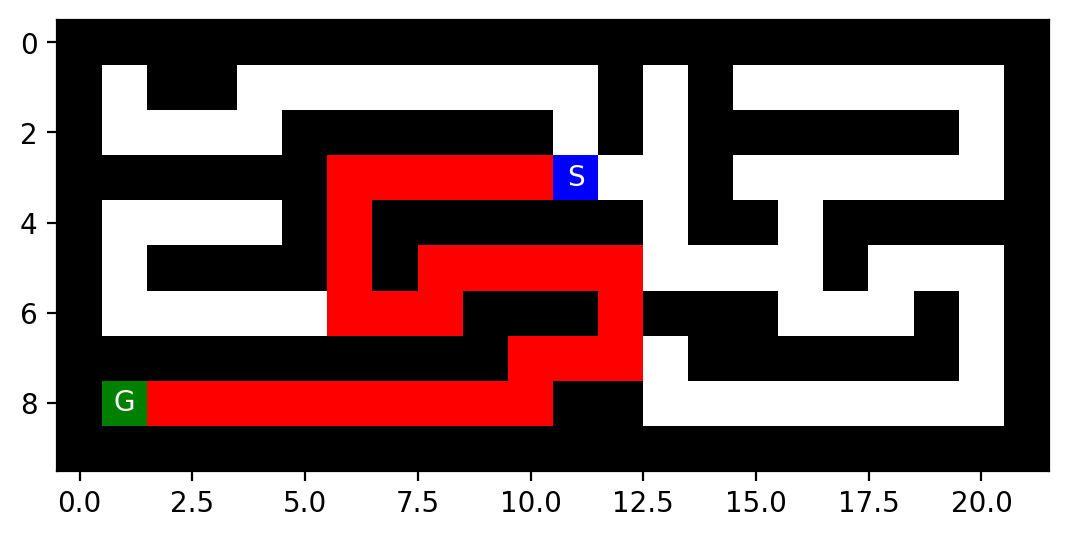

In [64]:
class Node:
    def __init__(self, pos, parent=None, action=None, cost=0):
        self.pos = tuple(pos)    # the state; positions are (row, col)
        self.parent = parent     # reference to parent node. None means root node.
        self.action = action     # action used in the transition function (root node has None)
        self.cost = cost         # for uniform cost this is the depth

    def __str__(self):
        return f"Node - pos = {self.pos}; action = {self.action}; cost = {self.cost}"

    def get_path_from_root(self):
        """Returns nodes on the path from the root to the current node."""
        node = self
        path = [node]
        while node.parent is not None:
            node = node.parent
            path.append(node)
        path.reverse()
        return path


ACTIONS = [(-1, 0, 'North'), (1, 0, 'South'), (0, -1, 'West'), (0, 1, 'East')]

def mark_maze(maze, pos, symbol):
    """Marks the maze at a given position with a symbol."""
    maze[pos[0]][pos[1]] = symbol


def depth_limited_search(maze, node, goal, limit, visited):
    """Performs a depth-limited search."""
    if node.pos == goal:  # Check if current node is the goal
        return node.get_path_from_root()
    
    if limit == 0:  # If the depth limit is reached, stop expanding
        return None

    visited.add(node.pos)  # Add the current node to visited nodes
    
    for dx, dy, action in ACTIONS:
        next_pos = (node.pos[0] + dx, node.pos[1] + dy)  # Calculate next position
        if mh.look(maze, next_pos) != 'X' and next_pos not in visited:  # Check for valid move
            child = Node(next_pos, node, action, node.cost + 1)  # Create child node
            result = depth_limited_search(maze, child, goal, limit - 1, visited)  # Recursive call with depth limit reduced
            if result is not None:  # If a solution is found, return it
                return result
    
    return None


def iterative_deepening_search(maze, start, goal):
    """Performs an Iterative Deepening Search (IDS)."""
    depth = 0  # Start with a depth limit of 0 and increase iteratively
    while True:
        visited = set()  # Reset visited nodes for each new depth limit
        initial_node = Node(pos=start)
        result = depth_limited_search(maze, initial_node, goal, depth, visited)
        if result is not None:  # If a solution is found, return the path
            return result
        depth += 1  # Increment the depth limit for the next iteration


# Test the IDS on a maze
with open("small_maze.txt", "r") as f:
    maze_str = f.read()

maze = mh.parse_maze(maze_str)
start = mh.find_pos(maze, what="S")
goal = mh.find_pos(maze, what="G")

print('start point is', start, 'goal point is', goal)
solution_path = iterative_deepening_search(maze, start, goal)

# Mark the solution path in the maze
if solution_path:
    for path_node in solution_path:
        if mh.look(maze, path_node.pos) != 'G' and mh.look(maze, path_node.pos) != 'S':
            mark_maze(maze, path_node.pos, 'P')
        clear_output(wait=True)
        mh.show_maze(maze)


### medium maze

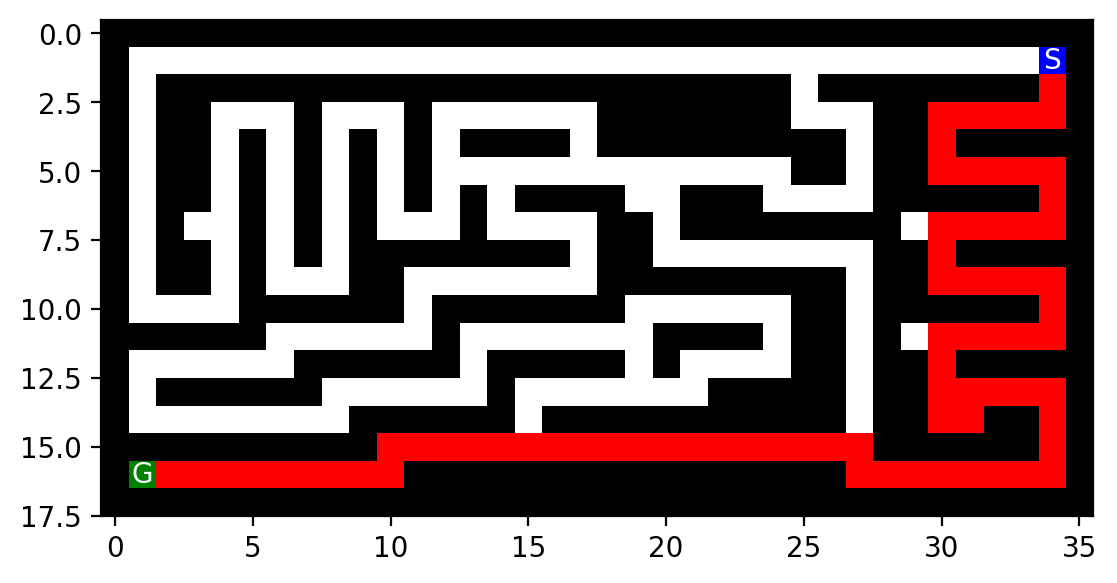

In [65]:
class Node:
    def __init__(self, pos, parent=None, action=None, cost=0):
        self.pos = tuple(pos)    # the state; positions are (row, col)
        self.parent = parent     # reference to parent node. None means root node.
        self.action = action     # action used in the transition function (root node has None)
        self.cost = cost         # for uniform cost this is the depth

    def __str__(self):
        return f"Node - pos = {self.pos}; action = {self.action}; cost = {self.cost}"

    def get_path_from_root(self):
        """Returns nodes on the path from the root to the current node."""
        node = self
        path = [node]
        while node.parent is not None:
            node = node.parent
            path.append(node)
        path.reverse()
        return path


ACTIONS = [(-1, 0, 'North'), (1, 0, 'South'), (0, -1, 'West'), (0, 1, 'East')]

def mark_maze(maze, pos, symbol):
    """Marks the maze at a given position with a symbol."""
    maze[pos[0]][pos[1]] = symbol


def depth_limited_search(maze, node, goal, limit, visited):
    """Performs a depth-limited search."""
    if node.pos == goal:  # Check if current node is the goal
        return node.get_path_from_root()
    
    if limit == 0:  # If the depth limit is reached, stop expanding
        return None

    visited.add(node.pos)  # Add the current node to visited nodes
    
    for dx, dy, action in ACTIONS:
        next_pos = (node.pos[0] + dx, node.pos[1] + dy)  # Calculate next position
        if mh.look(maze, next_pos) != 'X' and next_pos not in visited:  # Check for valid move
            child = Node(next_pos, node, action, node.cost + 1)  # Create child node
            result = depth_limited_search(maze, child, goal, limit - 1, visited)  # Recursive call with depth limit reduced
            if result is not None:  # If a solution is found, return it
                return result
    
    return None


def iterative_deepening_search(maze, start, goal):
    """Performs an Iterative Deepening Search (IDS)."""
    depth = 0  # Start with a depth limit of 0 and increase iteratively
    while True:
        visited = set()  # Reset visited nodes for each new depth limit
        initial_node = Node(pos=start)
        result = depth_limited_search(maze, initial_node, goal, depth, visited)
        if result is not None:  # If a solution is found, return the path
            return result
        depth += 1  # Increment the depth limit for the next iteration


# Test the IDS on a maze
with open("medium_maze.txt", "r") as f:
    maze_str = f.read()

maze = mh.parse_maze(maze_str)
start = mh.find_pos(maze, what="S")
goal = mh.find_pos(maze, what="G")

print('start point is', start, 'goal point is', goal)
solution_path = iterative_deepening_search(maze, start, goal)

# Mark the solution path in the maze
if solution_path:
    for path_node in solution_path:
        if mh.look(maze, path_node.pos) != 'G' and mh.look(maze, path_node.pos) != 'S':
            mark_maze(maze, path_node.pos, 'P')
        clear_output(wait=True)
        mh.show_maze(maze)


### large maze

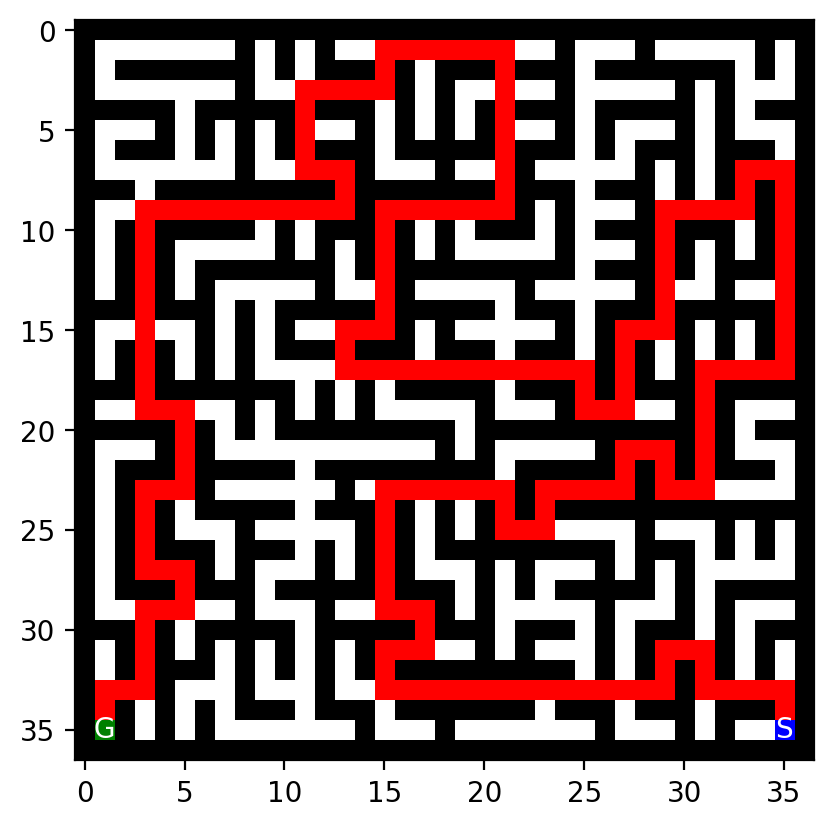

In [66]:
class Node:
    def __init__(self, pos, parent=None, action=None, cost=0):
        self.pos = tuple(pos)    # the state; positions are (row, col)
        self.parent = parent     # reference to parent node. None means root node.
        self.action = action     # action used in the transition function (root node has None)
        self.cost = cost         # for uniform cost this is the depth

    def __str__(self):
        return f"Node - pos = {self.pos}; action = {self.action}; cost = {self.cost}"

    def get_path_from_root(self):
        """Returns nodes on the path from the root to the current node."""
        node = self
        path = [node]
        while node.parent is not None:
            node = node.parent
            path.append(node)
        path.reverse()
        return path


ACTIONS = [(-1, 0, 'North'), (1, 0, 'South'), (0, -1, 'West'), (0, 1, 'East')]

def mark_maze(maze, pos, symbol):
    """Marks the maze at a given position with a symbol."""
    maze[pos[0]][pos[1]] = symbol


def depth_limited_search(maze, node, goal, limit, visited):
    """Performs a depth-limited search."""
    if node.pos == goal:  # Check if current node is the goal
        return node.get_path_from_root()
    
    if limit == 0:  # If the depth limit is reached, stop expanding
        return None

    visited.add(node.pos)  # Add the current node to visited nodes
    
    for dx, dy, action in ACTIONS:
        next_pos = (node.pos[0] + dx, node.pos[1] + dy)  # Calculate next position
        if mh.look(maze, next_pos) != 'X' and next_pos not in visited:  # Check for valid move
            child = Node(next_pos, node, action, node.cost + 1)  # Create child node
            result = depth_limited_search(maze, child, goal, limit - 1, visited)  # Recursive call with depth limit reduced
            if result is not None:  # If a solution is found, return it
                return result
    
    return None


def iterative_deepening_search(maze, start, goal):
    """Performs an Iterative Deepening Search (IDS)."""
    depth = 0  # Start with a depth limit of 0 and increase iteratively
    while True:
        visited = set()  # Reset visited nodes for each new depth limit
        initial_node = Node(pos=start)
        result = depth_limited_search(maze, initial_node, goal, depth, visited)
        if result is not None:  # If a solution is found, return the path
            return result
        depth += 1  # Increment the depth limit for the next iteration


# Test the IDS on a maze
with open("large_maze.txt", "r") as f:
    maze_str = f.read()

maze = mh.parse_maze(maze_str)
start = mh.find_pos(maze, what="S")
goal = mh.find_pos(maze, what="G")

print('start point is', start, 'goal point is', goal)
solution_path = iterative_deepening_search(maze, start, goal)

# Mark the solution path in the maze
if solution_path:
    for path_node in solution_path:
        if mh.look(maze, path_node.pos) != 'G' and mh.look(maze, path_node.pos) != 'S':
            mark_maze(maze, path_node.pos, 'P')
        clear_output(wait=True)
        mh.show_maze(maze)


### open Maze

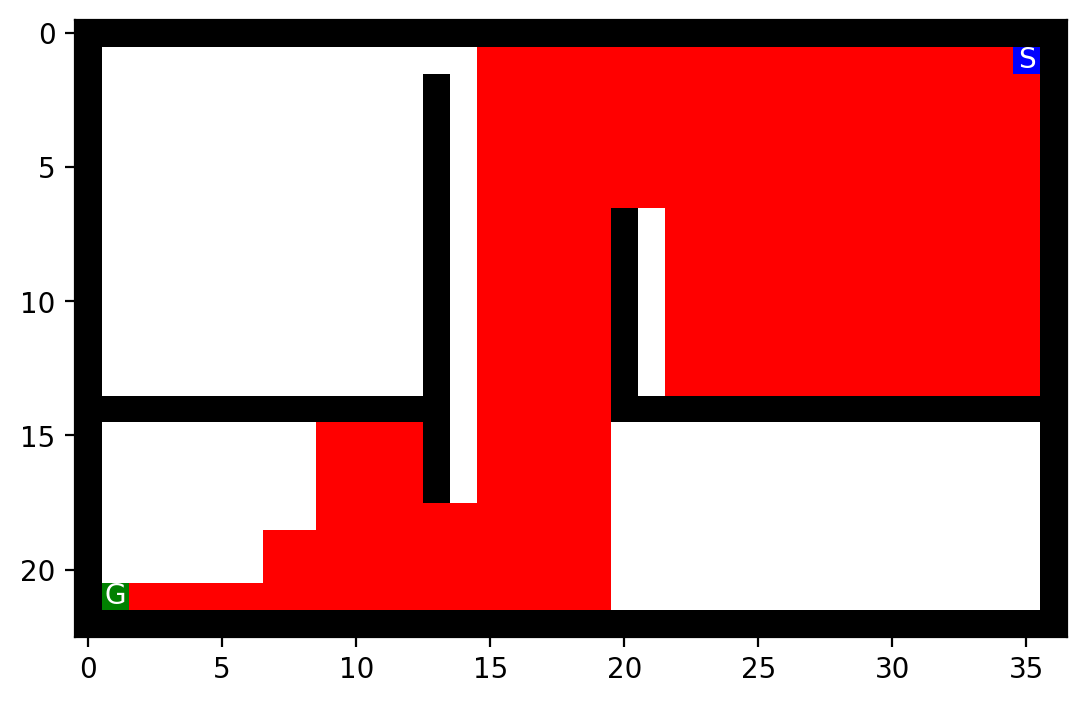

In [67]:
class Node:
    def __init__(self, pos, parent=None, action=None, cost=0):
        self.pos = tuple(pos)    # the state; positions are (row, col)
        self.parent = parent     # reference to parent node. None means root node.
        self.action = action     # action used in the transition function (root node has None)
        self.cost = cost         # for uniform cost this is the depth

    def __str__(self):
        return f"Node - pos = {self.pos}; action = {self.action}; cost = {self.cost}"

    def get_path_from_root(self):
        """Returns nodes on the path from the root to the current node."""
        node = self
        path = [node]
        while node.parent is not None:
            node = node.parent
            path.append(node)
        path.reverse()
        return path


ACTIONS = [(-1, 0, 'North'), (1, 0, 'South'), (0, -1, 'West'), (0, 1, 'East')]

def mark_maze(maze, pos, symbol):
    """Marks the maze at a given position with a symbol."""
    maze[pos[0]][pos[1]] = symbol


def depth_limited_search(maze, node, goal, limit, visited):
    """Performs a depth-limited search."""
    if node.pos == goal:  # Check if current node is the goal
        return node.get_path_from_root()
    
    if limit == 0:  # If the depth limit is reached, stop expanding
        return None

    visited.add(node.pos)  # Add the current node to visited nodes
    
    for dx, dy, action in ACTIONS:
        next_pos = (node.pos[0] + dx, node.pos[1] + dy)  # Calculate next position
        if mh.look(maze, next_pos) != 'X' and next_pos not in visited:  # Check for valid move
            child = Node(next_pos, node, action, node.cost + 1)  # Create child node
            result = depth_limited_search(maze, child, goal, limit - 1, visited)  # Recursive call with depth limit reduced
            if result is not None:  # If a solution is found, return it
                return result
    
    return None


def iterative_deepening_search(maze, start, goal):
    """Performs an Iterative Deepening Search (IDS)."""
    depth = 0  # Start with a depth limit of 0 and increase iteratively
    while True:
        visited = set()  # Reset visited nodes for each new depth limit
        initial_node = Node(pos=start)
        result = depth_limited_search(maze, initial_node, goal, depth, visited)
        if result is not None:  # If a solution is found, return the path
            return result
        depth += 1  # Increment the depth limit for the next iteration


# Test the IDS on a maze
with open("open_maze.txt", "r") as f:
    maze_str = f.read()

maze = mh.parse_maze(maze_str)
start = mh.find_pos(maze, what="S")
goal = mh.find_pos(maze, what="G")

print('start point is', start, 'goal point is', goal)
solution_path = iterative_deepening_search(maze, start, goal)

# Mark the solution path in the maze
if solution_path:
    for path_node in solution_path:
        if mh.look(maze, path_node.pos) != 'G' and mh.look(maze, path_node.pos) != 'S':
            mark_maze(maze, path_node.pos, 'P')
        clear_output(wait=True)
        mh.show_maze(maze)


### Wall maze

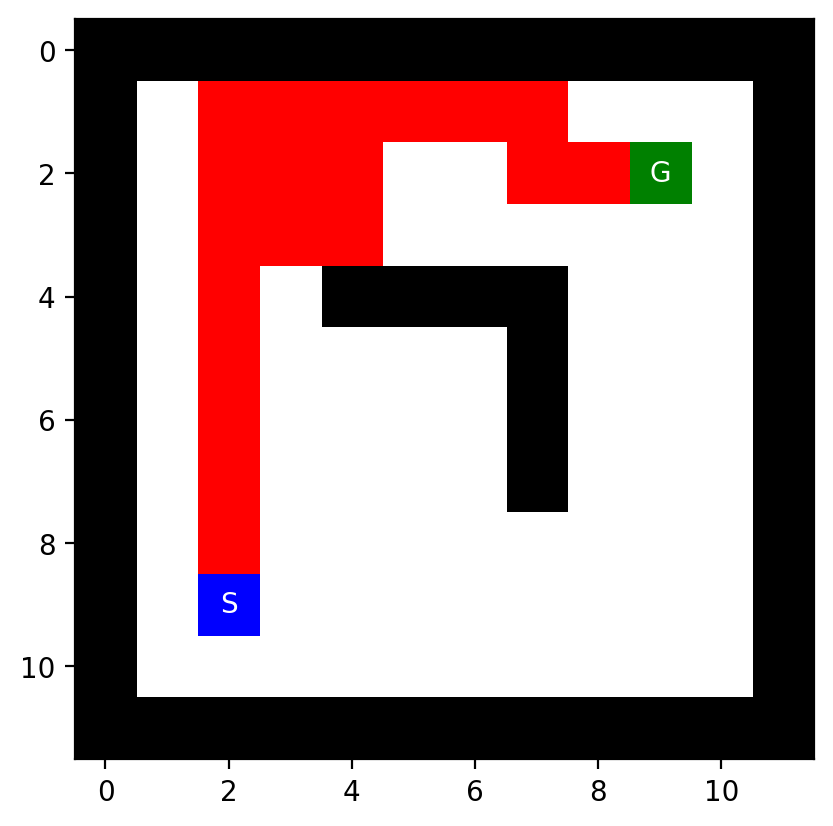

In [68]:
class Node:
    def __init__(self, pos, parent=None, action=None, cost=0):
        self.pos = tuple(pos)    # the state; positions are (row, col)
        self.parent = parent     # reference to parent node. None means root node.
        self.action = action     # action used in the transition function (root node has None)
        self.cost = cost         # for uniform cost this is the depth

    def __str__(self):
        return f"Node - pos = {self.pos}; action = {self.action}; cost = {self.cost}"

    def get_path_from_root(self):
        """Returns nodes on the path from the root to the current node."""
        node = self
        path = [node]
        while node.parent is not None:
            node = node.parent
            path.append(node)
        path.reverse()
        return path


ACTIONS = [(-1, 0, 'North'), (1, 0, 'South'), (0, -1, 'West'), (0, 1, 'East')]

def mark_maze(maze, pos, symbol):
    """Marks the maze at a given position with a symbol."""
    maze[pos[0]][pos[1]] = symbol


def depth_limited_search(maze, node, goal, limit, visited):
    """Performs a depth-limited search."""
    if node.pos == goal:  # Check if current node is the goal
        return node.get_path_from_root()
    
    if limit == 0:  # If the depth limit is reached, stop expanding
        return None

    visited.add(node.pos)  # Add the current node to visited nodes
    
    for dx, dy, action in ACTIONS:
        next_pos = (node.pos[0] + dx, node.pos[1] + dy)  # Calculate next position
        if mh.look(maze, next_pos) != 'X' and next_pos not in visited:  # Check for valid move
            child = Node(next_pos, node, action, node.cost + 1)  # Create child node
            result = depth_limited_search(maze, child, goal, limit - 1, visited)  # Recursive call with depth limit reduced
            if result is not None:  # If a solution is found, return it
                return result
    
    return None


def iterative_deepening_search(maze, start, goal):
    """Performs an Iterative Deepening Search (IDS)."""
    depth = 0  # Start with a depth limit of 0 and increase iteratively
    while True:
        visited = set()  # Reset visited nodes for each new depth limit
        initial_node = Node(pos=start)
        result = depth_limited_search(maze, initial_node, goal, depth, visited)
        if result is not None:  # If a solution is found, return the path
            return result
        depth += 1  # Increment the depth limit for the next iteration


# Test the IDS on a maze
with open("wall_maze.txt", "r") as f:
    maze_str = f.read()

maze = mh.parse_maze(maze_str)
start = mh.find_pos(maze, what="S")
goal = mh.find_pos(maze, what="G")

print('start point is', start, 'goal point is', goal)
solution_path = iterative_deepening_search(maze, start, goal)

# Mark the solution path in the maze
if solution_path:
    for path_node in solution_path:
        if mh.look(maze, path_node.pos) != 'G' and mh.look(maze, path_node.pos) != 'S':
            mark_maze(maze, path_node.pos, 'P')
        clear_output(wait=True)
        mh.show_maze(maze)


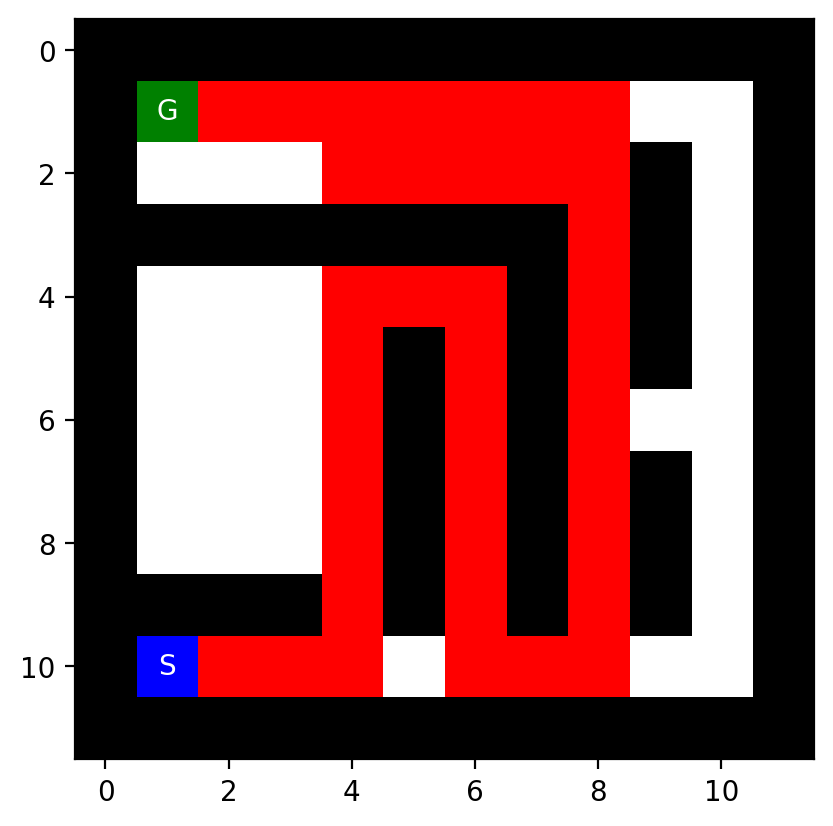

In [69]:
class Node:
    def __init__(self, pos, parent=None, action=None, cost=0):
        self.pos = tuple(pos)    # the state; positions are (row, col)
        self.parent = parent     # reference to parent node. None means root node.
        self.action = action     # action used in the transition function (root node has None)
        self.cost = cost         # for uniform cost this is the depth

    def __str__(self):
        return f"Node - pos = {self.pos}; action = {self.action}; cost = {self.cost}"

    def get_path_from_root(self):
        """Returns nodes on the path from the root to the current node."""
        node = self
        path = [node]
        while node.parent is not None:
            node = node.parent
            path.append(node)
        path.reverse()
        return path


ACTIONS = [(-1, 0, 'North'), (1, 0, 'South'), (0, -1, 'West'), (0, 1, 'East')]

def mark_maze(maze, pos, symbol):
    """Marks the maze at a given position with a symbol."""
    maze[pos[0]][pos[1]] = symbol


def depth_limited_search(maze, node, goal, limit, visited):
    """Performs a depth-limited search."""
    if node.pos == goal:  # Check if current node is the goal
        return node.get_path_from_root()
    
    if limit == 0:  # If the depth limit is reached, stop expanding
        return None

    visited.add(node.pos)  # Add the current node to visited nodes
    
    for dx, dy, action in ACTIONS:
        next_pos = (node.pos[0] + dx, node.pos[1] + dy)  # Calculate next position
        if mh.look(maze, next_pos) != 'X' and next_pos not in visited:  # Check for valid move
            child = Node(next_pos, node, action, node.cost + 1)  # Create child node
            result = depth_limited_search(maze, child, goal, limit - 1, visited)  # Recursive call with depth limit reduced
            if result is not None:  # If a solution is found, return it
                return result
    
    return None


def iterative_deepening_search(maze, start, goal):
    """Performs an Iterative Deepening Search (IDS)."""
    depth = 0  # Start with a depth limit of 0 and increase iteratively
    while True:
        visited = set()  # Reset visited nodes for each new depth limit
        initial_node = Node(pos=start)
        result = depth_limited_search(maze, initial_node, goal, depth, visited)
        if result is not None:  # If a solution is found, return the path
            return result
        depth += 1  # Increment the depth limit for the next iteration


# Test the IDS on a maze
with open("loops_maze.txt", "r") as f:
    maze_str = f.read()

maze = mh.parse_maze(maze_str)
start = mh.find_pos(maze, what="S")
goal = mh.find_pos(maze, what="G")

print('start point is', start, 'goal point is', goal)
solution_path = iterative_deepening_search(maze, start, goal)

# Mark the solution path in the maze
if solution_path:
    for path_node in solution_path:
        if mh.look(maze, path_node.pos) != 'G' and mh.look(maze, path_node.pos) != 'S':
            mark_maze(maze, path_node.pos, 'P')
        clear_output(wait=True)
        mh.show_maze(maze)


### empty maze

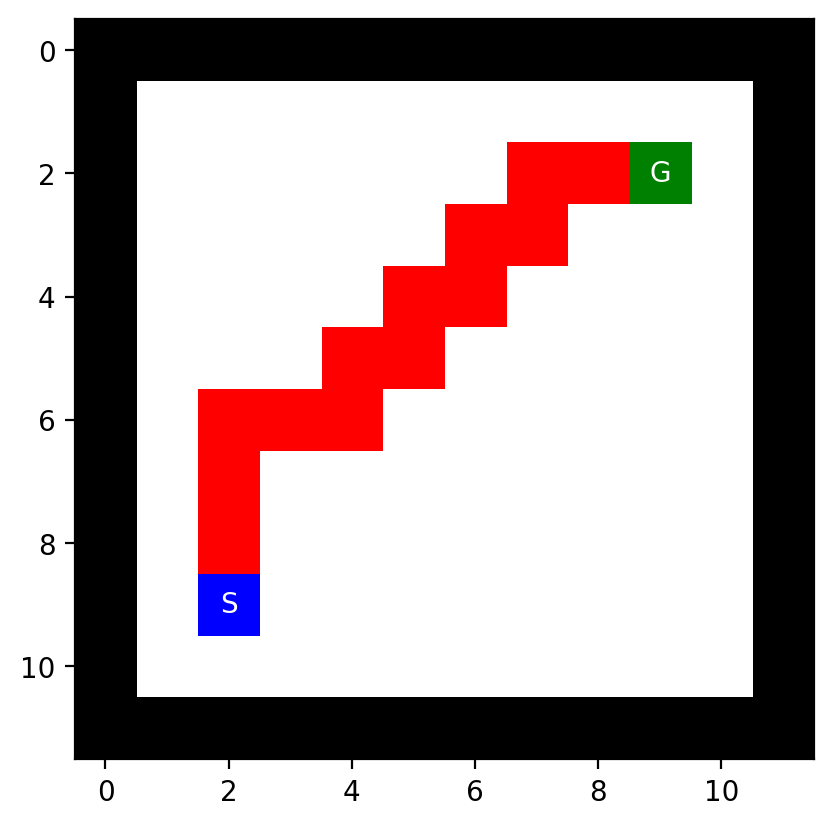

In [70]:
class Node:
    def __init__(self, pos, parent=None, action=None, cost=0):
        self.pos = tuple(pos)    # the state; positions are (row, col)
        self.parent = parent     # reference to parent node. None means root node.
        self.action = action     # action used in the transition function (root node has None)
        self.cost = cost         # for uniform cost this is the depth

    def __str__(self):
        return f"Node - pos = {self.pos}; action = {self.action}; cost = {self.cost}"

    def get_path_from_root(self):
        """Returns nodes on the path from the root to the current node."""
        node = self
        path = [node]
        while node.parent is not None:
            node = node.parent
            path.append(node)
        path.reverse()
        return path


ACTIONS = [(-1, 0, 'North'), (1, 0, 'South'), (0, -1, 'West'), (0, 1, 'East')]

def mark_maze(maze, pos, symbol):
    """Marks the maze at a given position with a symbol."""
    maze[pos[0]][pos[1]] = symbol


def depth_limited_search(maze, node, goal, limit, visited):
    """Performs a depth-limited search."""
    if node.pos == goal:  # Check if current node is the goal
        return node.get_path_from_root()
    
    if limit == 0:  # If the depth limit is reached, stop expanding
        return None

    visited.add(node.pos)  # Add the current node to visited nodes
    
    for dx, dy, action in ACTIONS:
        next_pos = (node.pos[0] + dx, node.pos[1] + dy)  # Calculate next position
        if mh.look(maze, next_pos) != 'X' and next_pos not in visited:  # Check for valid move
            child = Node(next_pos, node, action, node.cost + 1)  # Create child node
            result = depth_limited_search(maze, child, goal, limit - 1, visited)  # Recursive call with depth limit reduced
            if result is not None:  # If a solution is found, return it
                return result
    
    return None


def iterative_deepening_search(maze, start, goal):
    """Performs an Iterative Deepening Search (IDS)."""
    depth = 0  # Start with a depth limit of 0 and increase iteratively
    while True:
        visited = set()  # Reset visited nodes for each new depth limit
        initial_node = Node(pos=start)
        result = depth_limited_search(maze, initial_node, goal, depth, visited)
        if result is not None:  # If a solution is found, return the path
            return result
        depth += 1  # Increment the depth limit for the next iteration


# Test the IDS on a maze
with open("empty_maze.txt", "r") as f:
    maze_str = f.read()

maze = mh.parse_maze(maze_str)
start = mh.find_pos(maze, what="S")
goal = mh.find_pos(maze, what="G")

print('start point is', start, 'goal point is', goal)
solution_path = iterative_deepening_search(maze, start, goal)

# Mark the solution path in the maze
if solution_path:
    for path_node in solution_path:
        if mh.look(maze, path_node.pos) != 'G' and mh.look(maze, path_node.pos) != 'S':
            mark_maze(maze, path_node.pos, 'P')
        clear_output(wait=True)
        mh.show_maze(maze)


### empty_2_maze

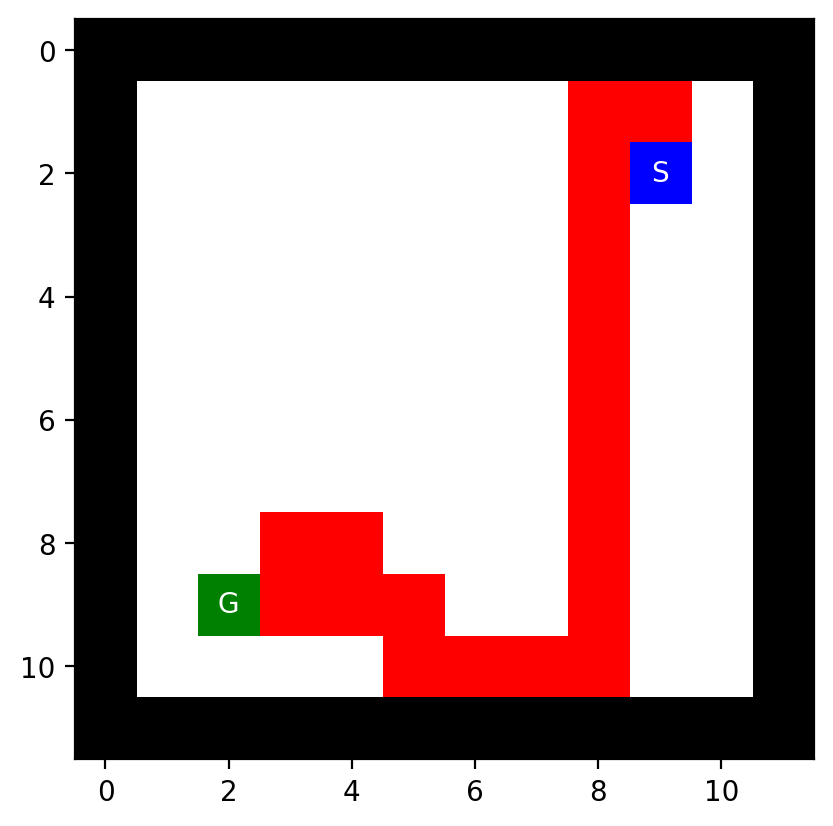

In [71]:
class Node:
    def __init__(self, pos, parent=None, action=None, cost=0):
        self.pos = tuple(pos)    # the state; positions are (row, col)
        self.parent = parent     # reference to parent node. None means root node.
        self.action = action     # action used in the transition function (root node has None)
        self.cost = cost         # for uniform cost this is the depth

    def __str__(self):
        return f"Node - pos = {self.pos}; action = {self.action}; cost = {self.cost}"

    def get_path_from_root(self):
        """Returns nodes on the path from the root to the current node."""
        node = self
        path = [node]
        while node.parent is not None:
            node = node.parent
            path.append(node)
        path.reverse()
        return path


ACTIONS = [(-1, 0, 'North'), (1, 0, 'South'), (0, -1, 'West'), (0, 1, 'East')]

def mark_maze(maze, pos, symbol):
    """Marks the maze at a given position with a symbol."""
    maze[pos[0]][pos[1]] = symbol


def depth_limited_search(maze, node, goal, limit, visited):
    """Performs a depth-limited search."""
    if node.pos == goal:  # Check if current node is the goal
        return node.get_path_from_root()
    
    if limit == 0:  # If the depth limit is reached, stop expanding
        return None

    visited.add(node.pos)  # Add the current node to visited nodes
    
    for dx, dy, action in ACTIONS:
        next_pos = (node.pos[0] + dx, node.pos[1] + dy)  # Calculate next position
        if mh.look(maze, next_pos) != 'X' and next_pos not in visited:  # Check for valid move
            child = Node(next_pos, node, action, node.cost + 1)  # Create child node
            result = depth_limited_search(maze, child, goal, limit - 1, visited)  # Recursive call with depth limit reduced
            if result is not None:  # If a solution is found, return it
                return result
    
    return None


def iterative_deepening_search(maze, start, goal):
    """Performs an Iterative Deepening Search (IDS)."""
    depth = 0  # Start with a depth limit of 0 and increase iteratively
    while True:
        visited = set()  # Reset visited nodes for each new depth limit
        initial_node = Node(pos=start)
        result = depth_limited_search(maze, initial_node, goal, depth, visited)
        if result is not None:  # If a solution is found, return the path
            return result
        depth += 1  # Increment the depth limit for the next iteration


# Test the IDS on a maze
with open("empty_2_maze.txt", "r") as f:
    maze_str = f.read()

maze = mh.parse_maze(maze_str)
start = mh.find_pos(maze, what="S")
goal = mh.find_pos(maze, what="G")

print('start point is', start, 'goal point is', goal)
solution_path = iterative_deepening_search(maze, start, goal)

# Mark the solution path in the maze
if solution_path:
    for path_node in solution_path:
        if mh.look(maze, path_node.pos) != 'G' and mh.look(maze, path_node.pos) != 'S':
            mark_maze(maze, path_node.pos, 'P')
        clear_output(wait=True)
        mh.show_maze(maze)


### Multiple Goals
Create a few mazes with multiple goals by adding one or two more goals to the medium size maze. The agent is done when it finds one of the goals.
Solve the maze with your implementations for DFS, BFS, and IDS. Run experiments to show which implementations find the optimal solution and which do not. Discuss why that is the case.

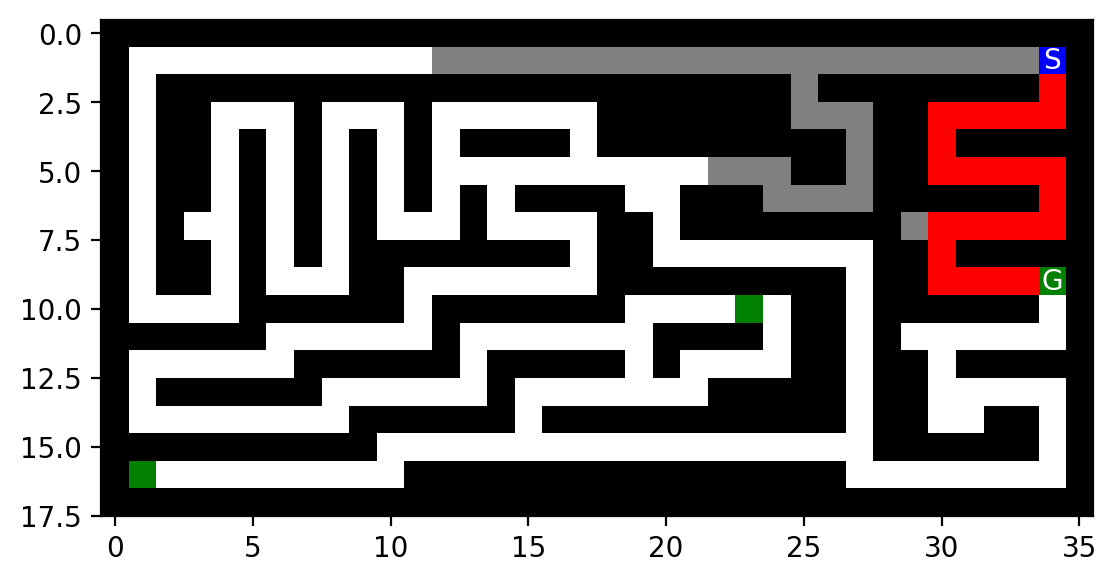

,Algorithm,Path Cost,Nodes Expanded,Max Tree Depth,Max Frontier Size,max memory usage
0,BFS,24,60,24,4,65


In [73]:

class Node:
    def __init__(self, pos, parent=None, action=None, cost=0):
        self.pos = tuple(pos)    # the state; positions are (row,col)
        self.parent = parent     # reference to parent node. None means root node.
        self.action = action     # action used in the transition function (root node has None)
        self.cost = cost         # for uniform cost this is the depth. It is also g(n) for A* search

    def __str__(self):
        return f"Node - pos = {self.pos}; action = {self.action}; cost = {self.cost}"

    def get_path_from_root(self):
        """returns nodes on the path from the root to the current node."""
        node = self
        path = [node]

        while not node.parent is None:
            node = node.parent
            path.append(node)
            

        path.reverse()

        return(path)
ACTIONS = [(-1, 0, 'North'), (1, 0, 'South'), (0, -1, 'West'), (0, 1, 'East')]    
def mark_maze(maze, pos, symbol):
    """Marks the maze at a given position with a symbol."""
    maze[pos[0]][pos[1]] = symbol
    
def BFS(maze, start, goal):
    # Initialize the initial node and check if it's the goal
    initial_node = Node(pos=start)
    if start == goal:  # Check if the initial state is the goal
        return initial_node.get_path_from_root(), 0, 0, 0, 0
    
    # Initialize the frontier (FIFO queue) and reached set
    frontier = [initial_node]  # Frontier initialized with the initial node
    reached = set()  # Reached set to track visited nodes
    reached.add(start)
    
    # Metrics tracking
    nodes_expanded = 0  # Total nodes expanded
    max_tree_depth = 0  # Maximum depth of the tree
    max_frontier_size = 1  # Maximum size of the frontier (starts with 1, the initial node)
    max_memory_usage = 1  # Maximum number of nodes in memory (frontier + reached)
    # Loop until we either find the goal or exhaust the frontier
    while frontier:
        node = frontier.pop(0)  # Expand the node (FIFO behavior)
        nodes_expanded += 1  # Increment the expanded nodes counter

        # Mark the node as visited (for visualization purposes)
        if mh.look(maze, node.pos) != 'S':
            mark_maze(maze, node.pos, '.')
        
        # Loop through possible actions (North, South, West, East)
        for dx, dy, action in ACTIONS:
            next_pos = (node.pos[0] + dx, node.pos[1] + dy)  # Next position 
            
            # Check if next position is valid (not a wall or already reached)
            if mh.look(maze, next_pos) != 'X' and next_pos not in reached:
                reached.add(next_pos)  # Add the next position to the reached set

                # Create child node
                child = Node(next_pos, node, action, node.cost + 1)  # Child node with updated cost (depth)

                # Add child to the frontier
                frontier.append(child)

                # Track maximum tree depth
                max_tree_depth = max(max_tree_depth, child.cost)
                
                # Track maximum frontier size
                max_frontier_size = max(max_frontier_size, len(frontier))
                
                # If the goal is reached, return the solution path and metrics
                if mh.look(maze, next_pos) == 'G':
                    solution_path = child.get_path_from_root()
                    path_cost = len(solution_path) - 1
                    for path_node in solution_path:
                        if mh.look(maze, path_node.pos) != 'G' and mh.look(maze, path_node.pos) != 'S':
                            mark_maze(maze, path_node.pos, 'P')
                            clear_output(wait=True)
                            mh.show_maze(maze)
                    
                    return (solution_path, path_cost, nodes_expanded, max_tree_depth, max_frontier_size,max_memory_usage)

        max_memory_usage = max(max_memory_usage, len(frontier) + len(reached))
        clear_output(wait=True)
        mh.show_maze(maze)
    
    # If no solution is found, return None with 0s for all metrics
    return None, 0, nodes_expanded, max_tree_depth, max_frontier_size

with open("medium_maze_2.txt", "r") as f:
    maze_str = f.read()
maze = mh.parse_maze(maze_str)
start= mh.find_pos(maze, what = "S")
goal= mh.find_pos(maze, what = "G")
print('start point is',start,'goal point is',goal)
[solution_path,BFS_medium_path_cost,BFS_medium_nodes_expanded,BFS_medium_max_tree_depth, BFS_medium_max_frontier_size,BFS_medium_memory_usage] = BFS(maze, start, goal)
data = {
    'Algorithm': ['BFS'],
    'Path Cost': [BFS_medium_path_cost],
    'Nodes Expanded': [BFS_medium_nodes_expanded],
    'Max Tree Depth': [BFS_medium_max_tree_depth],
    'Max Frontier Size': [BFS_medium_max_frontier_size],
    'max memory usage':[BFS_medium_memory_usage]
}

# Create a DataFrame
df = pd.DataFrame(data)
df

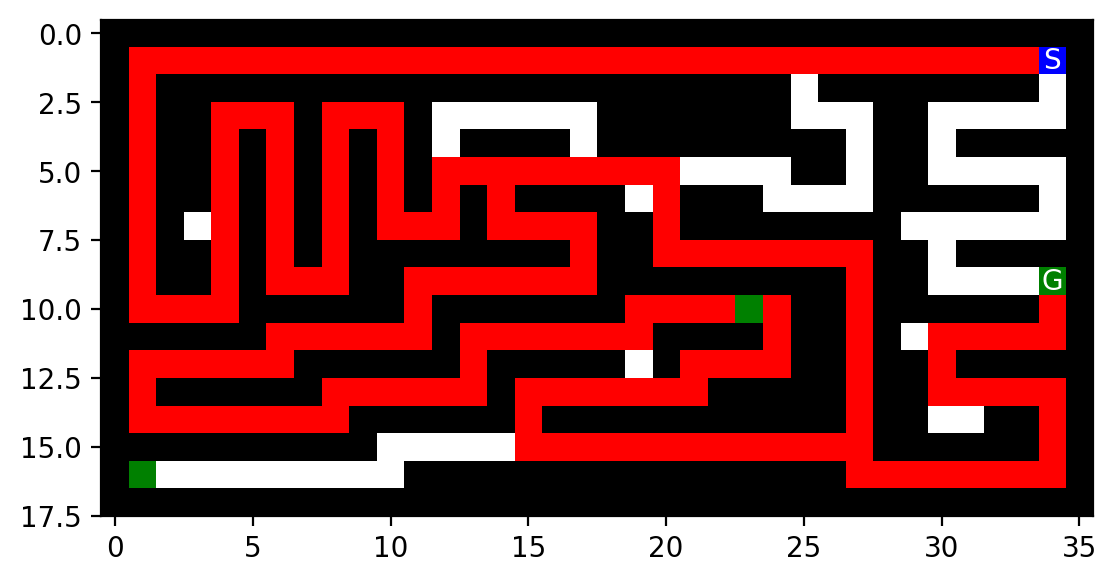

,Algorithm,Path Cost,Nodes Expanded,Max Tree Depth,Max Frontier Size,max memory usage
0,DFS,232,410,284,17,264


In [74]:
def DFS(maze, start, goal):
    #  Initialize the initial node and check if it's the goal
    initial_node = Node(pos=start)
    if start == goal:  # Check if the initial state is the goal
        return initial_node.get_path_from_root()

    #  Initialize the frontier (FIFO queue) and reached set
    frontier = [initial_node]  # Frontier initialized with the initial node
    reached = set()  # Reached set to track visited nodes
    visited = []  # List to track visited nodes in order
    branch = []   # List to track branching points
    nodes_expanded = 0
    max_tree_depth = 0
    max_frontier_size = 1  # Maximum size of the frontier (starts with 1, the initial node)
    max_memory_usage = 1  # Maximum number of nodes in memory (frontier + reached)
    while frontier:
        node = frontier.pop(-1)  # DFS uses LIFO, so we pop from the end (stack behavior)
        nodes_expanded += 1
        node1 = [(node.pos[0] - 1, node.pos[1]), (node.pos[0] + 1, node.pos[1]), 
                 (node.pos[0], node.pos[1] - 1), (node.pos[0], node.pos[1] + 1)]

        # Remove start and goal positions from neighbor list if present
        if mh.find_pos(maze, what="S") in node1:
            node1.pop(node1.index(mh.find_pos(maze, what="S")))
        if mh.find_pos(maze, what="G") in node1:
            node1.pop(node1.index(mh.find_pos(maze, what="G")))

        # Pruning branches if necessary
        while len(visited) > 2 and (visited[-1] not in node1):
            branch.pop(-1)
            last_branch_item = branch[-1]
            if last_branch_item in visited:
                index = visited.index(last_branch_item)
                visited1 = visited[:index + 1]
            for v in visited:
                if v not in visited1 and mh.look(maze, v) != 'G' and mh.look(maze, v) != 'S':
                    mark_maze(maze, v, ' ')
            visited = visited1

        visited.append(node.pos)

        # Mark the current position in the maze if it's not the start or goal
        if mh.look(maze, node.pos) != 'G' and mh.look(maze, node.pos) != 'S':
            mark_maze(maze, node.pos, '.')

        reached.add(node.pos)
        br = 0

        # **Addition**: Check if any neighbor of the current node is the goal
        for dx, dy, action in ACTIONS:
            next_pos = (node.pos[0] + dx, node.pos[1] + dy)  # Calculate next position
            if next_pos == goal:  # Early exit if the next position is the goal
                child = Node(next_pos, node, action, node.cost + 1)
                solution_path = child.get_path_from_root()
                path_cost = len(solution_path) - 1
                # Mark the solution path in the maze
                for path_node in solution_path:
                    if mh.look(maze, path_node.pos) != 'G' and mh.look(maze, path_node.pos) != 'S':
                        mark_maze(maze, path_node.pos, 'P')
                    clear_output(wait=True)
                    mh.show_maze(maze)
                return solution_path, path_cost, nodes_expanded, max_tree_depth, max_frontier_size,max_memory_usage

        # **Continuation of your code**: Expand the search by adding child nodes
        for dx, dy, action in ACTIONS:
            next_pos = (node.pos[0] + dx, node.pos[1] + dy)  # Next position

            if mh.look(maze, next_pos) != 'X' and next_pos not in visited:  # Valid position
                br += 1
                child = Node(next_pos, node, action, node.cost + 1)
                frontier.append(child)  # Add child to frontier
                max_tree_depth = max(max_tree_depth, child.cost)
                max_frontier_size = max(max_frontier_size, len(frontier))
                if br >= 2:
                    branch.append(node.pos)

                if mh.look(maze, node.pos) == 'G' and len(reached) >= 15:
                    last_branch_item = branch[-1]
                    if last_branch_item in visited:
                        index = visited.index(last_branch_item)
                        visited1 = visited[:index + 1]
                    for v in visited:
                        if v not in visited1 and mh.look(maze, v) != 'G' and mh.look(maze, v) != 'S':
                            mark_maze(maze, v, ' ')
                    visited = visited1
                    continue            

        if br == 0 and node.pos in visited:
            last_branch_item = branch[-1]
            if last_branch_item in visited:
                index = visited.index(last_branch_item)
                visited1 = visited[:index + 1]
            for v in visited:
                if v not in visited1 and mh.look(maze, v) != 'G' and mh.look(maze, v) != 'S':
                    mark_maze(maze, v, ' ')
            visited = visited1
            continue

        max_memory_usage = max(max_memory_usage, len(frontier) + len(reached))
        clear_output(wait=True)
        mh.show_maze(maze)
with open("medium_maze_2.txt", "r") as f:
    maze_str = f.read()
maze = mh.parse_maze(maze_str)
start= mh.find_pos(maze, what = "S")
goal= mh.find_pos(maze, what = "G")
print('start point is',start,'goal point is',goal)
[solution_path,DFS_small_path_cost,DFS_small_nodes_expanded,DFS_small_max_tree_depth, DFS_small_max_frontier_size,DFS_small_memory_usage] = DFS(maze, start, goal)
data = {
    'Algorithm': ['DFS'],
    'Path Cost': [DFS_small_path_cost],
    'Nodes Expanded': [DFS_small_nodes_expanded],
    'Max Tree Depth': [DFS_small_max_tree_depth],
    'Max Frontier Size': [DFS_small_max_frontier_size],
    'max memory usage':[DFS_small_memory_usage]
}

# Create a DataFrame
df = pd.DataFrame(data)
df

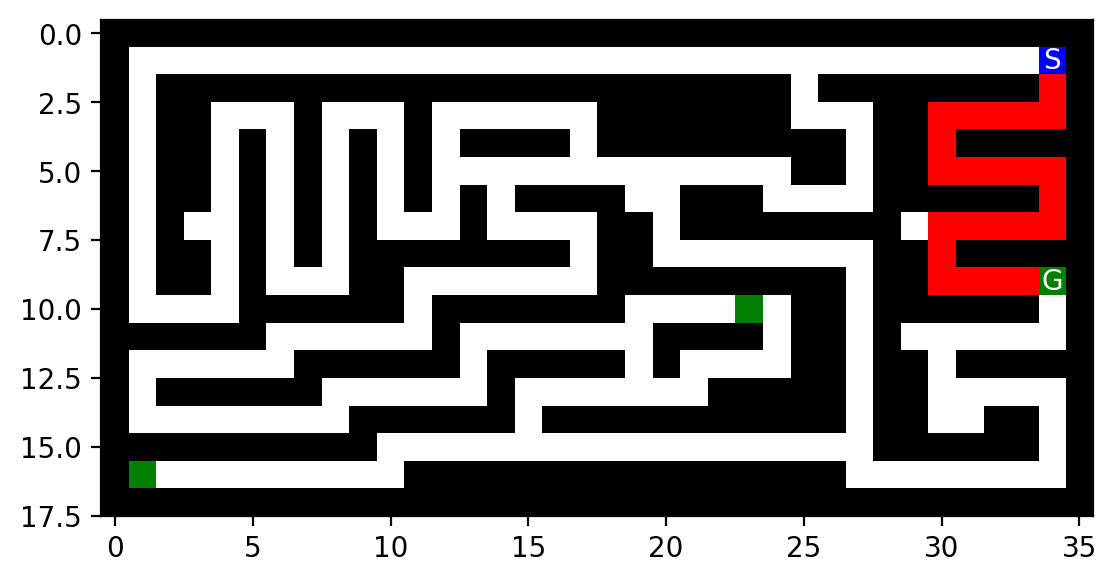

In [72]:
class Node:
    def __init__(self, pos, parent=None, action=None, cost=0):
        self.pos = tuple(pos)    # the state; positions are (row, col)
        self.parent = parent     # reference to parent node. None means root node.
        self.action = action     # action used in the transition function (root node has None)
        self.cost = cost         # for uniform cost this is the depth

    def __str__(self):
        return f"Node - pos = {self.pos}; action = {self.action}; cost = {self.cost}"

    def get_path_from_root(self):
        """Returns nodes on the path from the root to the current node."""
        node = self
        path = [node]
        while node.parent is not None:
            node = node.parent
            path.append(node)
        path.reverse()
        return path


ACTIONS = [(-1, 0, 'North'), (1, 0, 'South'), (0, -1, 'West'), (0, 1, 'East')]

def mark_maze(maze, pos, symbol):
    """Marks the maze at a given position with a symbol."""
    maze[pos[0]][pos[1]] = symbol


def depth_limited_search(maze, node, goal, limit, visited):
    """Performs a depth-limited search."""
    if node.pos == goal:  # Check if current node is the goal
        return node.get_path_from_root()
    
    if limit == 0:  # If the depth limit is reached, stop expanding
        return None

    visited.add(node.pos)  # Add the current node to visited nodes
    
    for dx, dy, action in ACTIONS:
        next_pos = (node.pos[0] + dx, node.pos[1] + dy)  # Calculate next position
        if mh.look(maze, next_pos) != 'X' and next_pos not in visited:  # Check for valid move
            child = Node(next_pos, node, action, node.cost + 1)  # Create child node
            result = depth_limited_search(maze, child, goal, limit - 1, visited)  # Recursive call with depth limit reduced
            if result is not None:  # If a solution is found, return it
                return result
    
    return None


def iterative_deepening_search(maze, start, goal):
    """Performs an Iterative Deepening Search (IDS)."""
    depth = 0  # Start with a depth limit of 0 and increase iteratively
    while True:
        visited = set()  # Reset visited nodes for each new depth limit
        initial_node = Node(pos=start)
        result = depth_limited_search(maze, initial_node, goal, depth, visited)
        if result is not None:  # If a solution is found, return the path
            return result
        depth += 1  # Increment the depth limit for the next iteration


# Test the IDS on a maze
with open("medium_maze_2.txt", "r") as f:
    maze_str = f.read()

maze = mh.parse_maze(maze_str)
start = mh.find_pos(maze, what="S")
goal = mh.find_pos(maze, what="G")

print('start point is', start, 'goal point is', goal)
solution_path = iterative_deepening_search(maze, start, goal)

# Mark the solution path in the maze
if solution_path:
    for path_node in solution_path:
        if mh.look(maze, path_node.pos) != 'G' and mh.look(maze, path_node.pos) != 'S':
            mark_maze(maze, path_node.pos, 'P')
        clear_output(wait=True)
        mh.show_maze(maze)


When there are multiple goals, determining which one leads to the most optimal solution (in terms of path cost, nodes expanded, etc.) becomes more complex. For example, an algorithm might reach the first goal but miss a closer or cheaper-to-reach goal elsewhere in the maze. BFS and IDF will still find the shortest path to the nearest goal. DFS could find one of the goals quickly but might not necessarily be the closest or most optimal path. If we have two goals in equal distance from start both BFS and IDF will find both og the goals at the same distance but will return the first one it encounters as a solution.

## More advanced tasks to think about

### Intersection as states
Instead of defining each square as a state, use only intersections as states. Now the storage requirement is reduced, but the path length between two intersections can be different. If we use total path length measured as the number of squares as path cost, how can we make sure that BFS and iterative deepening search is optimal? Change the code to do so.

In [ ]:
# Your code/answer goes here

### Weighted A* search
Modify your A* search to add weights (see text book) and explore how different weights influence the result.

In [ ]:
# Your code/answer goes here

### Unknown Maze
What happens if the agent does not know the layout of the maze in advance? This means that the agent faces an unknown environment, where it does not know the transition function. How does the environment look then (PEAS description)? How would you implement a rational agent to solve the maze? What if the agent still has a GPS device to tell the distance to the goal?

In [ ]:
# Your code/answer goes here